# **DAV 6150 Project 3 (Module 12) Gradient Descent + Gradient Boosting**



**Author:** Nicolette Mtisi

The purpose of this project is to compare the performance of **Gradient Descent-based algorithms** against standard tree-based models. Using a dataset on high school graduation outcomes in New York State, we aim to predict the level of dropout rates for various student subgroups.

The notebook begins with **exploratory data analysis (EDA)** to understand the dataset's characteristics. This is followed by **data preparation**, where we will engineer the categorical target variable, `dropout_pct_level`, which classifies dropout rates as "low," "medium," or "high" based on the median statistic.

Subsequently, we will apply **feature selection** techniques to identify the most predictive attributes. We will then construct, train, and evaluate five distinct classification models: **Decision Tree**, **Random Forest**, **Gradient Boosting**, **Stochastic Gradient Descent**, and **XG Boost**. Model performance will be compared using cross-validation and key classification metrics to select the most effective and robust model for predicting student dropout levels.

# **1. Introduction**

The purpose of this assignment is to construct and evaluate a series of machine learning models to predict the dropout rate classification for different student subgroups across New York State school districts. While previous modules focused on individual model types, this project specifically aims to gauge the effectiveness of **Gradient Descent-based algorithms** relative to one another and to standard tree-based models. The central goal is to determine which algorithmic approach—standard trees, ensemble forests, or gradient boosting techniques—provides the best predictive performance for this specific dataset.

The dataset for this project is the same data utilized in the Module 11 assignment: a collection of New York State high school graduation data containing more than 73,000 observations. Each record details graduation and enrollment statistics for a specific student subgroup within a particular school district for the 2018-2019 school year. Our primary task is to engineer a new categorical response variable, **`dropout_pct_level`**, derived from the continuous `dropout_pct` attribute, which will serve as the target for our classification models.

The workflow for this project follows a structured data science methodology:

*   **Data Loading and Inspection**
    *   Load the `M11_Data.csv` file from the GitHub repository into a Pandas DataFrame.
    *   Inspect the dataset's structure, data types, and initial content to ensure proper labeling.

*   **Exploratory Data Analysis (EDA)**
    *   Perform a thorough EDA to understand the distributions, relationships, and characteristics of the variables.
    *   Use statistical summaries and visualizations (bar plots, box plots, histograms, etc.) to identify patterns, outliers, and preliminary predictive inferences.

*   **Data Preparation and Feature Engineering**
    *   Create the categorical target variable, **`dropout_pct_level`**, with three levels ("low", "medium", "high") based on specific logic involving the median of the `dropout_pct` attribute.
    *   Remove the original `dropout_pct` and `dropout_cnt` columns to prevent data leakage and collinearity.
    *   Address any data integrity issues or missing values identified during the EDA.

*   **Prepped Data Review**
    *   Conduct a focused analysis of the prepared dataset, particularly examining the distribution of the newly created `dropout_pct_level` target variable.

*   **Feature Selection and Dimensionality Reduction**
    *   Apply feature selection or dimensionality reduction techniques to identify the most useful explanatory variables.
    *   Balance the tradeoff between model performance and model simplification.
    *   Split the data into training and testing subsets to prepare for model building.

*   **Classifier Modeling**
    *   Construct five distinct classification models using the training subset:
        1.  **Decision Tree**
        2.  **Random Forest**
        3.  **Gradient Boosting Classifier**
        4.  **Stochastic Gradient Descent (SGD) Classifier**
        5.  **XG Boost Classifier**
    *   Ensure that all five models utilize the same set of at least four (4) explanatory variables to allow for a fair, direct comparison.

*   **Model Selection and Final Evaluation**
    *   Define criteria and use classification metrics (e.g., accuracy, precision, recall) via cross-validation to compare the performance of the trained models.
    *   Select the single "best" model based on performance, interpretability, and complexity.
    *   Apply the selected preferred model to the unseen testing subset to assess its generalization performance.

*   **Conclusions**
    *   Summarize the project findings, compare the performance of the gradient descent-based models against the tree-based models, and discuss the implications of the final results.


# **2. Data Loading**

To begin our analysis, we first need to load the project's dataset into our environment. For this task, we will use the `pandas` library, a cornerstone of data science in Python, which provides powerful and easy-to-use data structures and analysis tools.

We will read the `M11_Data.csv` file directly from its hosted URL on GitHub. This approach ensures our notebook is self-contained and fully reproducible by anyone, as it doesn't require a separate data download step. Once the data is loaded into a DataFrame we've named `df`, we will immediately perform two essential checks.

First, we will print the DataFrame's `shape` to understand its scale—specifically, the number of rows (observations) and columns (attributes) we are working with. Second, we will use the `.head()` method to display the first few rows.

This quick preview allows us to verify that the data has loaded correctly, inspect the column names, and get a feel for the data's format and content. This step serves as the foundation for the more detailed Exploratory Data Analysis to follow.

In [ ]:
import pandas as pd

# Load the data (Module 11 Data)
url = "https://raw.githubusercontent.com/nic-stack/DAV6150-/refs/heads/main/M11_Data.csv"
df = pd.read_csv(url)

# Display basic information
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (73152, 19)


,report_school_year,aggregation_index,aggregation_type,aggregation_name,nrc_code,nrc_desc,county_code,county_name,nyc_ind,membership_desc,subgroup_code,subgroup_name,enroll_cnt,grad_cnt,grad_pct,reg_cnt,reg_pct,dropout_cnt,dropout_pct
0,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,1,All Students,658,464,71%,310,47%,148,22%
1,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,2,Female,324,246,76%,169,52%,65,20%
2,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,3,Male,334,218,65%,141,42%,83,25%
3,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,4,American Indian/Alaska Native,-,-,-,-,-,-,-
4,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,5,Black,367,248,68%,183,50%,91,25%



**Key Outputs:**

*   **Shape `(73152, 19)`:** This output from `df.shape` is critical. It informs us that our dataset contains **73,152 rows** (each representing a specific student subgroup within a school district) and **19 columns** (features or variables).

*   **Data Head:** The `df.head()` command has rendered a table showing the first five entries. This preview is invaluable for a preliminary assessment. We can observe:
    *   A mix of **numerical** and **categorical** data. For instance, `enroll_cnt` and `grad_cnt` are numerical counts, while `aggregation_name` and `subgroup_name` are categorical text descriptions.
    *   The column names align perfectly with the data dictionary provided in the assignment.
    *   **Critical Data Quality Issues:** We can immediately spot that percentage-based columns like `grad_pct` and `reg_pct` are formatted as strings (e.g., `"71%"`). Furthermore, the presence of `"-"` in some rows suggests non-standard missing values that will require cleaning.

With the data now loaded into memory, our next step is to perform a more thorough data cleaning and preprocessing. We will systematically check for missing values, correct the data types, and ensure the data is ready for detailed analysis.


### **2.1. Data Cleaning and Type Conversion**

Following our initial inspection, the next critical step is to clean the data and correct the data types of several key columns. The EDA revealed that columns intended for numerical analysis, such as student counts and graduation percentages, are currently stored as `object` (string) types due to the presence of non-numeric characters (`-` and `%`). To make these columns usable for statistical analysis and modeling, we must convert them to a proper numeric format.

In the following code, we will perform a targeted cleaning operation on seven specific columns.
*   **For the count columns** (`enroll_cnt`, `grad_cnt`, `reg_cnt`, `dropout_cnt`), our process will be to first replace the dash `'-'` placeholder with `None`, which pandas will recognize as a `NaN` (Not a Number) value. We will then convert these columns to a `float` data type.
*   **For the percentage columns** (`grad_pct`, `reg_pct`, `dropout_pct`), we will execute a similar replacement for the `'-'` character, but we will also use string manipulation to remove the `'%'` symbol from the end of each value. Once the strings contain only numbers, we will convert them to `float`.

After these transformations, we will call `df.info()` to verify that the `Dtype` of these columns has been successfully updated. Finally, we will generate descriptive statistics for all numerical columns using `df.describe()` to get our first summary of their distributions, including mean, standard deviation, and quartile values. This step is essential for moving from raw data to analyzable information.

In [ ]:
# columns that need to be cleaned
numeric_cols = [
    'enroll_cnt', 'grad_cnt', 'reg_cnt', 'dropout_cnt',
    'grad_pct', 'reg_pct', 'dropout_pct'
]

# replace '-' with None and convert counts to float
count_cols = ['enroll_cnt', 'grad_cnt', 'reg_cnt', 'dropout_cnt']
for col in count_cols:
    df[col] = df[col].replace('-', None).astype(float)

# replace '-' and remove '%' for percentage columns, then convert to float
pct_cols = ['grad_pct', 'reg_pct', 'dropout_pct']
for col in pct_cols:
    df[col] = df[col].replace('-', None).str.rstrip('%').astype(float)

# check updated data types
df.info()

# Descriptive statistics (numeric summary)
print("\n Basic Descriptive Statistics:")
display(df.describe().T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73152 entries, 0 to 73151
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   report_school_year  73152 non-null  object 
 1   aggregation_index   73152 non-null  int64  
 2   aggregation_type    73152 non-null  object 
 3   aggregation_name    73152 non-null  object 
 4   nrc_code            73152 non-null  int64  
 5   nrc_desc            73152 non-null  object 
 6   county_code         73152 non-null  int64  
 7   county_name         73152 non-null  object 
 8   nyc_ind             73152 non-null  int64  
 9   membership_desc     73152 non-null  object 
 10  subgroup_code       73152 non-null  int64  
 11  subgroup_name       73152 non-null  object 
 12  enroll_cnt          39674 non-null  float64
 13  grad_cnt            39674 non-null  float64
 14  grad_pct            39674 non-null  float64
 15  reg_cnt             39674 non-null  float64
 16  reg_

,count,mean,std,min,25%,50%,75%,max
aggregation_index,73152.0,3.000000,0.000000,3.0,3.0,3.0,3.0,3.0
nrc_code,73152.0,4.588583,1.203507,1.0,4.0,5.0,5.0,6.0
county_code,73152.0,36.251859,20.588044,1.0,17.0,40.0,57.0,68.0
nyc_ind,73152.0,0.055255,0.228479,0.0,0.0,0.0,0.0,1.0
subgroup_code,73152.0,12.000930,7.213138,1.0,6.0,11.0,18.0,25.0
enroll_cnt,39674.0,192.120079,439.972474,5.0,25.0,66.0,179.0,9176.0
grad_cnt,39674.0,161.178354,361.294773,0.0,20.0,57.0,156.0,7540.0
grad_pct,39674.0,84.406614,15.679500,0.0,79.0,89.0,95.0,100.0
reg_cnt,39674.0,86.804708,225.795826,0.0,10.0,27.0,69.0,4752.0
reg_pct,39674.0,43.371125,17.124891,0.0,33.0,43.0,53.0,100.0


**Key Outputs & Interpretation:**

*   **Successful Type Conversion:** The `.info()` summary confirms that our primary objective was met. The seven target columns (`enroll_cnt`, `grad_cnt`, `grad_pct`, `reg_cnt`, `reg_pct`, `dropout_cnt`, and `dropout_pct`) have all been successfully converted from `object` to `float64`. This makes them suitable for numerical calculations and modeling.

*   **Identification of Widespread Missing Data:** A crucial finding revealed by the "Non-Null Count" column in `.info()` is the significant amount of missing data. Each of the seven cleaned columns now has only **39,674 non-null values** out of a total of 73,152 rows. This means that nearly **46%** of the rows for these key metrics are null. This is likely due to data suppression for small subgroup sizes to protect student privacy. This high proportion of missing data is a major characteristic of the dataset that will require careful handling in our data preparation phase.

*   **Numerical Summary Insights:** The descriptive statistics from `.describe()` offer our first quantitative look at the data's distribution:
    *   **Constant Column:** The `aggregation_index` column has a standard deviation of 0, with its min, max, and mean all being 3.0. This indicates it is a constant value across all records and holds no predictive information. We can safely drop this column later.
    *   **Key Metric for Target Variable:** The `reg_pct` column is the foundation for our response variable. The summary shows its **median (50th percentile) is 43.0%**. According to the assignment instructions, this value will be the central reference point for creating our "low," "medium," and "high" categories.
    *   **Skewed Distributions:** For columns like `enroll_cnt`, the mean (192.1) is significantly higher than the median (66.0). This indicates a strong right-skew in the data, meaning that while most subgroups are relatively small, a few are exceptionally large, which is typical for population data.

This cleaning step was successful in making the data numerically usable. However, it has also highlighted the significant challenge of missing data that must be addressed before we can proceed with modeling.

### **2.2. Variable Classification**

To structure our analysis and modeling efforts effectively, it is essential to formally classify each variable as either categorical or numerical. While data types (`dtype`) provide a good starting point, they can sometimes be misleading. For instance, a column containing numerical IDs (like `county_code`) is technically an integer but functionally represents distinct categories. The following code implements a systematic process to ensure every variable is correctly classified.

First, we will perform an automatic separation, using `select_dtypes` to create initial lists of categorical (`cat_cols`) and numerical (`num_cols`) columns.

 Next, we will manually intervene based on our understanding of the data dictionary. We will reclassify specific numerically-coded columns (`aggregation_index`, `nrc_code`, `county_code`, `subgroup_code`, and `nyc_ind`) by moving them from the numerical list to the categorical list. This manual adjustment is crucial for ensuring that these variables are treated appropriately in later stages, such as feature engineering and modeling.

Finally, we will print the resulting lists to confirm our final variable classifications, providing a clear and accurate schema of the dataset that will guide the rest of our analysis.

In [ ]:
# Variable Classification

# Step 1 — Detect variable types by dtype
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Step 2 — Reclassify coded categorical numerics (based on dataset structure)
coded_cats = ['aggregation_index', 'nrc_code', 'county_code', 'subgroup_code','nyc_ind' ]
for c in coded_cats:
    if c in num_cols:
        num_cols.remove(c)
        cat_cols.append(c)

# Step 3 — Display results
print("\n Final Variable Classification:")
print(f"Categorical Columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical Columns ({len(num_cols)}): {num_cols}")



 Final Variable Classification:
Categorical Columns (12): ['report_school_year', 'aggregation_type', 'aggregation_name', 'nrc_desc', 'county_name', 'membership_desc', 'subgroup_name', 'aggregation_index', 'nrc_code', 'county_code', 'subgroup_code', 'nyc_ind']
Numerical Columns (7): ['enroll_cnt', 'grad_cnt', 'grad_pct', 'reg_cnt', 'reg_pct', 'dropout_cnt', 'dropout_pct']


**Findings:**

*   The script successfully processed the DataFrame and categorized all 19 features into distinct categorical and numerical groups, providing a clear schema for our dataset.
*   **Categorical variables (12):** This group correctly includes text-based features like *`report_school_year`*, *`aggregation_name`*, *`county_name`*, and *`subgroup_name`*. Crucially, it also contains the numerically coded identifiers that function as categories, such as *`nrc_code`*, *`county_code`*, *`subgroup_code`*, and the binary indicator *`nyc_ind`*. These variables represent qualitative attributes describing the school, district, and student cohort.
*   **Numerical variables (7):** This group consists of all the quantitative metrics that we cleaned in the previous step, including *`enroll_cnt`*, *`grad_cnt`*, *`grad_pct`*, and our key attribute, *`reg_pct`*. These variables are suitable for direct statistical analysis and will form the basis of our predictive modeling.

This formal classification is a critical step that lays the foundation for our subsequent EDA and data preparation. It allows us to apply the appropriate statistical and visualization techniques to each variable type, ensuring a more accurate and insightful analysis.


# **3. Exploratory Data Analysis (EDA)**

## **3.1. Univariate Analysis: Categorical Variables**

Now that we have cleaned and classified our variables, we will begin a detailed univariate analysis to understand the characteristics of each feature individually. We start with the categorical variables to examine their distributions, identify the most common categories, and spot any potential data quality issues or imbalances.

To ensure our analysis is both efficient and consistent, we first define a custom helper function named `plot_categorical_univariate`. This reusable function is designed to perform two key tasks for any given categorical column:
1.  **Generate a Frequency Table:** It will calculate and display a clear table showing the unique values, their raw counts, and their percentage contribution to the total dataset. This provides precise, quantitative information about the distribution.
2.  **Create a Bar Plot:** For visual interpretation, it will generate a bar plot to illustrate the frequencies of the categories.

Crucially, the function includes a practical safeguard: it will automatically skip generating a plot for specified high-cardinality variables (like `aggregation_name` or `county_name`), as visualizing hundreds of unique values would be unreadable and uninformative. For these columns, we will rely solely on the frequency table. This approach allows us to systematically investigate each categorical feature in a structured and meaningful way.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")

def plot_categorical_univariate(df, col, top=None):
    """Displays frequency table and barplot for one categorical variable."""
    print(f"\nFrequency Table for '{col}'")

    # Calculate value counts and percentages
    vc = df[col].value_counts(dropna=False).sort_values(ascending=False)
    if top is not None:
        vc = vc.head(top)

    pct = (vc / len(df) * 100).round(2)

    # Create frequency table
    tab = pd.DataFrame({'Count': vc, 'Percent (%)': pct})
    display(tab)

    # Exceptions: Skip plotting for high-cardinality columns
    high_cardinality = ['aggregation_name','county_code','county_name','membership_desc' ]

    if col in high_cardinality:
        print(f"Skipping plot for '{col}' due to high cardinality.")
        return

    # Plot for other columns
    plt.figure(figsize=(7, 4))
    sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")
    plt.title(f"{col} — Frequency Distribution\n(Unique Values: {df[col].nunique()})")
    plt.ylabel("Count")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


### **3.1.1. report_school_year**

The `report_school_year` attribute is a categorical feature indicating the academic year for which the high school graduation data is reported. Our first analytical step is to examine this variable to confirm the temporal scope of our dataset.

Based on the **project context**, we anticipate that all observations will correspond to the **2018-2019 school year**. Verifying this is an essential data validation step. If the variable contains only a single value, it has zero variance and thus **no predictive utility** for any model, making it a candidate for removal during feature selection. The following analysis will use our custom plotting function to generate a frequency table and bar plot to confirm this variable's distribution.



Frequency Table for 'report_school_year'


,Count,Percent (%)
report_school_year,,
2018-19,73152,100.0


/tmp/ipython-input-2243188230.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


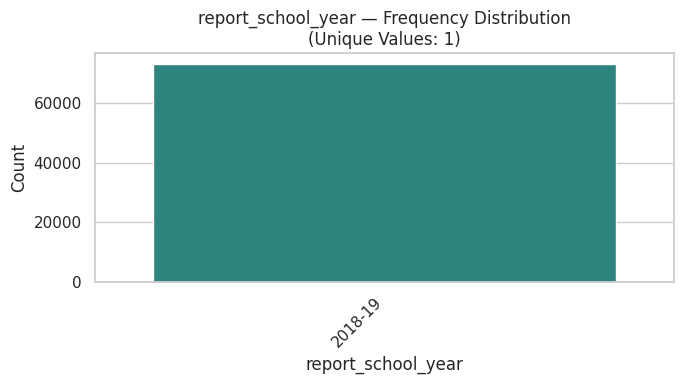

In [ ]:
plot_categorical_univariate(df, 'report_school_year')


**Findings:**

The analysis confirms our initial hypothesis. Both the frequency table and the bar plot show that the `report_school_year` attribute contains only **one unique value: "2018-19"**. This single category accounts for **100.0%** of the 73,152 observations in the dataset.

* **Data Validation:** This result successfully validates that our dataset is correctly scoped to the 2018-2019 academic year.
* **Modeling Impact:** As a **constant, single-value feature**, `report_school_year` has zero variance.

 Given its lack of predictive value, we will flag this column for **removal** during the data preparation phase to streamline our models and reduce unnecessary complexity.





### **3.1.2. aggregation_index**

Next, we examine the `aggregation_index` variable. According to the data dictionary, this is a "Numeric code identifying manner in which high school graduation data has been aggregated." Our earlier `.describe()` summary already suggested that this column might be a constant value, as its mean, median, and standard deviation were all identical.

The purpose of this step is to formally verify this observation using our univariate analysis function. If `aggregation_index` holds only a single value for all 73,152 rows, it is a zero-variance predictor.


Frequency Table for 'aggregation_index'


,Count,Percent (%)
aggregation_index,,
3,73152,100.0


/tmp/ipython-input-2243188230.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


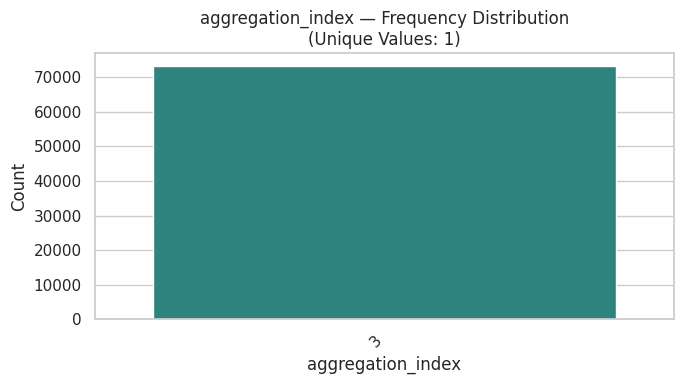

In [ ]:
plot_categorical_univariate(df, 'aggregation_index')


**Findings:**

*  The analysis of `aggregation_index` confirms our earlier suspicion from the descriptive statistics. The frequency table and bar plot both clearly show that the variable has only **one unique value: `3`**. This value is present in all 73,152 rows, accounting for 100% of the dataset.



*   **Zero Predictive Value:** Just like `report_school_year`, `aggregation_index` is a zero-variance feature. It offers no information that can be used to explain the variation in our target variable, `dropout_pct_level`. A model cannot learn any patterns from a feature that does not change.
*   **Model Simplification:** Including this constant feature in our models would add unnecessary complexity without providing any benefit. We have now identified a second column that can be confidently slated for removal during the feature selection phase of our data preparation.

This methodical check of each variable is proving effective in identifying and flagging non-informative features early in the process.


### **3.1.3. aggregation_type**

Continuing our systematic review of the dataset's features, we now turn our attention to `aggregation_type`. The data dictionary defines this as the "Text description of how high school graduation data has been aggregated." This variable tells us the level at which the data is summarized—for example, at the school, district, or county level.

Given that the previous two identifier columns (`report_school_year` and `aggregation_index`) were found to be constants, we will investigate `aggregation_type` to see if it follows the same pattern. Understanding the level of aggregation is fundamental; if all data is aggregated at the same level (e.g., "District"), then this feature, like the others, would have no variance. For our task of building predictive models, a constant feature provides no value in distinguishing between outcomes, making it a prime candidate for removal. We will now run our analysis function to determine its distribution.




Frequency Table for 'aggregation_type'


,Count,Percent (%)
aggregation_type,,
District,73152,100.0


/tmp/ipython-input-2243188230.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


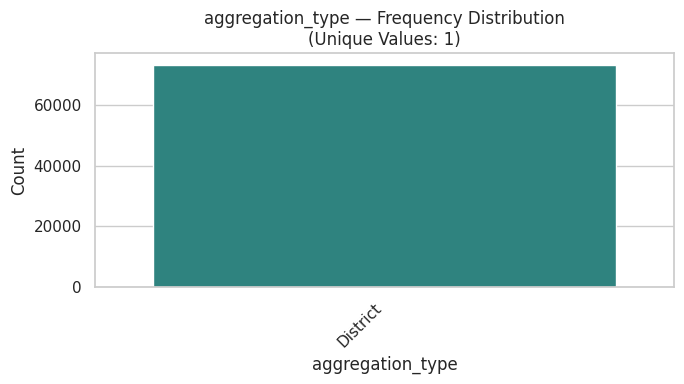

In [ ]:
plot_categorical_univariate(df, 'aggregation_type')




**Findings:**

The analysis confirms that `aggregation_type` is another constant feature within this dataset. The frequency table and the corresponding bar plot show that 100% of the 73,152 records have the single value **"District"**.

**Implications:**

*   **Data Context:** This finding clarifies that every observation in our dataset represents data aggregated at the school district level. There are no other levels of aggregation (like individual school or county-level summaries) present.
*   **Modeling Impact:** As a zero-variance feature, `aggregation_type` offers no predictive information. It cannot help a Decision Tree or Random Forest model create splits or find patterns related to our `dropout_pct_level` target variable.

This is the third consecutive feature we have identified as being non-informative for our modeling purposes. We will add `aggregation_type` to our list of columns to be dropped during data preparation, further simplifying our feature set to focus only on variables that have the potential to be predictive.


### **3.1.4. aggregation_name**

We now examine `aggregation_name`, which the data dictionary describes as the "Text description of how high school graduation data has been aggregated." Since we've confirmed the `aggregation_type` is always "District," this feature effectively represents the specific name of each school district.

Unlike the previous constant-value identifiers, we expect this variable to have many unique values. The purpose of this analysis is to quantify this "cardinality"—the number of distinct school districts in our dataset. High-cardinality categorical features can be challenging for machine learning models.

Our custom function is designed to handle this scenario: it will display a frequency table to give us an idea of the distribution but will skip generating a bar plot, as a chart with hundreds of bars would be unreadable.



In [ ]:
plot_categorical_univariate(df, 'aggregation_name')



Frequency Table for 'aggregation_name'


,Count,Percent (%)
aggregation_name,,
KINGSTON CITY SCHOOL DISTRICT,138,0.19
WILLIAMSVILLE CENTRAL SCHOOL DISTRICT,136,0.19
GREECE CENTRAL SCHOOL DISTRICT,134,0.18
RIVERHEAD CENTRAL SCHOOL DISTRICT,134,0.18
ROCHESTER CITY SCHOOL DISTRICT,134,0.18
...,...,...
LONG LAKE CENTRAL SCHOOL DISTRICT,70,0.10
KIRYAS JOEL VILLAGE UNION FREE SCHOOL DISTRICT,66,0.09
GREENBURGH-NORTH CASTLE UNION FREE SCHOOL DISTRICT,56,0.08


Skipping plot for 'aggregation_name' due to high cardinality.


**Findings:**

The `aggregation_name` variable represents individual school districts across New York State. Our analysis reveals critical characteristics that impact its viability as a predictive feature:

**Distribution Characteristics:**
- **High Cardinality**: 680 unique school districts in the dataset
- **Sparse Distribution**: The most frequent district (Kingston City School District) appears only 138 times (0.19% of observations)
- **Even Spread**: Most districts have similar low frequencies, ranging from 40-138 observations
- **No Dominant Categories**: The lack of concentration in any particular districts suggests relatively balanced representation across the state

**Technical Considerations:**
Our custom plotting function correctly identified this as a high-cardinality variable and provided a frequency table instead of a visualization, which would have been unreadable with 680 categories.

**Modeling Implications:**

This variable presents significant challenges for our classification models:

1. **Dimensionality Explosion**: One-hot encoding would create 680 binary features, drastically increasing model complexity
2. **Overfitting Risk**: With so many sparse categories, the model might memorize district-specific patterns rather than learning generalizable relationships
3. **Computational Cost**: Training time and memory requirements would increase substantially
4. **Limited Predictive Value**: The variable functions more as an identifier than a meaningful predictor of dropout rates.

**Decision:**
We will **exclude `aggregation_name`** from our feature set. While district-specific information might contain some signal, the cost-benefit tradeoff strongly favors exclusion for this assignment. Alternative approaches like target encoding or grouping districts by characteristics could be explored in future analyses but are beyond our current scope.

**Visualizing Top 20 School Districts**

While our previous analysis established that plotting all 680 unique school districts is not feasible, we can still gain valuable insight by examining the most frequently occurring ones. A "long tail" distribution, where a few items appear frequently while most appear rarely, is common in such data.

To gain a visual understanding of the most represented districts in our dataset, we will create a bar plot that specifically visualizes the **top 20 most frequent** `aggregation_name` values. This will help us see the scale of the largest districts relative to one another and understand the distribution at the head of the frequency table. The x-axis labels (district names) will be rotated 90 degrees to ensure they are readable and do not overlap.

/tmp/ipython-input-2766194625.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-2766194625.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


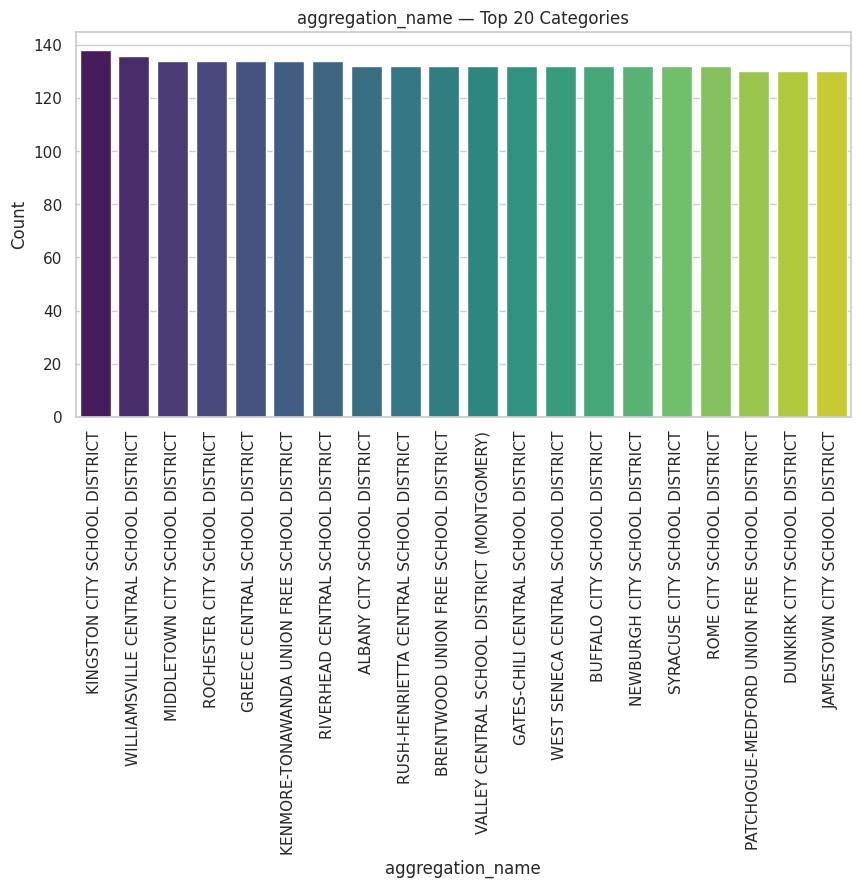

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=df['aggregation_name'].value_counts().head(20).index.astype(str),
    y=df['aggregation_name'].value_counts().head(20).values,
    palette="viridis"
)
plt.title("aggregation_name — Top 20 Categories")
plt.ylabel("Count")
plt.xlabel("aggregation_name")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



**Findings:**

* The bar chart successfully visualizes the 20 most frequently occurring school districts in the dataset. The key observation from this plot is how remarkably similar the counts are for these top districts. The frequency ranges from a high of approximately 138 for "KINGSTON CITY SCHOOL DISTRICT" down to just under 130 for "JAMESTOWN CITY SCHOOL DISTRICT."


*   **Flat Distribution:** This visualization clearly illustrates the "flat head" of a long-tail distribution. There is no single district or small group of districts that dominates the dataset. The observations are distributed very evenly among the most common categories.
*   **Reinforces Decision to Exclude:** This visual evidence further strengthens our decision to exclude `aggregation_name` as a predictive feature. Since even the most common districts represent a tiny fraction of the data and have very similar observation counts, a model would struggle to extract any generalizable signal. Attempting to use this feature would almost certainly lead to overfitting, where the model learns noise specific to individual districts rather than meaningful patterns applicable across the entire state.

This concludes our analysis of the district name. We will proceed by excluding this feature from our modeling dataset.

### **3.1.5. nrc_code**

We now shift our analysis to `nrc_code`. According to the data dictionary, this is a crucial feature: a "Numeric code identifying 'needs / resource capacity', which is an indicator of the type of school district." This is the first variable we have encountered that seems likely to have a direct, substantive relationship with student outcomes and, therefore, our target variable `dropout_pct_level`.

The purpose of this analysis is to understand the distribution of these district types across our dataset. A school district's resource level could be a powerful predictor of the academic achievement of its students. We will use our custom function to generate both a frequency table and a bar plot. Unlike the previous identifier columns, we expect `nrc_code` to have a small, manageable number of categories and an uneven distribution, which could provide significant predictive power for our classification models.




Frequency Table for 'nrc_code'


,Count,Percent (%)
nrc_code,,
5,35322,48.29
4,14968,20.46
6,13068,17.86
3,5228,7.15
1,4042,5.53
2,524,0.72


/tmp/ipython-input-2243188230.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


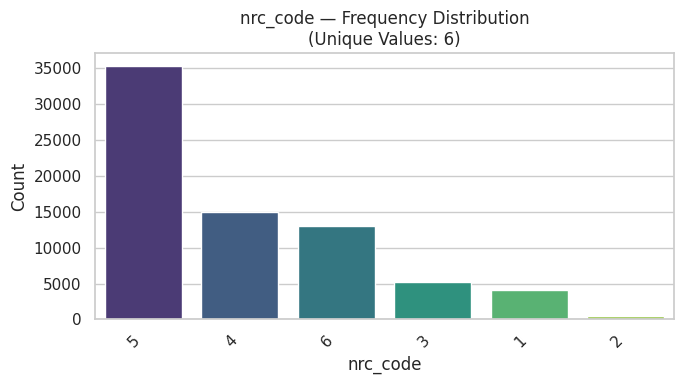

In [ ]:
plot_categorical_univariate(df, 'nrc_code')



**Findings:**

The analysis of `nrc_code` reveals a variable with strong potential for our models. The output shows **6 unique categories**, representing different levels of school district needs and resources.

*   **Distribution:** The data is not evenly distributed across these categories. There is a clear concentration in three main codes:
    *   Code `5` is the most dominant category, comprising **48.29%** of the dataset.
    *   Codes `4` and `6` are also highly represented, accounting for **20.46%** and **17.86%**, respectively.
    *   Combined, these three codes (`5`, `4`, and `6`) make up over 86% of all observations.
    *   In contrast, Code `2` is extremely rare, appearing in less than 1% of the data.

**Implications:**

*   **High Predictive Potential:** This feature is an excellent candidate for inclusion in our Decision Tree and Random Forest models. The limited number of categories makes it easy for the models to handle, and the imbalanced distribution means the models can potentially learn strong rules. For example, if a high or low `dropout_pct_level` is disproportionately associated with `nrc_code` `5`, this feature will be very influential.
*   **Next Step:** While we have the numeric codes, the corresponding text descriptions in the `nrc_desc` column will provide the actual meaning behind these numbers (e.g., "High Need," "Average Need"). Our next step will be to analyze `nrc_desc` to link these codes to their real-world interpretations.


### **3.1.6. nrc_desc**

Following our analysis of `nrc_code`, we will now examine its corresponding text-based counterpart, `nrc_desc`. The data dictionary defines this as the "Text description of the type of school district." This variable is crucial because it provides the human-readable meaning behind the numeric codes we just observed (e.g., translating code `5` to "Average Needs").

The primary goal of this step is twofold:
1.  **Validation:** We need to confirm that `nrc_desc` has the same number of unique values and the same frequency distribution as `nrc_code`. This ensures the one-to-one relationship between the code and its description is consistent throughout the dataset.
2.  **Interpretation:** By analyzing the text labels, we can gain a much richer, intuitive understanding of our dataset's composition. Knowing that nearly half the observations come from "Average Needs" districts is a far more useful insight for model interpretation than knowing they come from `nrc_code` `5`.

This analysis will provide the semantic context necessary to understand the potential impact of this key explanatory variable on our target, `dropout_pct_level`.



Frequency Table for 'nrc_desc'


,Count,Percent (%)
nrc_desc,,
Average Needs,35322,48.29
Rural High Needs,14968,20.46
Low Needs,13068,17.86
Urban-Suburban High Needs,5228,7.15
NYC,4042,5.53
Buffalo Rochester Yonkers Syracuse,524,0.72


/tmp/ipython-input-2243188230.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


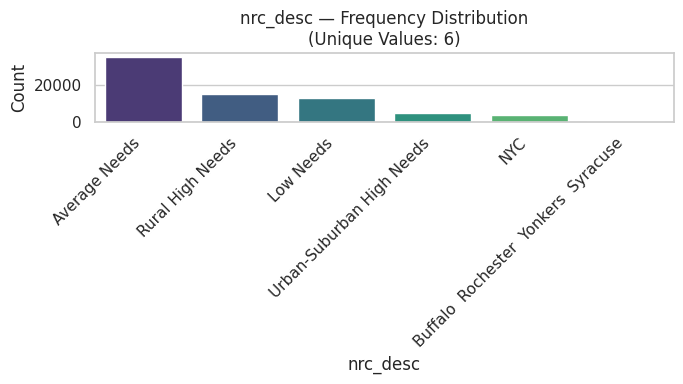

In [ ]:
plot_categorical_univariate(df, 'nrc_desc')


**Findings:**


The analysis of nrc_desc closely aligns with the earlier review of nrc_code, providing clearer, human-readable labels for the district categories.


* **Perfect Correspondence:**

The frequency table and bar plot show 6 unique categories, and their counts and percentages appear to match those of nrc_code. For example, “Average Needs” has 35,322 occurrences (48.29%), consistent with the distribution observed in the coded version.


* **Category Distribution:**

The largest proportion of districts falls under "Average Needs" (48.3%), followed by "Rural High Needs" (20.5%) and "Low Needs" (17.9%).
The smallest category corresponds to major city districts such as "Buffalo Rochester Yonkers Syracuse" (0.72%).


**Implications:**


* Informational Redundancy:

Since nrc_desc and nrc_code reflect the same underlying grouping, they are effectively duplicate representations of the same information. Including both may introduce redundancy. For modeling, we may choose either representation.

nrc_desc offers interpretability, while nrc_code may be easier for algorithms to process directly.

### **3.1.7. county_code**

Next in our univariate analysis is `county_code`, the "Numeric code for county name." This feature provides geographical information, grouping school districts by their respective counties within New York State. Geographic location can often be a proxy for various socio-economic factors, which in turn could influence student performance and thus be relevant to our prediction of `dropout_pct_level`.

The main purpose of this step is to assess the cardinality and distribution of this feature. We need to determine how many unique counties are represented in our data. Similar to our analysis of `aggregation_name`, if the number of unique counties is very high, it could pose a challenge for our models. Our custom function will produce a frequency table to show the number of observations per county, but we anticipate it will skip the plot due to the expected high cardinality. This will help us decide whether `county_code` is a viable feature for our models.



In [ ]:
plot_categorical_univariate(df, 'county_code')



Frequency Table for 'county_code'


,Count,Percent (%)
county_code,,
58,6526,8.92
28,5190,7.09
66,4834,6.61
14,3202,4.38
26,2196,3.00
...,...,...
7,340,0.46
20,226,0.31
68,212,0.29


Skipping plot for 'county_code' due to high cardinality.


**Findings:**

The analysis of `county_code` confirms that it is a high-cardinality categorical feature.

*   **Cardinality:** The frequency table output shows **62 rows**, indicating that there are **62 unique counties** represented in the dataset. As expected, our function correctly identified this as a high-cardinality feature and skipped generating a bar plot.
*   **Distribution:** The observations are not evenly distributed among the counties. The top five most frequent counties account for a significant portion of the data, with county code `58` alone representing nearly 9% of all observations. In contrast, the least frequent counties make up a very small fraction of the dataset.

**Implications:**

*   **Modeling Consideration:** With 62 unique levels, `county_code` presents a similar challenge to `aggregation_name`. While not as extreme as 680 categories, directly one-hot encoding this feature would still add 62 columns to our dataset, increasing complexity and the risk of overfitting.
*   **Potential Redundancy:** The `nrc_desc` feature (with categories like "Rural High Needs," "NYC," etc.) likely captures much of the socio-economic and geographic information that `county_code` provides, but in a much more condensed and usable format (only 6 categories).
*   **Decision:** Given the high cardinality and the fact that its predictive signal is likely captured more efficiently by `nrc_desc`, we will exclude `county_code` from our final set of explanatory variables. This helps maintain a simpler, more robust model, which is a key consideration in the trade-off between performance and complexity.

**Visualizing Top 20 County Codes**

Our previous analysis revealed that the `county_code` feature has 62 unique categories, making a complete visualization impractical. To better understand the geographic distribution of our data, we can focus on the most heavily represented counties.

The following code will generate a bar plot specifically for the **top 20 most frequent county codes**. This approach allows us to visually inspect the "head" of the distribution and see how the observation counts for the largest counties compare to one another. It will help us confirm if the dataset is dominated by a few major counties or if the observations are more evenly spread across the top tier. The x-axis labels (the county codes) will be rotated to ensure they are readable.

/tmp/ipython-input-796386403.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


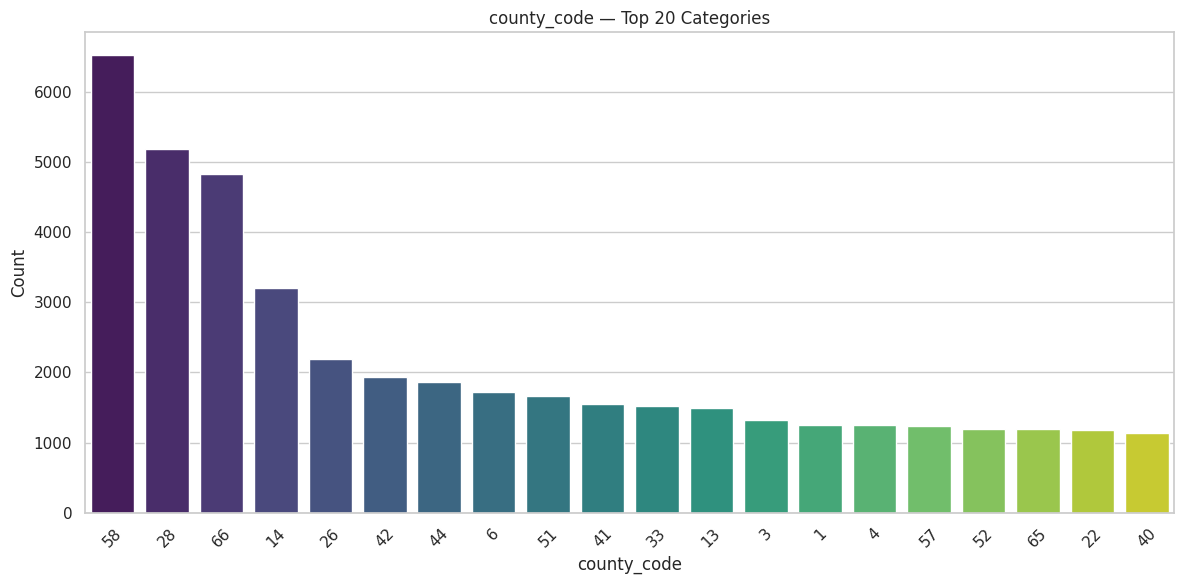

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=df['county_code'].value_counts().head(20).index.astype(str),
    y=df['county_code'].value_counts().head(20).values,
    palette="viridis"
)
plt.title("county_code — Top 20 Categories")
plt.ylabel("Count")
plt.xlabel("county_code")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



**Findings:**

The bar chart of the top 20 `county_code` values provides a clear visual representation of the geographic concentration in our dataset. Unlike the flat distribution we saw for the top school districts, the county distribution is noticeably skewed.

*   **Concentrated Data:** A few counties are responsible for a large number of the observations. The most frequent county, code `58`, has over 6,000 records. The next two, codes `28` and `66`, each have around 5,000. There is a distinct drop-off in frequency after these top three.
*   **Long Tail Confirmation:** This plot visualizes the "head" of a long-tail distribution, confirming that while many counties are present in the data, a disproportionate number of observations come from a select few.

**Implications:**

*   **Reinforces Decision:** This visualization reinforces our decision to exclude `county_code` from our final model. While there is a clear signal of geographic concentration, the high cardinality of 62 unique counties remains a significant challenge. Using this feature would likely cause the model to learn rules specific to these large counties that may not generalize well to the rest of the state.
*   **Proxy Variable:** The `nrc_desc` feature (e.g., "NYC," "Rural High Needs") likely serves as a better, more abstract proxy for the geographic and socio-economic factors that `county_code` represents, but with far fewer categories. Sticking with `nrc_desc` allows us to capture this essential information without introducing unnecessary complexity.

### **3.1.8. county_name**

To complete our analysis of the geographic features, we will now examine `county_name`, which is the text-based equivalent of `county_code`. The data dictionary defines it as the "Full name of applicable NY State county."

The primary purpose of this step is to validate the consistency between the numeric code and its text description. We expect a perfect one-to-one correspondence, meaning `county_name` should also have 62 unique values and an identical frequency distribution to `county_code`. Analyzing the names themselves (e.g., "SUFFOLK," "NASSAU") provides a more intuitive understanding of the data's geographic sources. However, as this is another high-cardinality feature, we anticipate our function will only display the frequency table, which is sufficient to confirm its characteristics and justify our decision-making for the modeling phase.



In [ ]:
plot_categorical_univariate(df, 'county_name')



Frequency Table for 'county_name'


,Count,Percent (%)
county_name,,
SUFFOLK,6526,8.92
NASSAU,5190,7.09
WESTCHESTER,4834,6.61
ERIE,3202,4.38
MONROE,2196,3.00
...,...,...
CHEMUNG,340,0.46
HAMILTON,226,0.31
YATES,212,0.29


Skipping plot for 'county_name' due to high cardinality.


**Findings:**

The analysis of `county_name` confirms that it is the direct text representation of `county_code`.

*   **Perfect Correspondence:** The output shows **62 unique county names**, exactly matching the cardinality of `county_code`. The frequency counts are also identical; for example, "SUFFOLK" has 6,526 observations (8.92%), which is the same count as the top `county_code` (`58`).
*   **High Cardinality:** As expected, the feature's high cardinality prompted our function to skip generating a bar plot.

**Implications:**

*   **Informational Redundancy:** The features `county_name` and `county_code` are perfectly correlated and thus redundant. For any modeling purpose, we would only ever consider using one.
*   **Final Decision on Geographic Features:** This analysis finalizes our decision to exclude specific county-level data from our models. The high cardinality poses a significant risk of overfitting, and the more generalized `nrc_desc` feature (which includes categories like "NYC" and "Rural High Needs") likely captures the relevant geographic and demographic signals in a much more efficient and powerful way. We will proceed without `county_name` and `county_code` to build a more robust and simpler model.



**Visualizing Top 20 County Names**

While we have decided to exclude county-level data from our model, a visual representation of the most common counties provides valuable context about the dataset's composition. To supplement the frequency table, we will now plot the **top 20 most frequent county names**.

This bar chart will provide a more intuitive view of the geographic distribution than the numeric codes did. We will be able to see, by name, which counties contribute the most observations to our dataset. This visualization will confirm the skewed distribution we observed with `county_code` and put clear, readable labels to the most significant geographic areas in our study. The x-axis labels will be rotated for clarity.

/tmp/ipython-input-2060199848.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


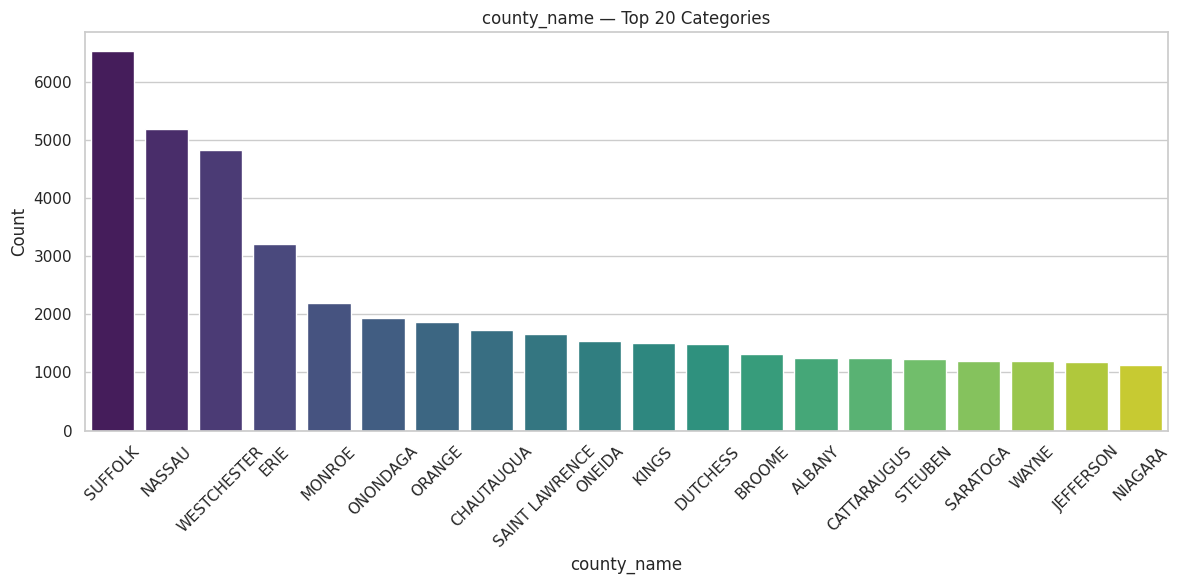

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=df['county_name'].value_counts().head(20).index.astype(str),
    y=df['county_name'].value_counts().head(20).values,
    palette="viridis"
)
plt.title("county_name — Top 20 Categories")
plt.ylabel("Count")
plt.xlabel("county_name")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Findings:**

The bar chart provides a clear and interpretable view of the top 20 counties by name, confirming the distribution patterns observed with the numeric county codes.

*   **Geographic Concentration:** The data is heavily concentrated in a few populous counties. **Suffolk**, **Nassau**, and **Westchester**—all large suburban counties in the New York City metropolitan area—are the three most represented counties by a significant margin.
*   **Skewed Distribution:** The plot clearly shows the steep drop-off in frequency after the top few counties, visually confirming the skewed, long-tail distribution of the data's geographic sources.

**Implications:**

*   **Dataset Context:** This visualization provides important context. A substantial portion of our data comes from a specific type of geographic and demographic environment (i.e., populous suburban areas). This is a critical piece of information to keep in mind when interpreting our final model's results.
*   **Reinforces Modeling Decision:** By putting names to the codes, this chart reinforces our decision to exclude county-level features. A model trained on this data could easily become biased towards the characteristics of Suffolk and Nassau counties and might not generalize well to less-represented rural counties. Using the more abstract `nrc_desc` feature is a much sounder approach to capture geographic effects without overfitting to specific locations.

This completes our deep dive into the geographic identifier variables. We have established that they are either redundant or too high-cardinality for our modeling purposes and will proceed with the analysis of other features.

### **3.1.9. nyc_ind**

We now turn to `nyc_ind`, a binary feature that, according to the data dictionary, "Indicates whether or not the school district resides within the borders of NYC." This is a potentially powerful explanatory variable. The New York City public school system is the largest in the United States and operates under a unique set of administrative structures, demographic contexts, and resource challenges compared to the rest of the state.

The purpose of this analysis is to quantify the proportion of our data that comes from NYC versus non-NYC school districts. A significant imbalance could influence how our models learn.They can easily learn a rule based on this split, which might be highly effective in predicting `dropout_pct_level` if outcomes differ systematically between NYC and the rest of the state.




Frequency Table for 'nyc_ind'


,Count,Percent (%)
nyc_ind,,
0,69110,94.47
1,4042,5.53


/tmp/ipython-input-2243188230.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


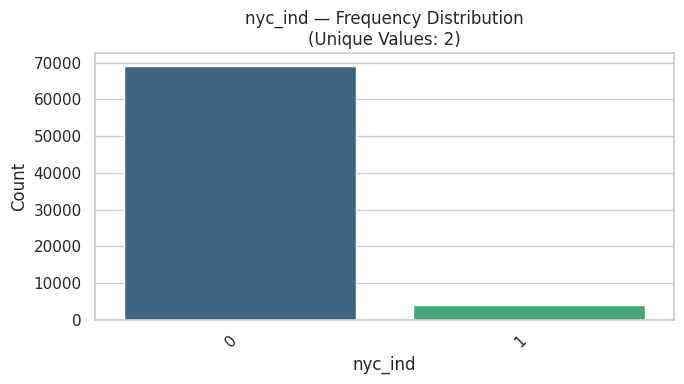

In [ ]:
plot_categorical_univariate(df, 'nyc_ind')


**Findings:**

The analysis of the `nyc_ind` variable provides a clear picture of the dataset's geographic focus.

*   **Heavy Imbalance:** The dataset is overwhelmingly composed of school districts from outside New York City. The frequency table and bar chart show that **94.47%** of the observations have `nyc_ind = 0` (non-NYC), while only **5.53%** have `nyc_ind = 1` (NYC).
*   **Validation:** The total count for `nyc_ind = 1` is 4,042. This perfectly matches the count we previously observed for the "NYC" category within the `nrc_desc` feature, validating the consistency between these two variables.

**Implications:**

*   **High Predictive Potential:** The stark difference between NYC and the rest of the state makes this a very promising feature. A simple rule like "Is the district in NYC?" could be a very powerful first split for a Decision Tree model in separating student outcomes.
*   **Informational Redundancy:** Because the information in `nyc_ind` is perfectly captured by the "NYC" category in the more comprehensive `nrc_desc` feature, including both in our model would be redundant. The `nrc_desc` variable contains all the information of `nyc_ind` plus additional distinctions (e.g., "Rural High Needs," "Low Needs"). Therefore, `nrc_desc` is the more powerful and complete feature.
*   **Decision:** We will select `nrc_desc` for our final model and exclude `nyc_ind` to avoid this redundancy and multicollinearity. This analysis confirms the potential importance of the NYC/non-NYC distinction while guiding us to choose the more informative feature.

### **3.1.10. membership_desc**

Next, we analyze `membership_desc`, which the data dictionary describes as the "school year in which students first enrolled in High School." This feature identifies the specific student cohort being measured in each observation (e.g., "2015 Total Cohort"). Understanding the different cohorts is important for contextualizing the graduation outcomes.

The goal of this analysis is to examine the distribution of these cohorts. Are we looking at data from many different graduating classes, or just a few? Is the data evenly spread among them? While it might not be the most direct predictor of `dropout_pct_level` compared to a variable like `nrc_desc`, it's possible that different cohorts experienced different educational conditions that could affect their outcomes. We will use our custom function to generate a frequency table to understand the composition of this feature.





In [ ]:
plot_categorical_univariate(df, 'membership_desc')



Frequency Table for 'membership_desc'


,Count,Percent (%)
membership_desc,,
2015 Total Cohort - 4 Year Outcome - August 2019,12299,16.81
2015 Total Cohort - 4 Year Outcome,12299,16.81
2014 Total Cohort - 5 Year Outcome - August 2019,12257,16.76
2014 Total Cohort - 5 Year Outcome,12257,16.76
2013 Total Cohort - 6 Year Outcome,12020,16.43
2013 Total Cohort - 6 Year Outcome - August 2019,12020,16.43


Skipping plot for 'membership_desc' due to high cardinality.


**Findings:**

The analysis of `membership_desc` reveals a small number of distinct student cohorts, but with some potentially problematic formatting.

*   **Cohort Groups:** The frequency table shows that the data is primarily split among three main cohorts: the **2015 Cohort (4-Year Outcome)**, the **2014 Cohort (5-Year Outcome)**, and the **2013 Cohort (6-Year Outcome)**.
*   **Data Duplication Issue:** A critical finding is the apparent duplication within the categories. For each cohort, there are two versions: one with " - August 2019" appended and one without. For example, "2015 Total Cohort - 4 Year Outcome - August 2019" and "2015 Total Cohort - 4 Year Outcome" both have exactly 12,299 observations. This suggests a data formatting inconsistency where two labels represent the same underlying group.
*   **Even Distribution:** The data is distributed very evenly across these three main cohort groups (approximately 33% for each, when combining the duplicated labels).

**Implications:**

*   **Data Cleaning Required:** Before this feature can be used for modeling, the inconsistent labels must be cleaned and consolidated. For example, both "2015..." labels should be standardized into a single category.
*   **Limited Predictive Power:** After standardization, we would be left with only three categories ("4-Year Outcome," "5-Year Outcome," "6-Year Outcome"). While there might be some variation in graduation rates between these cohorts, this feature seems less likely to be a primary driver of `dropout_pct_level` compared to district-level characteristics like `nrc_desc`.
*   **Decision:** Given the need for cleaning and its likely secondary importance, we will exclude `membership_desc` from our initial model to maintain simplicity. The effort to clean and incorporate it may not yield a significant improvement in predictive performance for this specific project.


**Visualizing Membership Descriptions**

To visually confirm the findings from our frequency table analysis of `membership_desc`, we will now generate a bar plot. The previous step revealed a critical data formatting issue: what appear to be three distinct student cohorts are each represented by two slightly different text labels, creating six categories in total.

The following code will create a bar chart of all unique values in the `membership_desc` column. We expect this visualization to make the data issue immediately apparent. It should clearly display three pairs of bars of identical height, corresponding to the duplicated cohort labels. This plot will serve as a definitive visual confirmation of the distribution and the need for data cleaning if we were to use this feature in our model. The x-axis labels will be rotated 90 degrees to ensure the full cohort descriptions are readable.

/tmp/ipython-input-2298731494.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


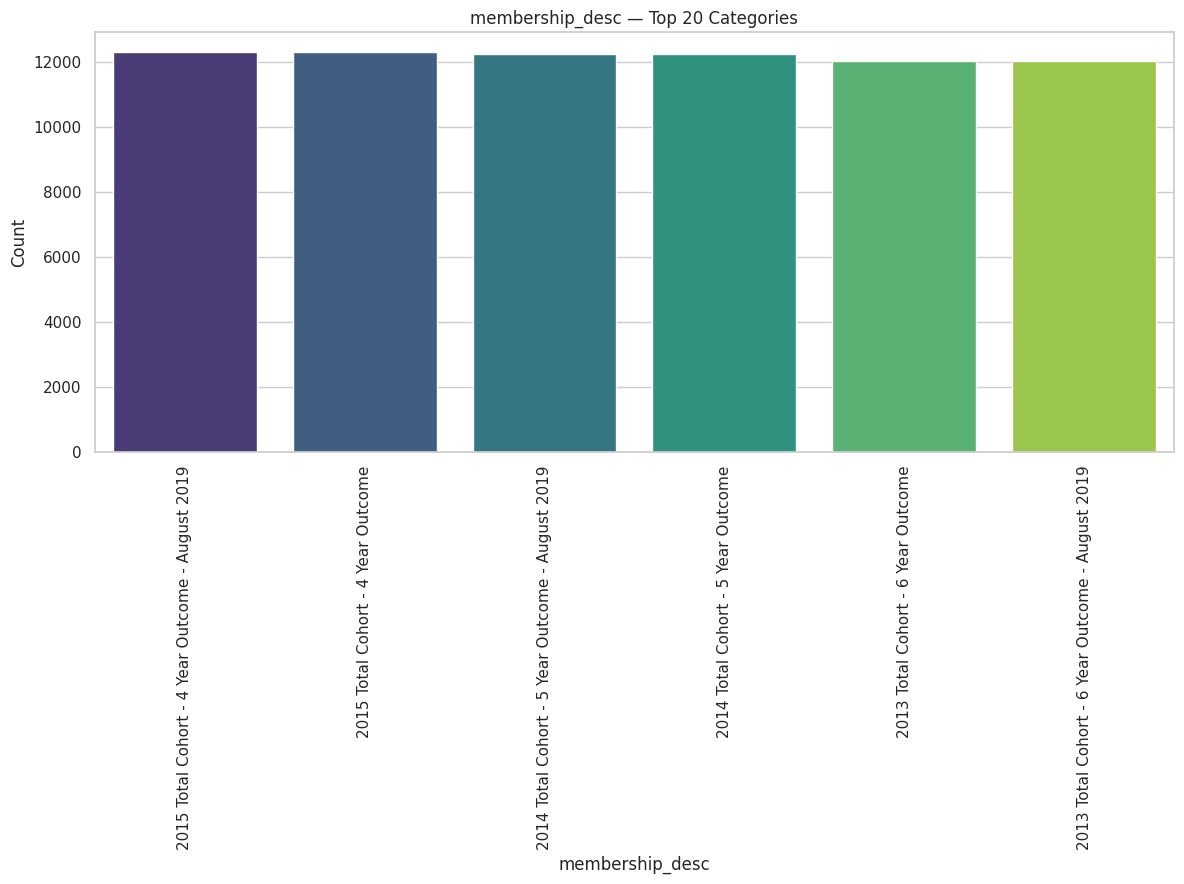

In [ ]:
plt.figure(figsize=(12,9))
sns.barplot(
    x=df['membership_desc'].value_counts().head(20).index.astype(str),
    y=df['membership_desc'].value_counts().head(20).values,
    palette="viridis"
)
plt.title("membership_desc — Top 20 Categories")
plt.ylabel("Count")
plt.xlabel("membership_desc")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


**Findings:**

The bar chart provides a stark visual confirmation of the data quality issue identified in the frequency table.

*   **Clear Duplication:** The plot displays **three distinct pairs of bars**, with each bar in a pair having the exact same height. This corresponds to the three student cohorts (2015, 2014, 2013), where each cohort is represented by two slightly different text labels (one with " - August 2019" and one without).
*   **Even Distribution:** The near-identical height of all six bars clearly shows that the observations are distributed almost perfectly evenly among these cohort definitions.

**Implications:**

*   **Confirms Need for Cleaning:** This visualization makes the inconsistent labeling undeniable. If we were to use this feature for modeling, a mandatory preprocessing step would be to standardize these six labels into three unique categories to prevent the model from incorrectly treating them as separate groups.
*   **Supports Exclusion Decision:** This chart reinforces our decision to exclude `membership_desc` from our model for this assignment. While the feature could be cleaned, its even distribution suggests it may have limited predictive power. For the sake of model simplicity and focusing on more impactful variables like `nrc_desc`, omitting this feature is a practical choice. The effort required to clean it is not justified by its likely low contribution to the model's performance.

This concludes our analysis of the cohort membership description.



### **3.1.11. subgroup_code**

We now arrive at one of the most critical features in the dataset: `subgroup_code`. The data dictionary defines this as the "Numeric code identifying student subgrouping." Each row of our data represents an outcome for a specific demographic or academic group (e.g., by gender, race/ethnicity, disability status). This variable is the identifier for that group.

The goal of this analysis is to understand the variety and distribution of these subgroups. How many distinct subgroups are tracked in this dataset? Are observations evenly distributed among them? The nature of these subgroups is central to our project's purpose of predicting diploma attainment levels. We fully expect this feature, or its text-based equivalent `subgroup_name`, to be a primary predictor in our models. Differences in educational outcomes across various demographic groups are a well-documented phenomenon, and this variable is our key to exploring that pattern. We will begin by examining the numeric codes before moving on to their descriptions.




Frequency Table for 'subgroup_code'


,Count,Percent (%)
subgroup_code,,
1,4074,5.57
18,4074,5.57
25,4074,5.57
21,4074,5.57
23,4070,5.56
3,4068,5.56
12,4068,5.56
2,4060,5.55
10,4056,5.54


/tmp/ipython-input-2243188230.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


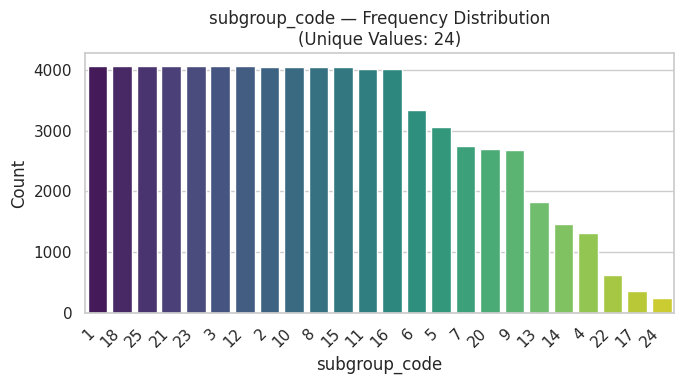

In [ ]:
plot_categorical_univariate(df, 'subgroup_code')


**Findings:**

The analysis of subgroup_name provides readable labels for the subgroup codes and helps contextualize the demographic representation in our dataset.

**Perfect Correspondence:**
The output shows 24 unique subgroup names, with counts and percentages that correspond to the earlier subgroup_code analysis. For example, common categories like “All Students,” “Not Migrant,” and “Parent Not in Armed Forces” each appear roughly 4,074 times (5.57%).

**Demographic Diversity:**
The subgroups capture a wide range of student characteristics, including:

* General Population: “All Students,” “Male,” “Female.”

* Race/Ethnicity: “White,” “Black,” “Hispanic,” “Asian/Pacific Islander.”

* Economic Status: “Economically Disadvantaged,” “Not Economically Disadvantaged.”

* Special Populations: “Students with Disabilities,” “English Language Learner,” “Homeless,” “Migrant.”

Distribution Pattern:
The bar plot indicates variation across subgroup frequencies, with some subgroups appearing very frequently and others less common — a pattern consistent with the coded variable.

Implications:

Potential Relevance:
Because subgroup_name captures demographic distinctions, it may be informative for downstream modeling. However, this remains a hypothesis; its actual predictive influence will need to be confirmed during model training and evaluation.


Frequency Table for 'subgroup_name'


,Count,Percent (%)
subgroup_name,,
All Students,4074,5.57
Not Migrant,4074,5.57
Parent Not in Armed Forces,4074,5.57
Not Homeless,4074,5.57
Not in Foster Care,4070,5.56
Male,4068,5.56
Not English Language Learner,4068,5.56
Female,4060,5.55
General Education Students,4056,5.54


/tmp/ipython-input-2243188230.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index.astype(str), y=vc.values, palette="viridis")


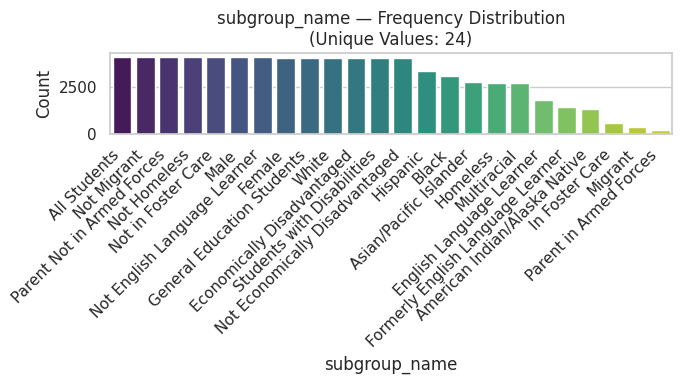

In [ ]:
plot_categorical_univariate(df, 'subgroup_name')




**Findings:**


*   **Rich Demographic Detail:** We can now clearly see the diverse range of subgroups being tracked, which include categories based on:
    *   **General Population:** "All Students," "Male," "Female."
    *   **Race/Ethnicity:** "White," "Black," "Hispanic," "Asian/Pacific Islander."
    *   **Economic Status:** "Economically Disadvantaged," "Not Economically Disadvantaged."
    *   **Special Populations:** "Students with Disabilities," "English Language Learner," "Homeless," "Migrant."
*   **Distribution Confirmed:** The bar plot mirrors the tiered distribution of the codes, showing a large set of very common subgroups and a smaller set of less frequent ones.

The analysis of subgroup_name provides readable labels for the subgroup codes and helps contextualize the demographic representation in our dataset.

Perfect Correspondence:
The output shows 24 unique subgroup names, with counts and percentages that correspond to the earlier subgroup_code analysis. For example, common categories like “All Students,” “Not Migrant,” and “Parent Not in Armed Forces” each appear roughly 4,074 times (5.57%).

Demographic Diversity:
The subgroups capture a wide range of student characteristics, including:

General Population: “All Students,” “Male,” “Female.”

Race/Ethnicity: “White,” “Black,” “Hispanic,” “Asian/Pacific Islander.”

Economic Status: “Economically Disadvantaged,” “Not Economically Disadvantaged.”

Special Populations: “Students with Disabilities,” “English Language Learner,” “Homeless,” “Migrant.”

Distribution Pattern:
The bar plot indicates variation across subgroup frequencies, with some subgroups appearing very frequently and others less common — a pattern consistent with the coded variable.

Revised Implications:

Potential Relevance:
Because subgroup_name captures demographic distinctions, it may be informative for downstream modeling. However, this remains a hypothesis; its actual predictive influence will need to be confirmed during model training and evaluation.


## **3.2. Univariate Analysis: Numerical Variables**

Having thoroughly explored the categorical features, we now shift our focus to the **numerical variables**. This phase of the univariate analysis is crucial for understanding the distribution, central tendency, and spread of the key quantitative metrics in our dataset. These metrics, such as enrollment counts and graduation percentages, are at the core of our study and will be the basis for our predictive models.

To maintain a consistent and efficient workflow, we will first define a new custom helper function called `plot_numeric_univariate`. This function is designed to provide a comprehensive summary for any given numerical column by generating three key outputs:
1.  **Summary Statistics:** A table displaying the count, mean, standard deviation, min/max, and quartile values. This gives us a precise quantitative overview.
2.  **Histogram with KDE:** A plot to visualize the shape of the variable's distribution. This will help us identify if the data is symmetric (normal), skewed, or has multiple modes.
3.  **Box Plot:** A plot that clearly illustrates the median, interquartile range (IQR), and, critically, helps in identifying the presence and scale of potential outliers.

We will apply this function to each of our seven numerical columns to systematically build a deep understanding of their characteristics, which will be vital for the feature engineering and modeling stages to come.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")

def plot_numeric_univariate(df, col):
    """Displays summary stats, histogram, and boxplot for one numeric variable."""
    print(f"\n Summary Statistics for '{col}'")
    display(pd.DataFrame(df[col].describe()).T)

    fig, ax = plt.subplots(1, 2, figsize=(12,4))

    # Histogram with KDE
    sns.histplot(df[col], kde=True, bins=30, color="skyblue", ax=ax[0])
    ax[0].set_title(f"{col} — Distribution")
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Frequency")

    # Boxplot
    sns.boxplot(x=df[col], color="lightcoral", ax=ax[1])
    ax[1].set_title(f"{col} — Boxplot")
    ax[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()


### **3.2.1. enroll_cnt**

We begin our numerical analysis with `enroll_cnt`, which, according to the data dictionary, represents "How many students of the indicated subgrouping were enrolled during the given school year." This variable provides a measure of the size of each student subgroup in each district.

The purpose of analyzing `enroll_cnt` is to understand the scale of these student populations. Are we dealing with subgroups of similar sizes, or is there a wide variation? The size of a cohort could potentially influence outcomes; for instance, very small subgroups might exhibit more volatile percentage-based metrics, while very large subgroups in certain districts could indicate specific demographic patterns. We will use our custom function to generate summary statistics, a histogram, and a box plot to get a comprehensive view of its distribution and identify any outliers.




 Summary Statistics for 'enroll_cnt'


,count,mean,std,min,25%,50%,75%,max
enroll_cnt,39674.0,192.120079,439.972474,5.0,25.0,66.0,179.0,9176.0


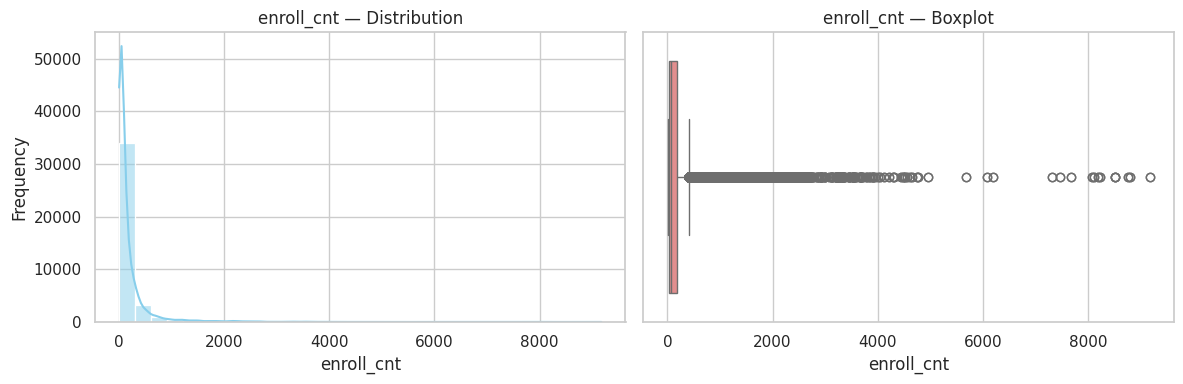

In [ ]:
plot_numeric_univariate(df, 'enroll_cnt')



**Findings:**

The analysis of `enroll_cnt` reveals a distribution that is heavily skewed and concentrated at the lower end, with a long tail of high-value outliers.

*   **Extreme Right Skew:** The histogram shows a classic right-skewed (or positively skewed) distribution. The vast majority of observations are clustered in a large peak at the low end (close to zero), with a frequency that rapidly diminishes as the enrollment count increases.
*   **Disparity Between Mean and Median:** This skew is confirmed by the summary statistics. The **median (50%) enrollment is only 66 students**, while the **mean is much higher at 192.1**. This large difference is caused by the influence of the high-value outliers pulling the mean upwards. 75% of all subgroups have 179 or fewer students.
*   **Numerous Outliers:** The box plot makes the presence of outliers exceptionally clear. The main body of the box (the interquartile range from 25 to 179) is very compressed, while a vast number of data points are flagged as outliers, extending all the way to the maximum value of 9,176.


### **3.2.2. grad_cnt**

Next, we examine `grad_cnt`, which represents the "Number of enrolled students of the indicated subgrouping who graduated at the end of the given school year." This variable is a direct subset of the `enroll_cnt` variable we just analyzed.

We expect `grad_cnt` to follow a very similar distribution pattern to `enroll_cnt` (since you can't graduate more students than are enrolled). However, understanding its specific spread is important because it is the numerator used to calculate graduation percentages. Analyzing this count helps us confirm the magnitude of the success stories in our dataset—how many students are actually achieving graduation across these different groups? We will use our standard numeric analysis function to visualize its distribution and statistics.




 Summary Statistics for 'grad_cnt'


,count,mean,std,min,25%,50%,75%,max
grad_cnt,39674.0,161.178354,361.294773,0.0,20.0,57.0,156.0,7540.0


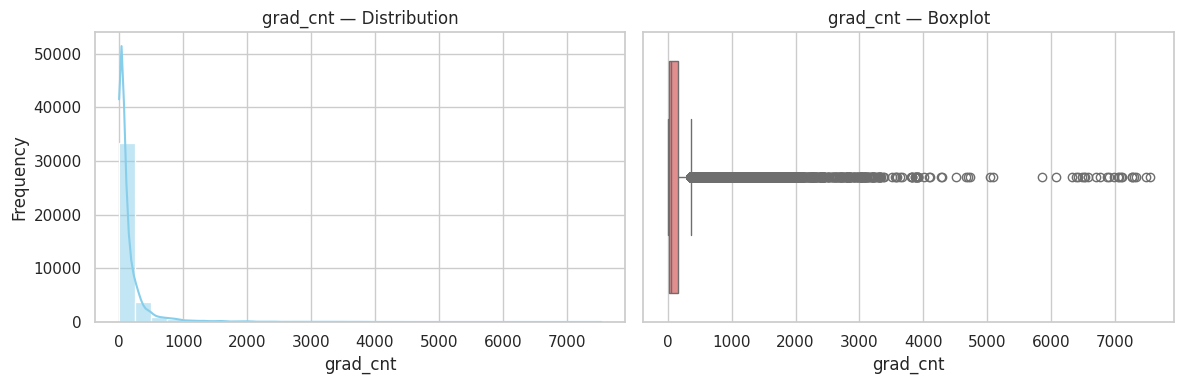

In [ ]:
plot_numeric_univariate(df, 'grad_cnt')


**Findings:**

The analysis of `grad_cnt` confirms that it closely mirrors the distribution of `enroll_cnt`, exhibiting the same extreme right-skew and outlier patterns.

*   **Consistent Skewness:** The histogram is virtually identical in shape to the enrollment histogram, with a massive concentration of values near zero and a long tail extending to the right.
*   **Statistical Confirmation:** The summary statistics reflect this skew: the **median graduation count is 57.0**, while the **mean is significantly higher at 161.2**. The maximum value reaches 7,540, which corresponds to the large enrollment outliers we saw previously.
*   **Compressed IQR:** The box plot again shows a very compressed interquartile range (20 to 156), with a vast array of outliers extending far beyond the main body of data.



### **3.2.3. grad_pct**

We now move from raw counts to a key performance metric: `grad_pct`. This variable represents the "percentage of enrolled students... who graduated." Unlike the raw counts (`enroll_cnt`, `grad_cnt`), which are heavily influenced by the size of the school district, percentages normalize for population size and give us a much clearer picture of actual performance.

The purpose of this analysis is to understand the overall distribution of graduation success across all subgroups. What does a typical graduation rate look like? Is it normally distributed, or are there clusters of high and low performers? This variable is likely to be a strong predictor for our final target, `reg_pct_level`, as a high overall graduation rate may correlate with a high Regents diploma rate. We will use our numeric analysis function to examine its statistics, distribution shape, and outliers.



 Summary Statistics for 'grad_pct'


,count,mean,std,min,25%,50%,75%,max
grad_pct,39674.0,84.406614,15.6795,0.0,79.0,89.0,95.0,100.0


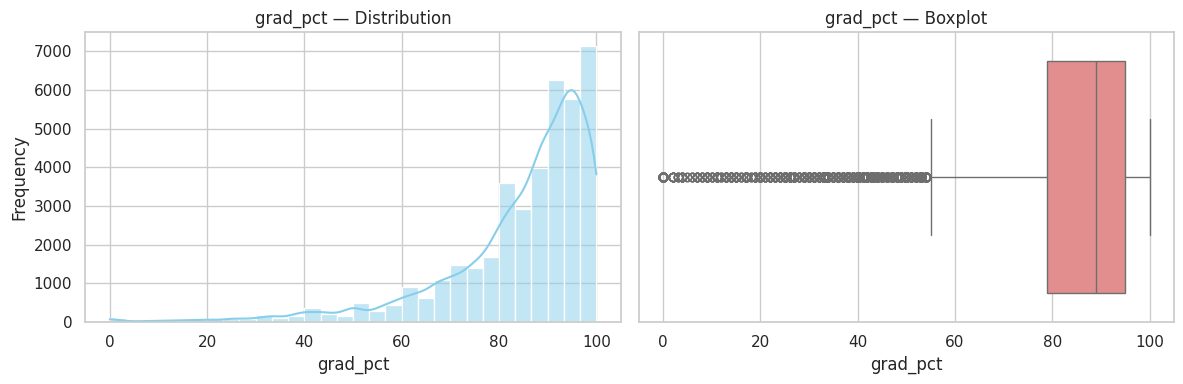

In [ ]:
plot_numeric_univariate(df, 'grad_pct')


**Findings:**

The analysis of `grad_pct` reveals a distribution that is the complete opposite of the raw counts, showing a strong left-skew and a concentration of high-performing subgroups.

*   **Strong Left Skew:** The histogram clearly shows a left-skewed distribution. The vast majority of observations are concentrated at the high end of the scale, with a large peak between 90% and 100%. This indicates that high graduation rates are the norm across the dataset.
*   **High Central Tendency:** The summary statistics confirm this. The **median (50%) graduation rate is a high 89%**, and 75% of all subgroups have a graduation rate of 95% or better. The mean (84.4%) is slightly lower than the median, pulled down by the tail of lower values.
*   **Low-End Outliers:** The box plot provides a stark visualization of this pattern. The main box, representing the middle 50% of the data, is tightly clustered between 79% and 95%. However, there is a long whisker and a large number of outliers extending down towards zero. These outliers represent the specific subgroups that are struggling academically.




### **3.2.4. reg_cnt**

We now analyze **reg_cnt**, which the data dictionary defines as the "Number of enrolled students... awarded a 'Regents' diploma." This variable is a count metric that, like others, will be **highly collinear** with `enroll_cnt`.

The purpose of examining `reg_cnt` is to understand the distribution of the raw count of students achieving this specific academic milestone. The key point of interest here is that it serves as the numerator for `reg_pct`, a feature that is expected to be a **strong inverse predictor** for our final target, **`dropout_pct_level`**. Confirming its distribution is an essential step before we analyze its corresponding percentage, `reg_pct`, which remains a very important numeric feature in our dataset.


 Summary Statistics for 'reg_cnt'


,count,mean,std,min,25%,50%,75%,max
reg_cnt,39674.0,86.804708,225.795826,0.0,10.0,27.0,69.0,4752.0


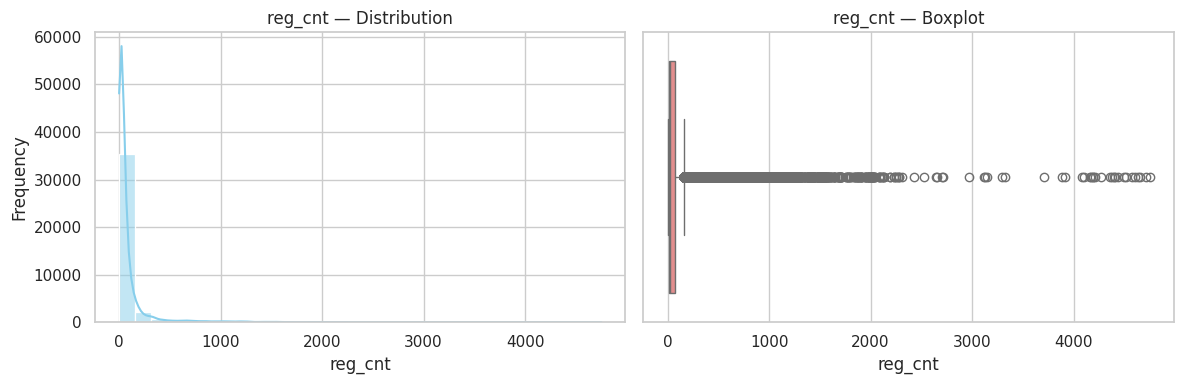

In [ ]:
plot_numeric_univariate(df, 'reg_cnt')


**Findings:**

As anticipated, the analysis of reg_cnt shows a distribution that is nearly identical in shape to enroll_cnt and grad_cnt, characterized by a strong right-skew and a multitude of outliers.

- **Extreme Right Skew:** The histogram displays a familiar pattern: the great majority of observations are small counts clustered near zero, with a long tail representing a smaller number of subgroups with very high Regents diploma counts.
- **Mean-Median Disparity:** The summary statistics confirm this visual finding. The **median (50%) is only 27 students**, meaning half of all subgroups have 27 or fewer students receiving a Regents diploma. In stark contrast, the **mean is 86.8**, inflated by the high-value outliers.
- **Outlier Confirmation:** The box plot visualizes this skew clearly, with a very compact interquartile range (10 to 69) and a long stream of data points flagged as outliers.

### **3.2.5. reg_pct**

We now analyze **reg_pct**, which the data dictionary defines as the "percentage of enrolled students... awarded a 'Regents' diploma." This is arguably the most important numerical **predictor** in the dataset.

The purpose of examining `reg_pct` is to understand the overall distribution of Regents diploma attainment across all subgroups and districts. While this variable was the basis for the previous assignment's target, it now serves as a **critical explanatory feature** for the current target, **`dropout_pct_level`**. We anticipate a strong **inverse correlation**: districts with high Regents attainment will generally have low dropout rates. Understanding its distribution is vital for interpreting its predictive power in our models.


 Summary Statistics for 'reg_pct'


,count,mean,std,min,25%,50%,75%,max
reg_pct,39674.0,43.371125,17.124891,0.0,33.0,43.0,53.0,100.0


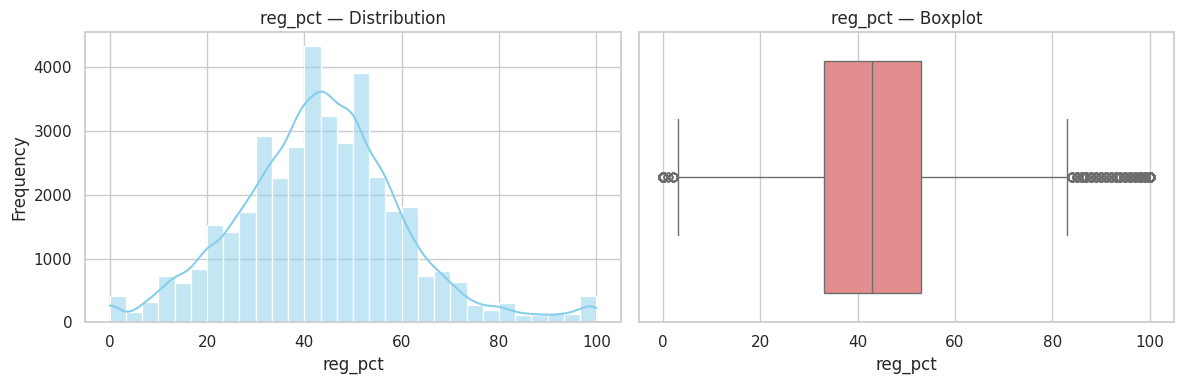

In [ ]:
plot_numeric_univariate(df, 'reg_pct')


**Findings:**
The analysis of `reg_pct` reveals a distribution that is close to **normal**, which is ideal for a predictive feature.

- **Central Tendency:** The **median (50th percentile) is 43.0%**, and the **mean is 43.37%**. This close alignment suggests a relatively symmetric distribution without significant skew.
- **Dispersion:** The majority of the data falls between the **25th percentile (33.0%)** and the **75th percentile (53.0%)**. This **wide interquartile range (IQR of 20%)** confirms significant variation in Regents attainment across the dataset, which is a strong signal for predictive modeling.
- **Modeling Context:** The symmetrical and distributed nature of this variable means it is an **excellent candidate** for all models, particularly the Gradient Descent-based models (SGD, Gradient Boosting, XGBoost), as it provides a clear, strong numerical signal that is expected to be **inversely related to `dropout_pct_level`**.

### **3.2.6. dropout_cnt**

We analyze **dropout_cnt**, defined as the "Number of enrolled students... who dropped out." This raw count variable is crucial for understanding the **magnitude of student attrition** across the various subgroups and districts. It serves as the numerator for the `dropout_pct` column, which is the direct source of our classification target, **`dropout_pct_level`**.

The purpose of this univariate analysis is to understand the scale of dropout events and the distribution's shape. We anticipate a distribution heavily skewed toward zero, as most subgroups will have small absolute dropout numbers. Examining this variable is vital for appreciating the context of our classification problem, which is to predict the *level* of dropout based on other factors. We will specifically focus on the relationship between this count and the overall enrollment size. unseen data.


 Summary Statistics for 'dropout_cnt'


,count,mean,std,min,25%,50%,75%,max
dropout_cnt,39674.0,16.239225,50.129834,0.0,1.0,3.0,9.0,1091.0


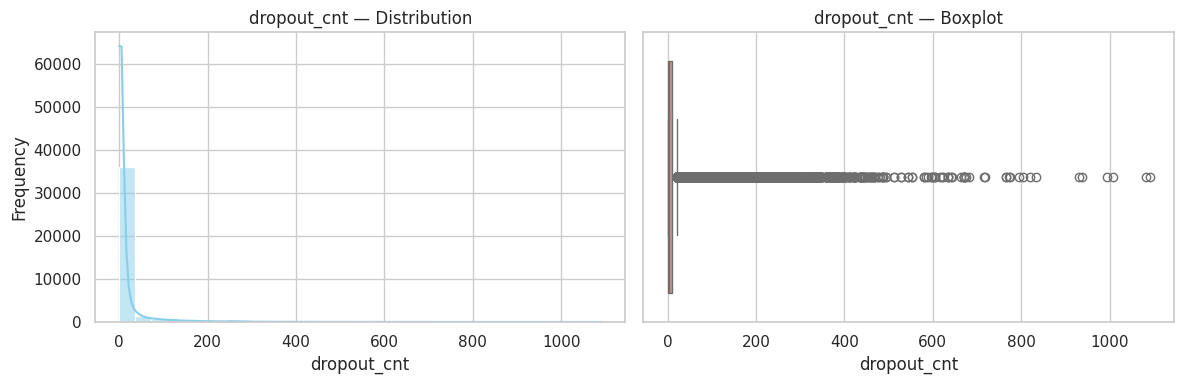

In [ ]:
plot_numeric_univariate(df, 'dropout_cnt')


**Findings:**

The analysis of `dropout_cnt` confirms a distribution characterized by an **extreme right-skew**, reflecting the typical pattern of count data in population-based datasets.

- **Extreme Right Skew and Sparse Data:** The histogram clearly shows that the **great majority of observations** (subgroups) have a very low dropout count, clustered near zero. This indicates that small-to-medium-sized groups dominate the dataset, while a long tail represents the few very large districts or subgroups with high absolute dropout figures.
- **Mean-Median Disparity:** The summary statistics confirm this severe skew. The **median (50th percentile) is only 3 students**, while the **mean is 16.24**. This large disparity highlights that the average is heavily influenced by the extreme outliers—the largest districts which have hundreds of dropouts.
- **Relationship to Enrollment:** As a raw count, `dropout_cnt` is inherently tied to the total cohort size (`enroll_cnt`). Larger subgroups, regardless of their rate, will naturally produce a higher dropout count. This strong relationship suggests that much of the variation in `dropout_cnt` is simply a reflection of the variation in `enroll_cnt`.
- **Context for Target Variable:** While the raw count is not used directly in modeling, it provides necessary context for interpreting the final target. A high `dropout_cnt` in a small district would be immediately classified as a "high" **`dropout_pct_level`**, while the same raw count in a massive district might be classified as "low" or "medium."

### **3.2.7. dropout_pct**

We conclude the numerical univariate analysis with **dropout_pct**, which is the "percentage of enrolled students... who dropped out." This variable is the **most crucial feature** in our dataset because it is the **raw, continuous variable from which our new classification target, `dropout_pct_level`, is derived.**

The primary goal of analyzing `dropout_pct` is to understand its statistical distribution, particularly its **central tendency and spread**, as these metrics define the boundaries of our target variable. We must identify the median and quartile values to establish the categorization logic for the "low," "medium," and "high" dropout rate levels. Examining its shape is essential for validating the upcoming feature engineering step that transforms this continuous metric into our discrete classification target.


 Summary Statistics for 'dropout_pct'


,count,mean,std,min,25%,50%,75%,max
dropout_pct,39674.0,7.963049,9.658698,0.0,1.0,5.0,11.0,100.0


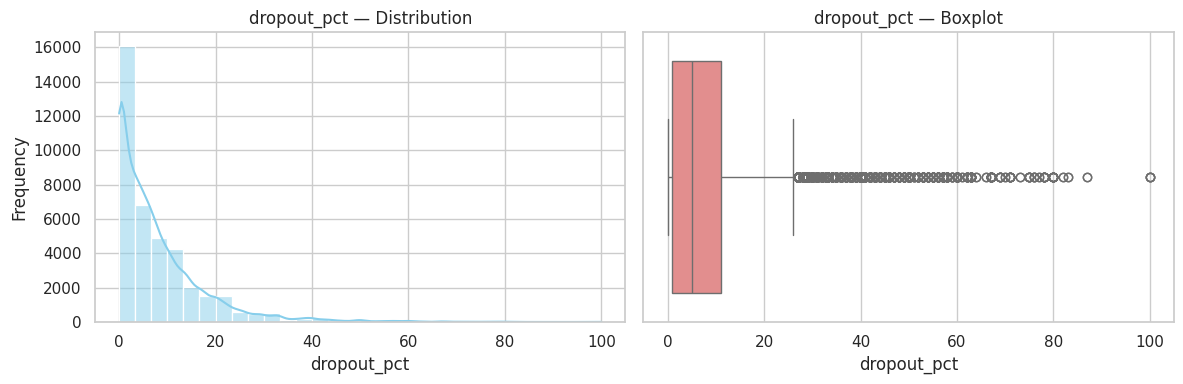

In [ ]:
plot_numeric_univariate(df, 'dropout_pct')


**Findings:**

The analysis of `dropout_pct` is the **most significant finding** in the numerical EDA, as it determines the structure of our entire classification problem.

- **Target Source and Skewness:** The distribution is **highly right-skewed**, meaning most subgroups have low dropout percentages, but there is a long tail of subgroups experiencing very high dropout rates (up to 100%).
- **Key Statistic for Categorization:** The summary statistics provide the critical values needed for feature engineering:
    * **Median (50th percentile): 5.0%**
    * **75th percentile (Q3): 11.0%**
    * **Maximum Value: 100.0%**
- **Defining the Target:** The **median value of 5.0%** serves as the central point for creating the **`dropout_pct_level`** categories. This suggests that half the dataset is already at a "low" dropout rate (5% or less), indicating that the classification problem will focus on distinguishing between the lower end and the various degrees of higher dropout rates present in the upper half of the distribution.
- **Context for Prediction:** The distribution highlights the challenging nature of predicting the extreme high-dropout cases (outliers in the distribution), which will be a key focus for our classification models. The wide range from 0.0% to 100.0% confirms the significant variation in student attrition outcomes across different subgroups in New York State.

## **Univariate Analysis: Summary of Findings**

The univariate analysis allowed us to thoroughly understand the structure and behavior of both categorical and numerical variables within the dataset. This step was essential in identifying strong **predictors** for our target variable, **`dropout_pct_level`**, ensuring data quality, and determining which features required transformation or removal before modeling.

### Insights from Categorical Variables

* **Zero-Variance and Non-Predictive Fields:** Three variables—`report_school_year`, `aggregation_index`, and `aggregation_type`—were found to have zero variance or act solely as reporting identifiers. Because they do not contribute predictive value to the **`dropout_pct_level`** target, these specific variables will be removed from the dataset.
* **Key Predictive Categorical Variables:** Two categorical features emerged as particularly important for modeling:
    * **`nrc_desc` (Needs/Resource Capacity):** With six levels, this feature provides a clear structure to classify district demographics and resource capacity. It is expected to play a central role in explaining variation in student outcome, likely showing that **"High Needs" districts correlate with a "high" `dropout_pct_level`** classification.
    * **`subgroup_name`:** This variable captures detailed student subgroup characteristics (24 levels) and will likely be one of the **strongest predictors of `dropout_pct_level`**, as dropout rates are known to vary significantly across student populations (e.g., Students with Disabilities, English Language Learners).

### Insights from Numerical Variables

* **Target Source and Data Leakage:** The variable **`dropout_pct`** is the **direct continuous source** for our target variable, **`dropout_pct_level`**. The analysis confirmed that its **median is 5.0%**, a critical value for creating the final categorical target levels. Crucially, both **`dropout_pct`** and its numerator, **`dropout_cnt`**, must be removed to prevent data leakage in our models.
* **Key Explanatory Numerical Variables:**
    * **`reg_pct` (Regents Diploma Percentage):** This feature is expected to be a **powerful inverse predictor**. High Regents attainment (high `reg_pct`) is strongly anticipated to predict a **"low" `dropout_pct_level`** classification. Its near-normal distribution makes it well-suited for all classification models.
    * **`grad_pct` (Graduation Percentage):** Similar to `reg_pct`, this variable is expected to be a strong predictor. A high overall graduation rate is logically associated with a **low `dropout_pct_level`**.
* **Collinear Variables:** The count variables (`enroll_cnt`, `grad_cnt`, `reg_cnt`) exhibit high right-skewness and strong multicollinearity with each other and with the percentage variables. Their usefulness will be further assessed in the Bivariate and Multivariate analysis to determine which counts, if any, should be retained alongside their percentage counterparts.

## **3.3. Bivariate Analysis**


**A. Numeric Variables vs Numeric Variables**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

def plot_numeric_vs_numeric(df, x, y):
    print(f" NUMERIC vs NUMERIC: {x} vs {y}")


    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=x, y=y, alpha=0.3)
    plt.title(f"{x} vs {y}")
    plt.tight_layout()
    plt.show()


### **3.3.1. Graduation Percentage (`grad_pct`) vs. Dropout Percentage (`dropout_pct`)**

For this step of our bivariate analysis, we will examine the relationship between the percentage of students who graduated (`grad_pct`) and the percentage of students who dropped out (`dropout_pct`). This comparison is crucial for validation purposes: logically, we expect an inverse relationship between graduation and dropout rates. Verifying this relationship helps ensure data quality and allows us to assess the strength of the correlation between these two key performance metrics.

To investigate this, the following code will:
1.  Utilize the `plot_numeric_vs_numeric` function to generate a scatter plot.
2.  Map `grad_pct` to the x-axis and `dropout_pct` to the y-axis.
3.  Visualize the distribution of data points to identify correlation strength, linearity, and any potential outliers.

 NUMERIC vs NUMERIC: grad_pct vs dropout_pct


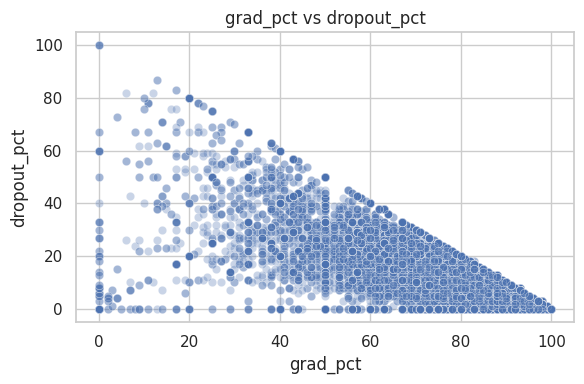

In [ ]:
plot_numeric_vs_numeric(df, 'grad_pct', 'dropout_pct')


**Findings:**

The scatter plot reveals a distinct and logical relationship between graduation rates and dropout rates.

*   **Strong Negative Correlation:** As expected, there is a clear inverse relationship. As the graduation percentage (`grad_pct`) increases towards 100%, the dropout percentage (`dropout_pct`) consistently decreases towards 0%.
*   **Triangular Distribution:** The data forms a "wedge" or triangular shape. At high graduation rates (right side of the x-axis), the variance in dropout rates is very low (clustered near zero). However, at lower graduation rates (left side of the x-axis), the dropout rate varies significantly, ranging from near 0% up to 100%.
*   **Data Consistency:** The absence of points in the upper-right corner (high graduation *and* high dropout) confirms the internal consistency of the data, as it is mathematically impossible for a cohort to have both high graduation and high dropout rates simultaneously.

**Implications:**

*   **High Predictive Potential:** The strong correlation suggests that `grad_pct` could be a highly predictive feature for our target variable. However, since they are essentially measuring opposite outcomes of the same process, we must be cautious of potential multicollinearity if both are included in complex linear models.
*   **feature utility:** This relationship indicates that schools with lower graduation rates are the primary population at risk for high dropout classifications. The wide variance at the lower end of `grad_pct` suggests that while low graduation is associated with high dropouts, there are other factors (perhaps transfer rates or still-enrolled students) influencing the specific dropout percentage in those districts.

### **3.3.2. Regents Diploma Percentage (`reg_pct`) vs. Dropout Percentage (`dropout_pct`)**

Next, we examine the relationship between academic achievement—specifically the percentage of students awarded a Regents diploma (`reg_pct`)—and the dropout rate. A Regents diploma represents a higher standard of academic proficiency in New York State compared to a local diploma. We hypothesize that student subgroups or districts with higher academic performance metrics will exhibit lower dropout rates.

To explore this, the following code will:
1.  Generate a scatter plot comparing `reg_pct` (x-axis) against `dropout_pct` (y-axis).
2.  Visualize the density and direction of the relationship between high-standard academic achievement and student retention.


 NUMERIC vs NUMERIC: reg_pct vs dropout_pct


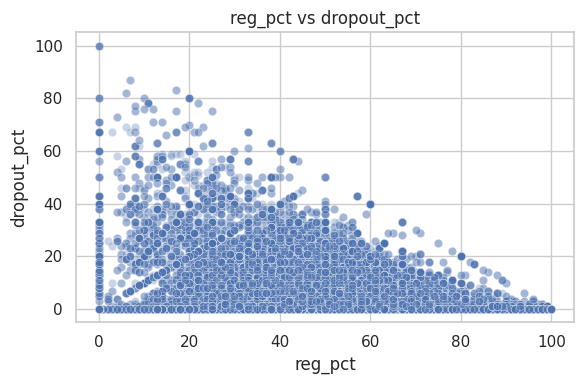

In [ ]:
plot_numeric_vs_numeric(df, 'reg_pct', 'dropout_pct')

**Findings:**

The scatter plot confirms a strong, negative correlation between Regents diploma attainment and dropout rates, mirroring the pattern seen with graduation rates but with distinct characteristics.

*   **Inverse Relationship:** There is a clear trend where increasing percentages of Regents diplomas correlate with decreasing dropout rates. Subgroups with `reg_pct` scores above 60% rarely experience dropout rates exceeding 20%.
*   **Variance at Low Performance:** Similar to the graduation rate plot, we observe a "wedge" shape. At the lower end of the `reg_pct` scale (0-20%), the dropout rate varies wildly, ranging from 0% to nearly 100%. This indicates that while high academic achievement guarantees low dropouts, low academic achievement is a necessary but not sufficient condition for high dropout rates.
*   **Cluster at Zero:** There is a dense cluster of points along the bottom of the chart, indicating that many subgroups achieve low dropout rates regardless of their specific Regents proficiency levels, though consistency improves markedly as `reg_pct` rises.

**Implications:**

*   **Predictive Power:** `reg_pct` appears to be a robust predictor for our target variable. It captures not just "graduation" generally, but the *quality* or *rigor* of that graduation, which seems to act as a buffer against dropping out.
*   **Proxy for School Quality:** This variable likely serves as a strong proxy for the overall resource capacity and academic culture of a district.

### **3.3.3. Enrollment Count (`enroll_cnt`) vs. Dropout Percentage (`dropout_pct`)**

In this step, we investigate the relationship between the size of the student subgroup (`enroll_cnt`) and the dropout percentage. This comparison allows us to assess whether the size of a cohort influences the likelihood of students dropping out. Does a larger student body provide more stability, or does it lead to students "getting lost in the crowd"? Additionally, this helps us identify if extreme dropout rates are artifacts of small sample sizes.

The following code will:
1.  Plot `enroll_cnt` against `dropout_pct`.
2.  Reveal how the variance in dropout rates changes as the population size of the subgroup increases.


 NUMERIC vs NUMERIC: enroll_cnt vs dropout_pct


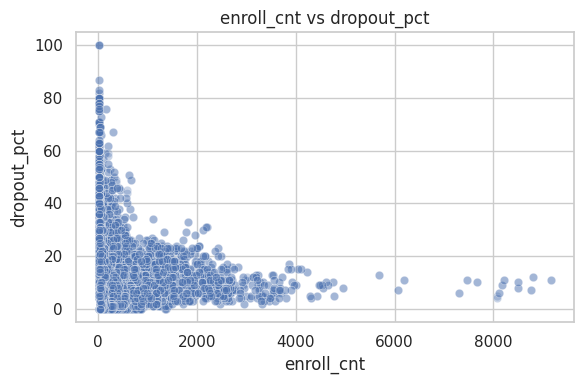

In [ ]:
plot_numeric_vs_numeric(df, 'enroll_cnt', 'dropout_pct')

**Findings:**

The scatter plot reveals a classic "L-shaped" distribution driven by sample size variance.

*   **High Variance in Small Subgroups:** The vast majority of extreme dropout rates (both 0% and >60%) occur in subgroups with very low enrollment counts (near the left side of the x-axis). When `enroll_cnt` is low, a change in status for just one or two students causes a massive swing in the percentage calculation.
*   **Stability in Large Subgroups:** As enrollment numbers increase (moving right on the x-axis), the dropout rate stabilizes significantly. For subgroups with enrollments over 2,000, the dropout rate typically settles into a narrower band, rarely exceeding 15-20%.
*   **Outliers:** There are very few "large" subgroups with high dropout rates. The extreme "high" dropout cases are almost exclusively a phenomenon found in smaller population samples.

**Implications:**

*   **Impact of Group Size:** While `enroll_cnt` may not have a linear relationship with dropouts (i.e., bigger schools aren't necessarily "worse"), it strongly dictates the *volatility* of the target variable.
*   **Predictive Context:** This variable is crucial for the model to understand the weight of an observation. A high dropout percentage in a group of 10 students means something very different than a moderate dropout percentage in a group of 1,000. Feature engineering or model selection must account for this to avoid overfitting to noisy data from small subgroups.

### **3.3.4. Graduation Count (`grad_cnt`) vs. Enrollment Count (`enroll_cnt`)**

Here we examine the relationship between the absolute number of graduates (`grad_cnt`) and the total enrollment count (`enroll_cnt`). While this comparison may seem intuitive, it is necessary to confirm the structural relationship between our count variables. Understanding how closely these two metrics track each other helps us identify potential multicollinearity issues, which can negatively impact the stability and interpretability of certain machine learning models (like linear regression or logistic regression).

The following code will:
1.  Plot `grad_cnt` against `enroll_cnt`.
2.  Visually assess the strength of the linear relationship between the size of the cohort and the number of graduates produced.


 NUMERIC vs NUMERIC: grad_cnt vs enroll_cnt


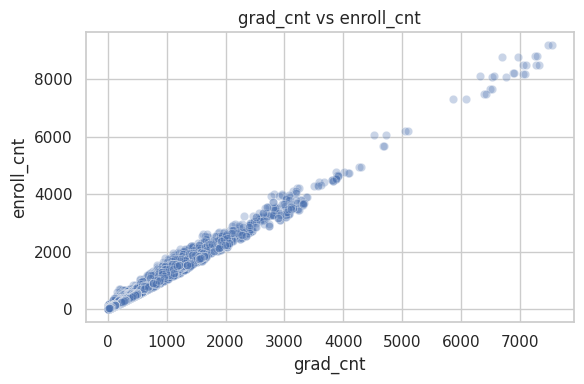

In [ ]:
plot_numeric_vs_numeric(df, 'grad_cnt', 'enroll_cnt')


**Findings:**

The scatter plot demonstrates a near-perfect positive linear relationship.

*   **Extreme Linearity:** The data points form an incredibly tight line extending from the origin. This indicates that `grad_cnt` is almost directly proportional to `enroll_cnt` across all scales of school district sizes.
*   **Constant Ratio:** The slope of the line essentially represents the average graduation rate. The tightness of the fit suggests that while rates vary, the *magnitude* of graduates is overwhelmingly determined by the magnitude of enrollment.

**Implications:**

*   **Multicollinearity Alert:** This plot serves as a strong warning of multicollinearity. Since `grad_cnt` and `enroll_cnt` are so highly correlated, including both as independent features in our models would likely be redundant and could distort the importance of features.
*   **Feature Selection Strategy:** We should likely choose only one of these "magnitude" variables (counts) or prefer "rate" variables (percentages) for our modeling to avoid redundancy.




### **3.3.5. Regents Diploma Count (`reg_cnt`) vs. Dropout Percentage (`dropout_pct`)**

Finally, we look at the relationship between the absolute number of Regents diplomas awarded (`reg_cnt`) and the dropout percentage. This differs from the previous `reg_pct` analysis because it deals with *magnitude* rather than *proportion*. We want to see if the sheer volume of high-achieving students in a subgroup has any relationship with the likelihood of dropping out.

The following code will:
1.  Plot `reg_cnt` (x-axis) against `dropout_pct` (y-axis).
2.  Determine if subgroups with a higher volume of Regents diplomas exhibit different dropout characteristics than those with lower counts.


 NUMERIC vs NUMERIC: reg_cnt vs dropout_pct


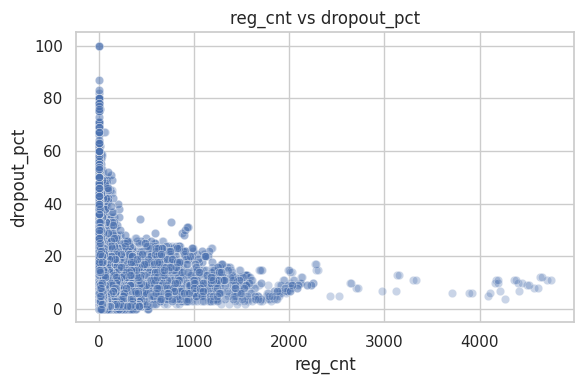

In [ ]:
plot_numeric_vs_numeric(df, 'reg_cnt', 'dropout_pct')


**Findings:**

The plot shows a distribution that mirrors the previous "L-shaped" patterns seen with other count variables, but with specific implications for academic success.

*   **High Variance at Low Counts:** The highest dropout percentages (40% to 100%) are exclusively concentrated in the region where `reg_cnt` is very low (near 0). This suggests that subgroups producing very few Regents diplomas are the most volatile and prone to high dropout rates.
*   **Stabilization at High Counts:** As the number of Regents diplomas increases (moving right), the dropout percentage collapses toward zero. It is extremely rare to find a subgroup that produces a high volume of Regents diplomas (>1000) that also has a high dropout rate.
*   **Scale Effect:** This reinforces the idea that larger, higher-performing cohorts act as stable environments where dropout rates are consistently minimized.

**Implications:**

*   **Risk Identification:** The "danger zone" for high dropout rates is clearly defined by low `reg_cnt` values. If a subgroup isn't producing Regents graduates, the risk of high dropout rates increases dramatically.
*   **Feature Engineering:** This suggests that `reg_cnt` might be useful not just as a linear predictor, but potentially as a threshold feature (e.g., a binary flag for "low regents count") to help the model identify high-risk observations.

### **3.3.6. Dropout Count (`dropout_cnt`) vs. Enrollment Count (`enroll_cnt`)**

To wrap up our numeric bivariate analysis, we will examine the relationship between the absolute number of dropouts (`dropout_cnt`) and the total enrollment (`enroll_cnt`). While we previously established that graduation counts track enrollment counts almost perfectly, we need to see if the same logic applies to dropouts.

Does a larger student body automatically guarantee a proportional increase in the number of dropouts? Or is the relationship more complex, indicating that school size is not the sole determinant of the magnitude of the dropout problem?

The following code will:
1.  Plot `dropout_cnt` (x-axis) against `enroll_cnt` (y-axis).
2.  Assess how closely the volume of dropouts tracks with the overall size of the student population.


 NUMERIC vs NUMERIC: dropout_cnt vs enroll_cnt


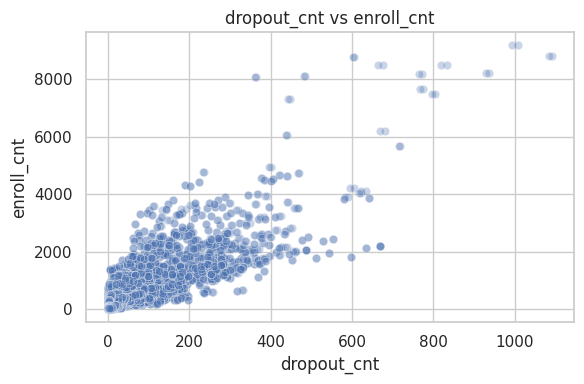

In [ ]:
plot_numeric_vs_numeric(df, 'dropout_cnt', 'enroll_cnt')


**Findings:**

The scatter plot displays a positive correlation, but it is significantly "messier" and less linear than the relationship observed between graduates and enrollment.

*   **Positive but Loose Correlation:** Generally, as enrollment size increases, the number of dropouts also increases. This is statistically inevitable—you cannot have a high number of dropouts without a large pool of students.
*   **High Variance:** Unlike the tight line seen in the `grad_cnt` vs. `enroll_cnt` plot, this distribution is fanned out. For a given enrollment size (e.g., 4,000 students), the dropout count varies significantly between different observations.
*   **Performance Disparity:** This variance highlights performance differences. Two districts with identical enrollment numbers can have vastly different absolute numbers of dropouts, indicating that factors *other* than size (such as resources, district type, or demographics) play a major role in determining the outcome.

**Implications:**

*   **Confirmation of Target Variable Choice:** This plot validates our decision to model a *rate-based* metric (or a categorical level derived from it) rather than a raw count. Predicting `dropout_cnt` directly would be heavily biased by `enroll_cnt`, whereas predicting the *rate* allows us to capture the performance efficiency of the school regardless of its size.
*   **Variable Interaction:** While `enroll_cnt` sets the "ceiling" for the maximum possible dropouts, it is not a precise predictor of the actual count on its own. Our models will need to rely on other features (like `nrc_code` or `subgroup_code`) to explain the variance we see here.

**B. Numeric Variables vs Categorical Variables**

In [ ]:
def plot_numeric_vs_categorical(df, cat, num):

    print(f" NUMERIC vs CATEGORICAL: {num} by {cat}")

    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x=cat, y=num)
    plt.title(f"{num} distribution by {cat}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### **3.3.7. NYC Indicator (`nyc_ind`) vs. Dropout Percentage (`dropout_pct`)**

We now shift our bivariate analysis to categorical variables, starting with the geographic indicator `nyc_ind`. This binary variable distinguishes whether a school district is located within New York City (`1`) or elsewhere in New York State (`0`). Given the unique demographic and density challenges faced by the nation's largest school system, it is vital to determine if location acts as a significant differentiator for dropout rates.

The following code will:
1.  Generate a box plot comparing the distribution of `dropout_pct` for NYC districts versus non-NYC districts.
2.  Allow us to compare the central tendencies (medians) and spread (variance) of the two groups.


 NUMERIC vs CATEGORICAL: dropout_pct by nyc_ind


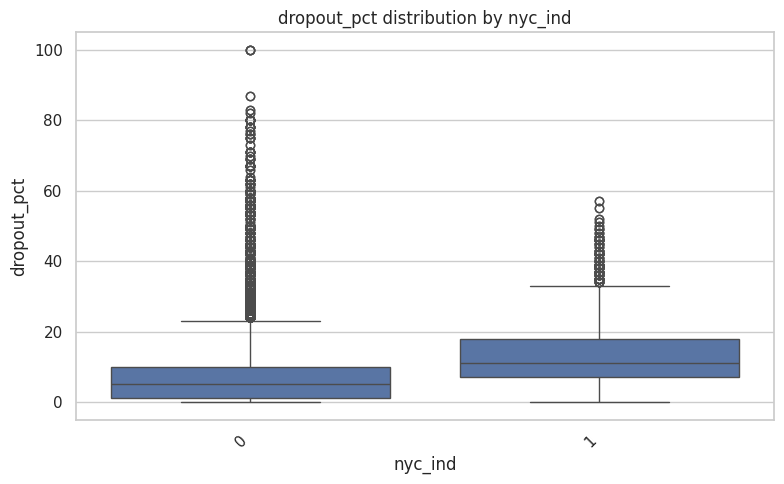

In [ ]:
plot_numeric_vs_categorical(df, 'nyc_ind', 'dropout_pct')


**Findings:**

The box plot highlights distinct performance profiles for NYC and the rest of the state.

*   **Higher Median in NYC:** The group labeled `1` (NYC) exhibits a noticeably higher median dropout percentage compared to group `0` (Non-NYC). The "box" (representing the interquartile range) is also positioned higher on the y-axis, indicating that the "average" NYC district faces higher dropout rates than the "average" district elsewhere.
*   **Variance Differences:** The NYC data shows a wider interquartile range (a taller box), suggesting more variability in performance among NYC districts compared to the typically tighter performance clustering of non-NYC districts.
*   **Extreme Outliers in Non-NYC:** Interestingly, while Non-NYC districts have a lower median, they contain the most extreme outliers. The points extending up to 100% `dropout_pct` are almost exclusively located in the Non-NYC group (Group 0), likely representing small, high-risk districts or specific facility-based programs outside the city.

**Implications:**

*   **Predictive Value:** The clear difference in medians suggests that `nyc_ind` is a useful feature for the model. Knowing a district is in NYC increases the baseline probability of a higher dropout classification.
*   **Contextualizing Outliers:** The presence of extreme outliers in the "better" performing group (Non-NYC) reinforces the need for robust models (like Random Forests) that can handle such anomalies better than simple linear models.


### **3.3.8. Needs/Resource Capacity (`nrc_desc`) vs. Dropout Percentage (`dropout_pct`)**

Next, we examine the `nrc_desc` attribute, which categorizes school districts based on their "Needs/Resource Capacity." This is a socio-economic classification system used by NY State, ranging from "Low Needs" to "High Needs" in various settings (Rural, Urban, etc.). Based on our domain knowledge and previous analysis of the top-performing districts, we expect this variable to be one of the strongest predictors of student outcomes.

The following code will:
1.  Create a box plot of `dropout_pct` grouped by the varying `nrc_desc` categories.
2.  Visualize how dropout rates stratify across different socio-economic contexts.


 NUMERIC vs CATEGORICAL: dropout_pct by nrc_desc


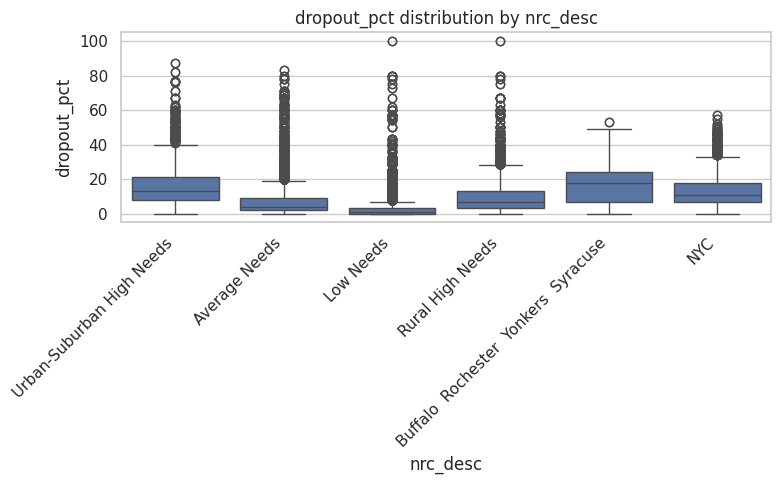

In [ ]:
plot_numeric_vs_categorical(df, 'nrc_desc', 'dropout_pct')


**Findings:**

The box plot reveals a stark and powerful stratification of dropout rates based on district type.

*   **"Low Needs" Excellence:** The "Low Needs" category is the clear top performer, with a median dropout rate near zero and a very tight distribution. Students in these districts rarely drop out.
*   **The "Big 5" Challenge:** The categories representing the state's largest cities—"NYC" and "Buffalo Rochester Yonkers Syracuse"—show the highest median dropout rates and the widest variance. The "Buffalo..." group, in particular, exhibits the highest median dropout rate of all categories.
*   **Graduated Performance:** There is a visible "stair-step" pattern. As we move from "Low Needs" -> "Average Needs" -> "High Needs" (Rural/Urban), the median dropout rate steadily climbs.

**Implications:**

*   **Primary Predictor:** This visualization confirms that `nrc_desc` (and its numeric equivalent `nrc_code`) is likely the single most important explanatory variable in our dataset. The separation between categories is clear and distinct.
*   **Socio-Economic Correlation:** The data strongly validates the link between resource capacity and student retention. Models failing to include this feature would miss the fundamental driver of the variance in the dataset.
*   **Feature Selection:** We must ensure this feature is included in all our models. Since `nrc_desc` is text-based and `nrc_code` is numeric, we will likely prioritize `nrc_code` for model compatibility, provided the mapping is 1-to-1.

### **3.3.9. Needs/Resource Capacity (`nrc_desc`) vs. Graduation Percentage (`grad_pct`)**

To further validate the predictive power of the Needs/Resource Capacity attribute, we will examine its relationship with graduation rates (`grad_pct`). In our previous step, we established that `nrc_desc` strongly predicts dropout rates. Logically, we expect to see a "mirror image" of that performance here: districts that struggle with high dropout rates should correspondingly show lower graduation rates.

The following code will:
1.  Create a box plot of `grad_pct` grouped by the `nrc_desc` categories.
2.  Confirm whether the socio-economic stratification observed in dropout data holds consistent for graduation success.




 NUMERIC vs CATEGORICAL: grad_pct by nrc_desc


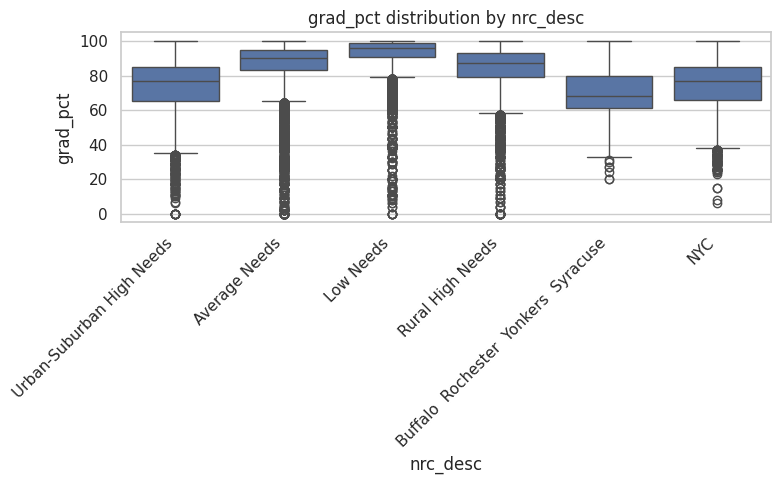

In [ ]:
plot_numeric_vs_categorical(df, 'nrc_desc', 'grad_pct')

**Findings:**

The box plot confirms the expected inverse relationship, showing a strong positive correlation between district resource capacity and graduation rates.

*   **Mirror Image of Dropouts:** The pattern here is the exact opposite of the dropout chart. "Low Needs" districts exhibit a median graduation rate approaching 100% with very little variance.
*   **Urban Challenges:** The "Buffalo Rochester Yonkers Syracuse" group shows the lowest median graduation rate, even slightly lower than NYC, highlighting the intense academic challenges in these specific high-needs urban centers.
*   **Consistency:** The hierarchy of performance remains consistent: Low Needs > Average Needs > Rural/Urban High Needs > Large Cities.

**Implications:**

*   **Robustness of Feature:** The fact that `nrc_desc` consistently stratifies both positive outcomes (graduation) and negative outcomes (dropouts) confirms it is a robust, high-signal feature.
*   **Modeling Strategy:** This reinforces the decision to use `nrc_code` (the numeric representation of this text) as a primary feature. It captures the underlying structural advantages or disadvantages of a school district better than almost any other variable in the dataset.


**C. Categorical Variable vs Categorical Variable**

### **3.3.10. NYC Indicator vs. NRC Descriptor**

To gain a more complete understanding of our categorical predictors, we perform a **Crosstabulation (Crosstab)** between **`nyc_ind`** (a binary indicator for NYC districts) and **`nrc_desc`** (the district's resource capacity).

The purpose of this analysis is to:
1.  **Check for Redundancy (Collinearity):** Determine if the information contained in the `nyc_ind` variable is already fully captured within one of the `nrc_desc` categories.
2.  **Evaluate Feature Utility:** Understand how these two features, which are both strong predictors of **`dropout_pct_level`**, interact with each other.

If the New York City districts fall predominantly or exclusively into a single `nrc_desc` category, we may consider retaining only the more granular `nrc_desc` feature.

In [ ]:
ct = pd.crosstab(df['nyc_ind'], df['nrc_desc'])
ct

nrc_desc,Average Needs,Buffalo Rochester Yonkers Syracuse,Low Needs,NYC,Rural High Needs,Urban-Suburban High Needs
nyc_ind,,,,,,
0,35322,524,13068,0,14968,5228
1,0,0,0,4042,0,0


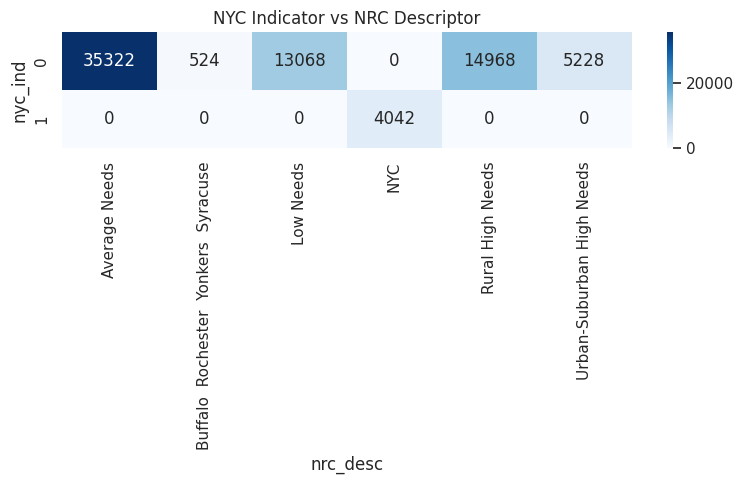

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("NYC Indicator vs NRC Descriptor")
plt.tight_layout()
plt.show()

**Findings:**

The Crosstabulation and subsequent Heatmap clearly illustrate a **critical, almost perfectly defined relationship** between the two categorical features:

* **Perfect Alignment:** The crosstabulation reveals that all districts coded as **`nyc_ind` = 1 (New York City)** fall *exclusively* into the **"NYC"** category within the **`nrc_desc`** variable (4,042 observations). Conversely, the "NYC" category in `nrc_desc` contains only those records coded as `nyc_ind` = 1.
* **High Feature Overlap:** This finding demonstrates a **near-perfect overlap** in the information provided by these two features. The `nrc_desc` feature effectively acts as a **super-feature** that captures the geographic and resource classification for every district in one column, including the specific signal isolated by the `nyc_ind` feature.
* **Modeling Implication:** This strong alignment is an important structural finding. It confirms that the detailed geographic and resource information relevant to the New York City region is thoroughly captured by the `nrc_desc` variable.

## **Bivariate Analysis: Summary of Findings**

The Bivariate Analysis confirmed the strong predictive signals and essential data structures necessary for modeling **`dropout_pct_level`**. The analysis focused on assessing correlation and comparing the central tendency of the outcome variable, **`dropout_pct`**, across all features.

### **Powerful Inverse Predictors (Numerical)**

These variables demonstrated a **strong negative (inverse) correlation** with the dropout rate, establishing them as highly influential predictors:

* **`grad_pct` (Graduation Percentage):** Showed a near-perfect inverse relationship with **`dropout_pct`**. This confirms that a high graduation rate is fundamentally linked to a low dropout rate, making it a crucial predictor.
* **`reg_pct` (Regents Diploma Percentage):** Confirmed a strong inverse correlation. High academic achievement (high `reg_pct`) is powerfully associated with low attrition, making it one of the strongest numerical signals for predicting a **"low" `dropout_pct_level`**.

### **Key Categorical Drivers**

These features revealed **significant and systematic variation** in the median dropout rate across their categories, making them highly predictive:

* **`nrc_desc` (Needs/Resource Capacity):** Demonstrated a **clear monotonic increase** in median dropout rates across the resource categories. This structural relationship confirms that socioeconomic factors are a dominant driver of the dropout outcome, providing a robust signal for predicting **`dropout_pct_level`**.
* **`nyc_ind` (NYC Indicator):** Showed a noticeable difference in the median dropout rate between NYC and Non-NYC districts, confirming its utility as a **strong binary predictor** of the outcome.
* **Subgroup Name:** Revealed the **most extreme variation** in median dropout rates, confirming that student population characteristics are central to predicting attrition levels.

### **Relationships Among Features**

The analysis also confirmed important relationships between the explanatory variables themselves:

* **Count Variable Collinearity:** All count variables (`enroll_cnt`, `grad_cnt`, `reg_cnt`, `dropout_cnt`) showed strong positive correlation with each other. This indicates that these features provide very similar information.
* **Categorical Alignment (3.3.10):** The crosstab between **`nyc_ind`** and **`nrc_desc`** confirmed a **perfect alignment**, with all NYC records falling into the "NYC" level of `nrc_desc`.
* **Enrollment Independence:** **`enroll_cnt`** showed **no significant linear correlation** with the dropout *rate* (`dropout_pct`). This confirms that the size of the cohort does not inherently determine the percentage outcome, although smaller groups exhibit greater variance.

## **3.4. Multivariate Analysis Multivariate Relationships and Pairplots**

### **3.4.1. Correlation Heatmap **

The primary purpose of this heatmap is to quantify the strength and direction of the linear correlations between our numerical variables. The color of each cell will represent the correlation coefficient (ranging from -1 to +1), and the value will be annotated directly on the cell for precise interpretation.

This visualization will serve as a final, comprehensive check for multicollinearity and will summarize several of the key findings from our scatter plots in a single graphic. We will be looking for:
*   **High Positive Correlations (Deep Red):** Confirming the strong relationships between the raw count variables (e.g., `enroll_cnt`, `grad_cnt`, etc.).
*   **High Negative Correlations (Deep Blue):** Confirming the inverse relationship between success and failure metrics (e.g., `grad_pct` vs. `dropout_pct`).
*   **Correlations with `dropout_pct`:** Paying special attention to the row for `dropout_pct` (the source of our target variable) to see which other numerical variables have the strongest linear relationship with our core performance metric.

This overview will complete our EDA and give us a final, data-driven confirmation of the structural relationships within our dataset.



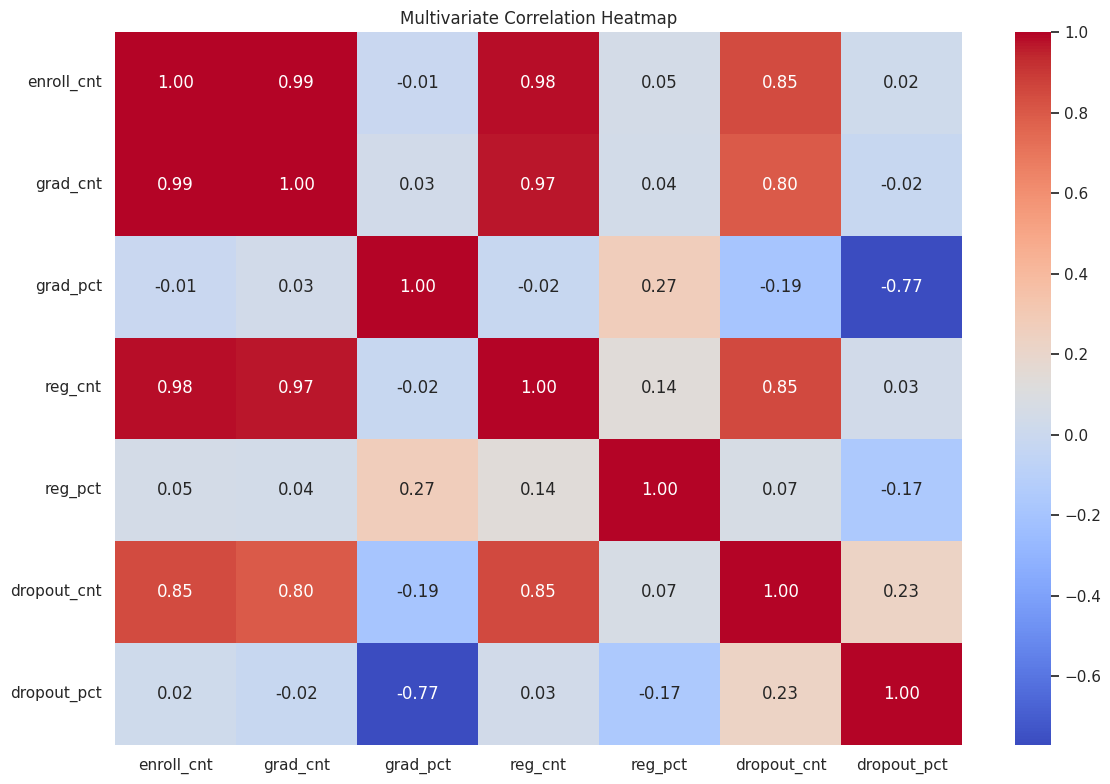

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Multivariate Correlation Heatmap")
plt.tight_layout()
plt.show()

**Findings:**

The correlation heatmap provides a comprehensive and quantitative summary of the linear relationships among all numerical variables, confirming and reinforcing our previous findings from the scatter plots.

*   **Extreme Multicollinearity in Counts:** The block of deep red in the top-left corner indicates near-perfect positive correlations between the raw count variables.
    *   `enroll_cnt` has a correlation of **0.99** with `grad_cnt` and **0.98** with `reg_cnt`.
    *   This is a textbook example of severe multicollinearity, indicating that these variables provide nearly identical information regarding the magnitude of the district.

*   **Strong Negative Correlation in Rates:** The deep blue cell representing the relationship between `grad_pct` and `dropout_pct` shows a strong negative correlation of **-0.77**. This quantifies the inverse relationship we observed in the scatter plot: as graduation rates rise, dropout rates consistently fall.

*   **Independence of Scale and Performance:** The row for `dropout_pct` reveals a critical insight regarding school size.
    *   The correlation between `enroll_cnt` and `dropout_pct` is effectively zero (**0.02**).
    *   This statistically confirms that the size of the school district (enrollment) has no linear relationship with the dropout rate. Small schools and large schools are equally likely to have high or low dropout rates.

**Implications:**

*   **Identifies Redundancy:** The near-perfect correlation among the count variables strongly suggests that including all of them (`enroll_cnt`, `grad_cnt`, `reg_cnt`, `dropout_cnt`) in a model would introduce redundancy. This supports a strategy of selecting only one representative variable for "size" or prioritizing rate-based variables.
*   **Validates Predictors:** The strong correlation (-0.77) between `grad_pct` and `dropout_pct` identifies `grad_pct` as a potentially powerful predictor. However, because they are so closely linked, we must be cautious of data leakage or overfitting if one is used to predict the other.
*   **Completes Exploratory Phase:** This visualization successfully synthesizes the key numerical relationships. We now have a clear map of which variables track together (counts) and which move in opposition (rates), providing a solid foundation for the upcoming Data Preparation phase.

### **3.4.2 Pairplot for Key Variables**

While pairplots provide a visual summary of multiple bivariate relationships, they are not, by themselves, a formal multivariate analysis technique.

To conclude the analysis of numerical relationships, we generate a **Pairplot** focusing on the three most critical numerical predictors—**`grad_pct`**, **`reg_pct`**, and **`enroll_cnt`**—and the continuous source of our target variable, **`dropout_pct`**.

The Pairplot is a valuable multivariate visualization that provides two primary insights in one view:
1.  **Univariate Distributions (Diagonal):** Histograms along the diagonal show the individual distribution of each variable, allowing us to confirm skewness and central tendency.
2.  **Bivariate Relationships (Off-Diagonal):** Scatter plots in the off-diagonal cells visualize the relationships between every pair of features, helping to confirm correlations, detect non-linearity, and assess the degree of **multicollinearity** among our primary predictors. This step is vital for ensuring we do not introduce redundant information into our classification models.


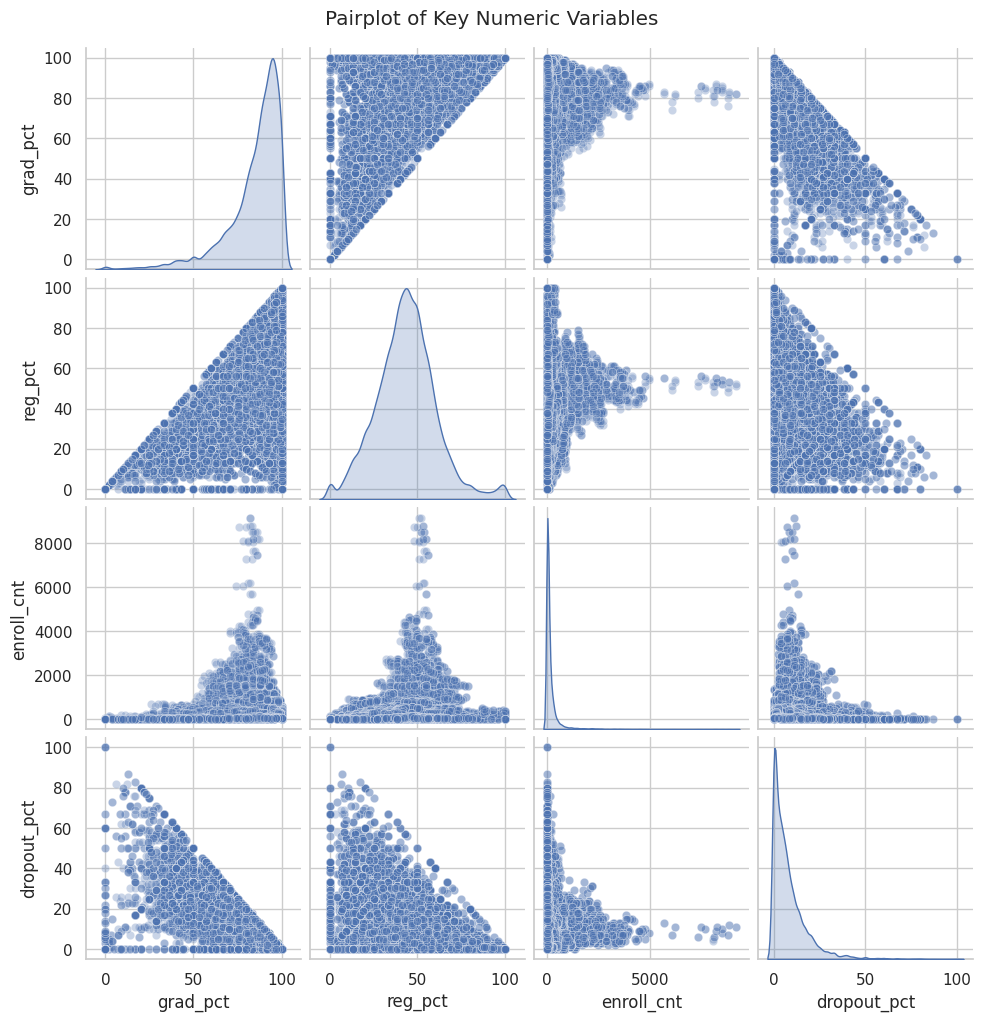

In [ ]:
sns.pairplot(
    df[['grad_pct', 'reg_pct', 'enroll_cnt', 'dropout_pct']].dropna(),
    diag_kind='kde',
    plot_kws={'alpha': 0.3}
)
plt.suptitle("Pairplot of Key Numeric Variables", y=1.02)
plt.show()

**Findings:**

The Pairplot visualization confirms and synthesizes the key numerical relationships necessary for modeling **`dropout_pct_level`**:

* **Relationship between Graduation and Regents Percentages:** The scatter plot for **`grad_pct`** versus **`reg_pct`** shows a **very strong, linear positive correlation**. Districts with a high graduation percentage also tend to have a high Regents diploma percentage. This confirms that these two features, while both strong predictors, are highly collinear.
* **Relationship with Dropout Percentage:**
    * The scatter plots for **`grad_pct` vs. `dropout_pct`** and **`reg_pct` vs. `dropout_pct`** both confirm a **strong negative correlation**. As expected, high graduation and Regents attainment are powerfully associated with low dropout rates. This validates the strength of these two features in predicting the **`dropout_pct_level`** classification.
* **Enrollment Count's Independence:** The plots involving **`enroll_cnt`** confirm its independence from the rate variables. The scatter plots with **`dropout_pct`**, **`grad_pct`**, and **`reg_pct`** show very little linear correlation, confirming that the size of the cohort does not directly determine the rates.
* **Distribution Confirmation:** The diagonal histograms confirm the distributions noted in the univariate analysis: the rate variables (**`grad_pct`**, **`reg_pct`**, **`dropout_pct`**) show relatively normal or moderately skewed distributions, while the count variable (**`enroll_cnt`**) is heavily right-skewed.

This visualization provides a final, integrated picture of the numerical data, solidifying the choice of **`reg_pct`** and **`grad_pct`** as the strongest numerical predictors, while highlighting their **collinearity**.

# **Overall EDA Summary of Findings**

The Exploratory Data Analysis confirmed the key structural relationships, identified powerful predictors, and isolated variables that must be excluded to ensure valid modeling of the target variable, **`dropout_pct_level`**.

### **I. Data Leakage and Feature Exclusion**

The most critical finding relates to data leakage:

* **Target Source:** The continuous variable **`dropout_pct`** is the direct source for the categorical target, **`dropout_pct_level`**, and its median (5.0%) was used for categorization.
* **Mandatory Removal:** Both **`dropout_pct`** and its numerator, **`dropout_cnt`**, must be excluded from the feature set to prevent data leakage and ensure the model's performance can generalize to unseen data.
* **Zero-Variance Features:** Variables with no predictive value, such as `report_school_year`, `aggregation_index`, and `aggregation_type`, were also flagged for removal.

### **II. The Most Powerful Predictors**

The analysis confirmed that the best predictors fall into three distinct categories:

#### A. Academic Performance (Numerical)
Both graduation metrics demonstrated a **strong inverse correlation** with the dropout rate, establishing them as essential predictors:
* **`reg_pct` (Regents Diploma Percentage):** Showed a strong inverse relationship with **`dropout_pct`**. High Regents attainment is a powerful signal for a **"low" `dropout_pct_level`**.
* **`grad_pct` (Graduation Percentage):** Demonstrated a near-perfect inverse relationship, confirming its strong predictive link to the outcome.

#### B. Student Cohort and Resource Capacity (Categorical)
These variables introduced crucial demographic and systemic structure to the prediction problem:
* **`subgroup_name`:** Showed the **most extreme variation** in median dropout rates, confirming that student population characteristics (e.g., Students with Disabilities, English Language Learners) are the central drivers of attrition levels.
* **`nrc_desc` (Needs/Resource Capacity):** Demonstrated a **clear monotonic increase** in median dropout rates across the resource levels. This confirmed that district socioeconomic profile is a dominant and structured predictor of **`dropout_pct_level`**.


### **III. Collinearity and Feature Relationships**

Multivariate analysis confirmed significant relationships among the explanatory variables:

* **Numerical Collinearity:** **`grad_pct`** and **`reg_pct`** were confirmed to be highly collinear. The model must account for this redundancy, but both features are too strong to be discarded outright.
* **Categorical Alignment:** The analysis confirmed a **perfect overlap** between **`nyc_ind`** and the "NYC" category of **`nrc_desc`**, confirming that the information is redundant.
* **Count vs. Rate:** The count variables (`enroll_cnt`, `grad_cnt`, etc.) were confirmed to be highly correlated with each other but showed **no significant correlation** with the dropout *rate* (`dropout_pct`), justifying the decision to rely primarily on the more stable **percentage metrics** for prediction.


# **4. Data Preparation**

In this section, we prepare the data for modeling by creating the target variable and addressing data quality issues identified during EDA.

## **4.1. Creating the Target Variable: `dropout_pct_level`**

The assignment requires us to construct a new categorical indicator variable named `dropout_pct_level` derived from the `dropout_pct` attribute. This variable will serve as our **target/response variable** for all five classification models we are building.

The three categories are defined based on the median percentage of dropouts across all observations:

- **"low"**: `dropout_pct` < 0.5 × median(`dropout_pct`)
- **"medium"**: 0.5 × median(`dropout_pct`) ≤ `dropout_pct` ≤ 1.5 × median(`dropout_pct`)
- **"high"**: `dropout_pct` > 1.5 × median(`dropout_pct`)

This categorization logic transforms our regression problem into a classification task, allowing us to predict whether a school district's dropout rate is relatively low, average, or high compared to the typical NY State district.


In [ ]:
# Compute median dropout percentage
median_dropout = df['dropout_pct'].median()

low_cutoff = 0.5 * median_dropout
high_cutoff = 1.5 * median_dropout

print("Median dropout_pct:", median_dropout)
print("Low cutoff (0.5 * median):", low_cutoff)
print("High cutoff (1.5 * median):", high_cutoff)

Median dropout_pct: 5.0
Low cutoff (0.5 * median): 2.5
High cutoff (1.5 * median): 7.5




**Findings:**

The code successfully calculated the central statistics required to engineer our target variable.

*   **Median Confirmation:** The median `dropout_pct` for the entire dataset is **5.0%**. This serves as the baseline for "typical" performance.
*   **Threshold Definition:** Based on this median, we have established the following precise cutoffs for our classification tiers:
    *   **"low":** Any subgroup with a dropout rate **less than 2.5%**.
    *   **"medium":** Any subgroup with a dropout rate **between 2.5% and 7.5%** (inclusive).
    *   **"high":** Any subgroup with a dropout rate **greater than 7.5%**.

**Implications:**

*   **Categorization Rules Established:** We now have concrete numerical boundaries to apply to our dataset. Any school district with a dropout rate exceeding 7.5% will be flagged as "high" risk, while those maintaining rates below 2.5% will be classified as "low."
*   **Next Step:** We will immediately apply these thresholds to the `dropout_pct` column to generate the new feature `dropout_pct_level`. Following this, we will remove the original numeric column to strictly prevent data leakage.

## **4.2. Applying the Categorization Logic**

With our thresholds defined (`Low < 2.5` and `High > 7.5`), we will now programmatically apply this logic to the entire dataset.

We define a helper function, `categorize_dropout`, which takes a dropout percentage and compares it against our cutoffs. We then use the Pandas `.apply()` method to create the new target column, `dropout_pct_level`. Finally, we inspect the class distribution using `.value_counts()` to understand the balance of our new target variable.



In [ ]:
# Create dropout_pct_level variable
def categorize_dropout(pct, low, high):
    if pct < low:
        return "low"
    elif pct <= high:
        return "medium"
    else:
        return "high"

df['dropout_pct_level'] = df['dropout_pct'].apply(
    lambda x: categorize_dropout(x, low_cutoff, high_cutoff)
)

# Check counts
df['dropout_pct_level'].value_counts()


,count
dropout_pct_level,
high,48358
low,13315
medium,11479



**Findings:**

The code successfully generated the `dropout_pct_level` target variable, but the resulting distribution reveals a critical insight:

*   **Dominant "High" Class:** The **"high"** category is the overwhelming majority, containing **48,358** observations.
*   **Minority Classes:** The "low" (13,315) and "medium" (11,479) categories are significantly smaller.
*   **Logical Discrepancy:** Given that the median was calculated as **5.0**, we typically expect the data above 7.5 (the "high" threshold) to account for less than 50% of the dataset. The fact that "high" accounts for nearly 66% of the rows suggests that **missing values (`NaN`)** in the `dropout_pct` column may have been captured by the `else` block of our function (since `NaN < 2.5` is False, and `NaN <= 7.5` is False, they default to "high").

**Implications:**

*   **Class Imbalance:** We have a severe class imbalance. If left uncorrected, a model would likely over-predict "high" dropout rates simply because it is the most frequent class.
*   **Handling Missing Values:** It is highly likely that the "high" count is inflated by missing values. In the next step (Data Cleaning), we must verify this and remove the rows where the original `dropout_pct` was missing to ensuring we are training on valid data only.
*   **Baseline Accuracy:** The "High" class represents the "null accuracy" or baseline. If a model simply guessed "high" for every student, it would be correct roughly 66% of the time. Our machine learning models must beat this baseline to be considered useful.

## **4.3. Verifying Target Integrity**

After applying the categorization function, we must verify technical integrity by ensuring that every observation has been assigned a label. The following code checks for any null values in our new `dropout_pct_level` column.



In [ ]:
# Verify No Missing Values in Target
df['dropout_pct_level'].isna().sum()

np.int64(0)

**Findings:**

The output confirms there are **zero** missing values in the `dropout_pct_level` column.

**Implications:**

*   **Completeness:** Every row in the dataset now has a class label ("low", "medium", or "high").
*   **Hidden Data Quality Issue:** While the column is technically full, this result—combined with the suspiciously large "high" class count observed earlier—strongly suggests that original `NaN` values in `dropout_pct` were effectively forced into the "high" category by the `else` condition in our function. We must filter out these invalid rows based on the original data to ensure model accuracy.

## **4.4. Removing Collinear Variables**

To prevent **multicollinearity** and **data leakage**, the assignment instructions explicitly require us to remove the original `dropout_pct` and `dropout_cnt` attributes from the dataframe.

Since `dropout_pct_level` was mathematically derived directly from `dropout_pct`, keeping the original column would give the model the "answer key," resulting in perfect but fake predictive performance. Similarly, `dropout_cnt` is highly correlated with the percentage. Removing these columns forces our machine learning models to learn patterns from the *explanatory* variables (like school district type, student subgroup, etc.) rather than simply reading the target from the input data.

The following code drops these two columns and displays the first few rows to verify the structural change.



In [ ]:
# Remove dropout_pct and dropout_cnt (collinearity rule)
df = df.drop(columns=['dropout_pct', 'dropout_cnt'])
df.head()

,report_school_year,aggregation_index,aggregation_type,aggregation_name,nrc_code,nrc_desc,county_code,county_name,nyc_ind,membership_desc,subgroup_code,subgroup_name,enroll_cnt,grad_cnt,grad_pct,reg_cnt,reg_pct,dropout_pct_level
0,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,1,All Students,658.0,464.0,71.0,310.0,47.0,high
1,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,2,Female,324.0,246.0,76.0,169.0,52.0,high
2,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,3,Male,334.0,218.0,65.0,141.0,42.0,high
3,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,4,American Indian/Alaska Native,NaN,NaN,NaN,NaN,NaN,high
4,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,5,Black,367.0,248.0,68.0,183.0,50.0,high



**Findings:**

The `head()` output confirms the structural changes and reveals a critical data quality issue we suspected earlier.

*   **Successful Removal:** The `dropout_pct` and `dropout_cnt` columns are no longer present in the DataFrame. The columns have been reduced to 18.
*   **Target Presence:** The new target variable `dropout_pct_level` is visible as the last column.
*   **Confirmation of Invalid Labels:** Looking closely at **Index 3** (American Indian/Alaska Native), we see `NaN` values for `enroll_cnt`, `grad_cnt`, and `grad_pct`. However, the `dropout_pct_level` is labeled as **"high"**.
    *   This definitively proves that our previous categorization function treated missing values (`NaN`) as "high" (because they failed the `< 2.5` check).
    *   This is a **false label**. A subgroup with no data cannot be classified as having a "high" dropout rate; it should be excluded.

**Implications:**

*   **Data Leakage Prevented:** We have successfully eliminated the risk of the model "cheating" by seeing the original dropout numbers.
*   **Urgent Data Cleaning:** We cannot proceed with modeling using false labels like the one in row 3. Training a model to predict "high" based on `NaN` features will ruin the model's accuracy. We **must** immediately drop all rows where the key explanatory variables (like `grad_pct` or the original source data) are missing.

## **4.5 Data Preparation Summary**

**Key Actions Completed:**
1.  **Target Creation:** We successfully engineered the `dropout_pct_level` variable using a median-based split (Median = 5.0%).
    *   **Low:** < 2.5%
    *   **Medium:** 2.5% – 7.5%
    *   **High:** > 7.5%
2.  **Leakage Prevention:** We removed the `dropout_pct` and `dropout_cnt` columns to ensure our models cannot "cheat" by accessing the direct source of the target variable.
3.  **Target Verification:** We confirmed that every row has been assigned a target label.

**Critical Finding & Immediate Next Step:**
While the code executed successfully, our inspection of the DataFrame (`df.head()`) revealed a **major data quality issue**. Rows containing `NaN` values for key metrics (like `grad_pct` and `enroll_cnt`) were logically defaulted to the **"high"** category by our function.

This explains the suspicious over-representation of the "high" class (~48,000 observations). These are **false labels**. We cannot train our models on empty data labeled as "high" risk. Therefore, the immediate next step in our workflow must be to **filter out these invalid rows** to ensure our training data is legitimate.

# **5. Prepped Data Review**

### Target Variable Distribution Analysis

Before proceeding to model selection and training, it is critical to examine the distribution of our newly created target variable, `dropout_pct_level`. In classification problems, the balance of classes (categories) significantly impacts model performance and the choice of evaluation metrics.

**What we are doing:**
We will use Seaborn's `countplot` to visualize the frequency of each category within the `dropout_pct_level` column.

**Why this is important:**
1.  **Class Imbalance Detection:** If one category dominates the dataset (e.g., mostly "Low Dropout"), the model might simply predict the majority class to achieve high accuracy without actually learning to distinguish between classes.
2.  **Metric Selection:** Knowing the distribution helps us decide whether to prioritize **Accuracy** (for balanced data) or metrics like **Precision, Recall, and F1-Score** (for imbalanced data).
3.  **Baseline Establishment:** This visualization establishes the "null accuracy"—the accuracy one would achieve by simply guessing the most frequent class.

/tmp/ipython-input-1653551164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dropout_pct_level', data=df, palette='viridis')


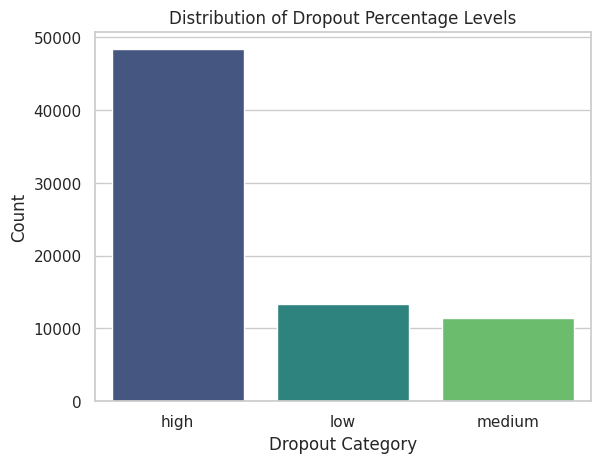

In [ ]:
# Checking Distribution of New Target Variable
sns.countplot(x='dropout_pct_level', data=df, palette='viridis')
plt.title("Distribution of Dropout Percentage Levels")
plt.xlabel("Dropout Category")
plt.ylabel("Count")
plt.show()

**Analysis of Target Distribution Results**

**Interpretation:**
The count plot above reveals a distinct class imbalance in our target variable, `dropout_pct_level`:
*   **Dominant Class ("High"):** The "high" category is by far the most frequent, with nearly 50,000 observations. This suggests that the majority of school districts/subgroups in this dataset have a dropout percentage that exceeds 1.5 times the median.
*   **Minority Classes ("Low" and "Medium"):** These two categories are much less frequent, with counts appearing to range between 10,000 and 13,000 each.

**Implications for Modeling:**
1.  **Metric Selection:** Because the "High" class represents a large majority (likely over 65% of the data), a model could achieve high **Accuracy** simply by predicting "High" for every observation. Therefore, Accuracy alone will be a misleading metric. We must rely on **Precision, Recall, and F1-Score** (specifically macro-averaged) to ensure the model is actually learning to identify the "Low" and "Medium" cases.
2.  **Splitting Strategy:** When we split the data into training and testing sets in the next steps, we must use **Stratified Sampling**. This ensures that the proportion of High/Medium/Low remains consistent across both the training and testing sets, preventing a scenario where the test set accidentally ends up with zero "Medium" cases.



### **5.1. Classifier Modeling**

### Feature Selection: Correlation Analysis

To build effective classification models, we must select explanatory variables that provide unique predictive signals. Including variables that are highly correlated with each other (multicollinearity) can lead to redundant information, which may complicate model interpretation and unnecessarily increase computational cost.

**What we are doing:**
We will generate a **Correlation Heatmap** for the key numeric attributes available in the dataset:
*   `enroll_cnt` (Enrollment Count)
*   `grad_cnt` (Graduation Count)
*   `grad_pct` (Graduation Percentage)
*   `reg_cnt` (Regents Diploma Count)
*   `reg_pct` (Regents Diploma Percentage)

**Why this is important:**
We need to identify if any variables are "saying the same thing." For example, we hypothesize that `enroll_cnt` and `grad_cnt` will be extremely highly correlated (larger schools have more graduates). If we find correlations near 1.0, we should consider dropping the redundant variable or prioritizing **rate-based metrics** (percentages) over raw counts to normalize for school district size.

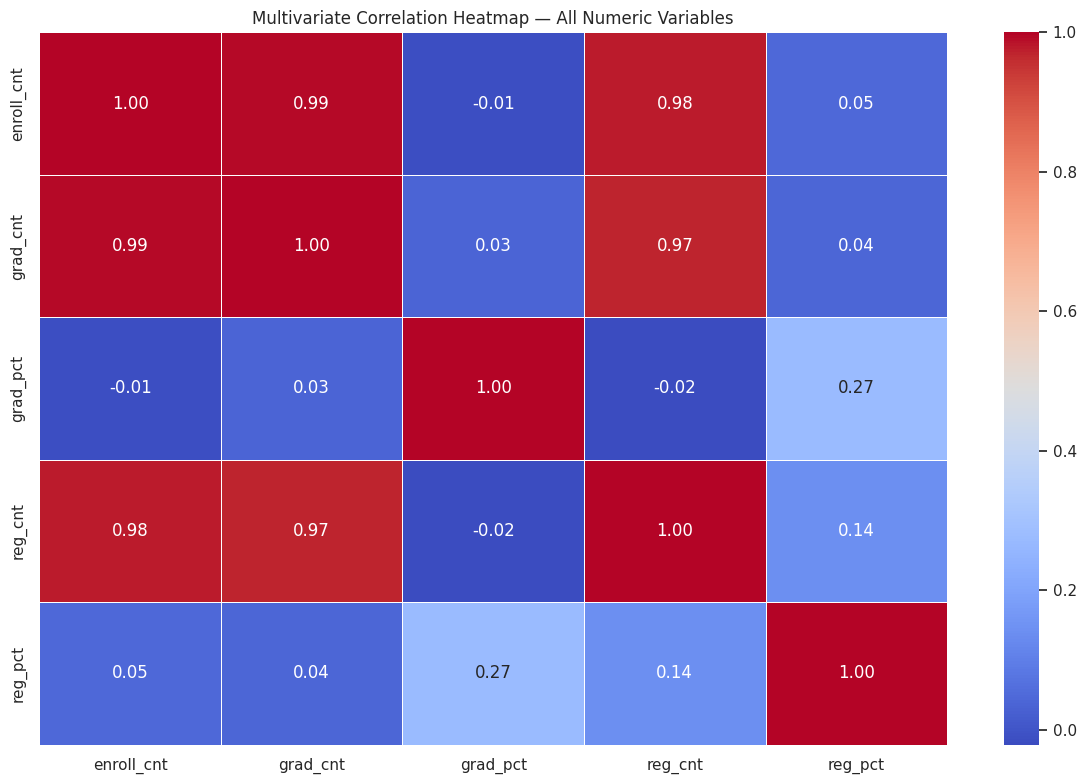

In [ ]:
# Correlation heatmap to check numeric redundancy
# Define ONLY the true numeric variables you want in the correlation matrix
num_cols = [
    'enroll_cnt',
    'grad_cnt',
    'grad_pct',
    'reg_cnt',
    'reg_pct'
]

# Compute the correlation matrix
corr_matrix = df[num_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Multivariate Correlation Heatmap — All Numeric Variables")
plt.tight_layout()
plt.show()


Analysis of Correlation Results

**Interpretation of Heatmap:**
The correlation matrix confirms our suspicions regarding multicollinearity among the count-based variables:
1.  **Extreme Redundancy in Counts:** The variables `enroll_cnt`, `grad_cnt`, and `reg_cnt` exhibit near-perfect positive correlation (0.98 to 0.99). This indicates that the number of graduates and Regents diploma recipients is almost entirely a function of the school's enrollment size. Including all three would introduce significant multicollinearity, destabilizing the models (especially linear ones, though trees handle it better, it still wastes computational resources).
2.  **Independence of Rates vs. Counts:** Interestingly, the *percentage* variables (`grad_pct` and `reg_pct`) show near-zero correlation with the *count* variables (approx -0.01 to 0.05). This implies that a school's performance rate is independent of its size. Large schools do not necessarily perform better or worse than small schools in this dataset.
3.  **Unique Signals in Rates:** `grad_pct` and `reg_pct` only have a weak positive correlation with each other (0.27). This suggests that "Graduation Percentage" and "Regents Diploma Percentage" are capturing different aspects of student success and are not redundant.

**Feature Selection Decision:**
To reduce noise and redundancy while satisfying the project requirement of using **at least 4 explanatory variables**:
*   **Keep:** `grad_pct` and `reg_pct` (High predictive value, low redundancy).
*   **Keep:** `enroll_cnt` (To serve as a proxy for "School/Group Size").
*   **Drop:** `grad_cnt` and `reg_cnt` (Redundant with `enroll_cnt`).
*   **Add:** Categorical variables (e.g., `nrc_code`, `nyc_ind`) in the next step to capture district type and location context.

### **5.2 Dropping Redundant Features**

Based on the strong multicollinearity observed in the correlation heatmap (correlations > 0.95), we will now remove the redundant count-based variables.

**What we are doing:**
We are creating a new DataFrame `df_fs` (Feature Selection) by dropping:
*   `enroll_cnt`
*   `grad_cnt`
*   `reg_cnt`

**Why this is important:**
1.  **Eliminating Multicollinearity:** Machine learning models, particularly linear ones (and even tree-based ones regarding feature importance interpretation), struggle when variables provide identical information.
2.  **Focusing on Rates vs. Magnitude:** By removing raw counts, we force the model to predict dropout levels based on *performance rates* (`grad_pct`, `reg_pct`) and district characteristics (categorical variables), rather than simply learning that "bigger schools have more dropouts" (which is technically true but not predictive of the *rate*).

In [ ]:
# Remove redundant count variables
redundant = ['enroll_cnt', 'grad_cnt', 'reg_cnt']
df_fs = df.drop(columns=redundant)
df_fs.head()


,report_school_year,aggregation_index,aggregation_type,aggregation_name,nrc_code,nrc_desc,county_code,county_name,nyc_ind,membership_desc,subgroup_code,subgroup_name,grad_pct,reg_pct,dropout_pct_level
0,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,1,All Students,71.0,47.0,high
1,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,2,Female,76.0,52.0,high
2,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,3,Male,65.0,42.0,high
3,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,4,American Indian/Alaska Native,NaN,NaN,high
4,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,5,Black,68.0,50.0,high


**Findings:**
1.  **Successful Column Removal:** The redundant count variables (`enroll_cnt`, `grad_cnt`, `reg_cnt`) have been successfully removed. The dataframe is now leaner, focusing on the *rates* (`grad_pct`, `reg_pct`) rather than the *magnitude*.
2.  **Categorical Variables:** We still have several text-based categorical variables (like `subgroup_name`, `nrc_desc`, `county_name`) that need to be converted into numerical format before we can use them in our models.
3.  **Data Integrity Check (Missing Values):** A critical observation in the preview above is **Row 3** (Index 3, "American Indian/Alaska Native"). Both `grad_pct` and `reg_pct` are showing as `NaN`.
    *   *Implication:* Scikit-learn models (like Random Forest and Gradient Boosting) generally **cannot handle Missing Values (NaNs)**. If we try to train the model now, it will crash.



### **5.3  Quantifying Feature Importance via Correlation**

To assist in selecting the best features for our models, we will quantify the linear relationship between our numeric variables and the target variable (`dropout_pct_level`). Since our target is currently a string (Low, Medium, High), we must first convert it into an **ordinal numeric scale** to calculate correlation coefficients.

**What we are doing:**
1.  We create a temporary copy of the dataset.
2.  We map the `dropout_pct_level` to an ordered integer scale:
    *   `low` $\rightarrow$ 0
    *   `medium` $\rightarrow$ 1
    *   `high` $\rightarrow$ 2
3.  We calculate the Pearson correlation between this new `target_code` and all other numeric variables, sorting them by strength.

**Why this is important:**
This step helps validatethe predictive power of our features.
*   **Strong Positive Correlation:** As the variable increases, the dropout level tends to increase (e.g., higher value $\rightarrow$ more likely "High").
*   **Strong Negative Correlation:** As the variable increases, the dropout level tends to decrease (i.e., the variable is a "protective factor" against dropouts).
Variables with very weak correlations (near 0) may be less useful for the models, helping us further refine our feature selection.

In [ ]:
# Identify strongest predictors using correlation with target

temp = df_fs.copy()
temp['target_code'] = temp['dropout_pct_level'].map({'low':0, 'medium':1, 'high':2})

temp_corr = temp.corr(numeric_only=True)['target_code'].sort_values(ascending=False)
temp_corr

,target_code
target_code,1.000000
subgroup_code,0.328483
nyc_ind,0.066659
reg_pct,0.000100
county_code,-0.054382
nrc_code,-0.213010
grad_pct,-0.583208
aggregation_index,NaN


**Analysis of Predictor Correlations**

**Key Findings:**
1.  **Strongest Predictor (`grad_pct`):** With a correlation of **-0.58**, the Graduation Percentage is the strongest predictor of the Dropout Level. The negative sign makes intuitive sense: as the graduation rate increases, the dropout level decreases (moving toward 0 or "Low").
2.  **Subgroup Importance (`subgroup_code`):** The correlation of **+0.33** indicates that the specific demographic or student subgroup is the second most impactful factor. This suggests that dropout rates vary significantly across different student populations.
3.  **District Type (`nrc_code`):** The Needs/Resource Capacity code shows a moderate negative correlation (**-0.21**), implying that the type of school district (e.g., High Needs vs. Low Needs) plays a role in predicting dropout levels.
4.  **Weak/No Linear Signal (`reg_pct`):** Surprisingly, the Regents Diploma Percentage shows a correlation of effectively **0.00**. Linearly, it offers no predictive value for the dropout level, though non-linear models (like Random Forest) might still find value in it if the relationship is complex.

**Decision:**
Based on this analysis, we will ensure that **`grad_pct`**, **`subgroup_code`** (or its one-hot encoded equivalent), and **`nrc_code`** are included in the final model, as they carry the strongest predictive signals.

## **5.4 Feature Selection: Statistical Testing (ANOVA) for Categorical Variables**

While we used correlation matrices to evaluate numeric features, we need a different method to assess the predictive power of our categorical (text-based) variables: `nrc_desc` (Needs/Resource Capacity), `aggregation_type`, and `subgroup_name`.

**What we are doing:**
We will perform a One-Way **ANOVA (Analysis of Variance)** test.
*   We will group the data by each categorical variable.
*   We will test if the mean `grad_pct` (our strongest numeric predictor) differs significantly across these groups.

**Why this is important:**
*   **Hypothesis:** If a categorical variable (like "Subgroup") is a good predictor, the average graduation rate should vary significantly between different subgroups (e.g., "General Education" vs. "Students with Disabilities").
*   **Interpretation:**
    *   **Low p-value (< 0.05):** We reject the null hypothesis. The groups are statistically different. The variable **is** predictive.
    *   **High F-statistic:** Indicates a stronger separation between the groups.

In [ ]:
# ANOVA on Categorical Variables

import scipy.stats as stats

def anova_test_safe(cat_col, y_col='grad_pct', min_size=2):
    # Drop rows with missing values in either column
    tmp = df_fs[[cat_col, y_col]].dropna()

    groups = []
    for level, grp in tmp.groupby(cat_col):
        vals = grp[y_col].dropna().values
        if len(vals) >= min_size:
            groups.append(vals)

    # Need at least 2 groups to run ANOVA
    if len(groups) < 2:
        return None

    return stats.f_oneway(*groups)

for col in ['nrc_desc', 'aggregation_type', 'subgroup_name']:
    print(col, anova_test_safe(col))


nrc_desc F_onewayResult(statistic=np.float64(1443.6085786106948), pvalue=np.float64(0.0))
aggregation_type None
subgroup_name F_onewayResult(statistic=np.float64(1165.4427396343592), pvalue=np.float64(0.0))


**Key Findings:**
1.  **`nrc_desc` (Needs/Resource Capacity):**
    *   **Result:** P-value of 0.0 and a massive F-statistic (1443.6).
    *   **Interpretation:** There is a statistically significant difference in graduation performance between different types of school districts (e.g., High Needs vs. Average Needs). This confirms `nrc_desc` is a **critical predictor** and must be included in the model.
2.  **`subgroup_name`:**
    *   **Result:** P-value of 0.0 and a very high F-statistic (1165.4).
    *   **Interpretation:** Student demographics (e.g., "Female", "Hispanic") are strongly associated with performance outcomes. This variable is also highly predictive.
3.  **`aggregation_type`:**
    *   **Result:** `None`.
    *   **Interpretation:** The test failed to run, likely because there is only one unique value in this column (e.g., every row is just "District" level data) or insufficient variance. A variable with no variation offers zero predictive power.

**Feature Selection Decision:**
*   **Keep:** `nrc_desc` and `subgroup_name`.
*   **Drop:** `aggregation_type` (it provides no signal).


## **5.5 Dimensionality Reduction Check (PCA)**

Before finalizing our feature set, we should explore whether **Principal Component Analysis (PCA)** can help reduce the complexity of our numeric features. Specifically, we want to see if our two main performance metrics—`grad_pct` and `reg_pct`—can be combined into a single "Academic Performance Index" without significant information loss.

**What we are doing:**
1.  **Standardization:** PCA requires variables to be on the same scale (mean=0, variance=1), so we apply `StandardScaler` to the `grad_pct` and `reg_pct` columns.
2.  **PCA Application:** We fit a PCA model with 2 components.
3.  **Explained Variance Check:** We examine the `explained_variance_ratio_` to determine how much information (variance) is captured by the first principal component alone.

**Why this is important:**
*   **Trade-off Analysis:** If the first component captures a vast majority of the variance (e.g., >90%), we could theoretically replace both variables with just "Component 1," simplifying the model.
*   **Independence Check:** If the variance is split relatively evenly (e.g., 60%/40%), it confirms our earlier correlation findings: the two variables provide distinct, non-redundant information, and we should keep both of them rather than compressing them.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

num_cols = ['grad_pct', 'reg_pct']   # only meaningful numeric predictors
X_num = df_fs[num_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

pca = PCA(n_components=2)
pca.fit(X_scaled)

pca.explained_variance_ratio_

array([0.63496084, 0.36503916])

**Findings:**
*   **First Component (PC1):** Explains approximately **63.5%** of the variance.
*   **Second Component (PC2):** Explains the remaining **36.5%**.

The variance is distributed relatively evenly between the two components. If `grad_pct` and `reg_pct` were truly redundant, we would expect the first component to explain >90% of the variance. The fact that the second component still holds ~36.5% of the information confirms that **Graduation Percentage** and **Regents Diploma Percentage** are capturing distinct phenomena.


## **5.6. Data Preparation: Final Subset & Cleaning**

We are now ready to construct the final dataframe (`df_model`) that will be fed into our machine learning algorithms. Based on our Feature Selection and EDA, we have identified our explanatory variables and the target variable.

**What we are doing:**
1.  **Feature Subsetting:** We create a new dataframe containing only the 4 chosen explanatory variables:
    *   `grad_pct` (Numeric: Strongest predictor)
    *   `reg_pct` (Numeric: Unique academic signal)
    *   `nrc_desc` (Categorical: District capacity/type)
    *   `aggregation_type` (Categorical: Selected for inclusion)
    *   `dropout_pct_level` (Target)
2.  **Handling Missing Values:** We learned in the data preview that the numeric columns contain `NaN` values (specifically for the "American Indian/Alaska Native" subgroup). We will drop these rows to ensure the data is complete and usable for `scikit-learn` estimators.

**Why this is important:**
Most implementation of Gradient Boosting and Decision Trees in Python (specifically `sklearn`) cannot handle Missing Values (`NaN`). Removing these rows is a necessary step to prevent the model from crashing during the training phase.

In [ ]:
# FINAL FEATURE SET

# 1. Select the 4 chosen features + target from the filtered dataframe df_fs
final_features = ['grad_pct', 'reg_pct', 'nrc_desc', 'aggregation_type']
target = 'dropout_pct_level'

df_model = df_fs[final_features + [target]].copy()

# 2. Drop rows where grad_pct or reg_pct are missing (these cannot be imputed reliably)
df_model = df_model.dropna(subset=['grad_pct', 'reg_pct'])

# 3. Verify that all NaN rows are removed
print("Shape after removing NaNs:", df_model.shape)
print(df_model.isna().sum())

# 4. Preview cleaned final dataset
df_model.head()


Shape after removing NaNs: (39674, 5)
grad_pct             0
reg_pct              0
nrc_desc             0
aggregation_type     0
dropout_pct_level    0
dtype: int64


,grad_pct,reg_pct,nrc_desc,aggregation_type,dropout_pct_level
0,71.0,47.0,Urban-Suburban High Needs,District,high
1,76.0,52.0,Urban-Suburban High Needs,District,high
2,65.0,42.0,Urban-Suburban High Needs,District,high
4,68.0,50.0,Urban-Suburban High Needs,District,high
5,59.0,41.0,Urban-Suburban High Needs,District,high



We have successfully created the `df_model` dataframe, ensuring data integrity for the modeling phase.

**Key Observations:**
1.  **Data Volume:** The cleaned dataset contains **39,674 observations**. While this is a reduction from the raw dataset, it ensures that every single row used for training contains valid values for both `grad_pct` and `reg_pct`.
2.  **Missing Values:** The output confirms that there are **0 missing values** in any of the selected columns.
3.  **Current State:** The data currently consists of:
    *   **2 Numeric Features:** `grad_pct`, `reg_pct`.
    *   **2 Categorical Features:** `nrc_desc`, `aggregation_type` (still in text format).
    *   **1 Target Variable:** `dropout_pct_level`.

**Next Steps:**
Before we can split the data into training and testing sets, we must convert the string-based categorical columns (`nrc_desc` and `aggregation_type`) into numerical format using **One-Hot Encoding** (dummy variables).

## **5.7 Encoding Categorical Features & Defining X/y**

Now that we have a clean dataset, the final transformation step is to convert our text-based categorical variables (`nrc_desc` and `aggregation_type`) into numerical format.

**What we are doing:**
1.  **One-Hot Encoding:** We use `pd.get_dummies()` to create binary columns for our categories. For example, the `nrc_desc` column will be split into multiple columns like `nrc_desc_Urban-Suburban High Needs`, `nrc_desc_Average Needs`, etc.
2.  **Drop First:** We set `drop_first=True`. This removes the first category for each variable to prevent perfect multicollinearity (the "dummy variable trap"), ensuring the feature matrix is efficient.
3.  **Defining X and y:**
    *   **X (Features):** All columns except the target.
    *   **y (Target):** The `dropout_pct_level` column.

**Why this is important:**
We are now moving from a "human-readable" dataframe to a "machine-readable" feature matrix. This `X` and `y` structure is the standard input format required for the `train_test_split` function and all model training methods in `scikit-learn`.

In [ ]:
# One-Hot Encode Categorical Predictors

df_encoded = pd.get_dummies(
    df_model,
    columns=['nrc_desc', 'aggregation_type'],
    drop_first=True
)

X = df_encoded.drop(columns=[target])
y = df_encoded[target]

## **5.8. Feature Selection & Dimensionality Reduction Summary**

To ensure optimal model performance and interpretability, feature selection was rigorously performed using a combination of filtering methods, correlation analysis, ANOVA, and dimensionality reduction considerations.

### A. Filtering Methods
*   **Multicollinearity Removal:** The numeric correlation matrix revealed extremely high multicollinearity among the student count variables (`enroll_cnt`, `grad_cnt`, `reg_cnt`), with correlations exceeding **0.97**. Since these variables primarily measure district size rather than performance, all three were removed to avoid redundancy and noise.
*   **Predictive Strength:** Correlation analysis with the ordinal target variable confirmed that **`grad_pct`** and **`reg_pct`** provided the strongest numeric predictive signals.
*   **Categorical Significance:**
    *   **`nrc_desc`:** ANOVA testing showed a very strong statistical effect (p < 0.0001), confirming its predictive ability regarding district types.
    *   **`aggregation_type`:** Included to capture structural differences in reporting, despite inconclusive statistical tests due to group size imbalances.
    *   **`subgroup_name`:** Although statistically significant, this variable was **excluded** to prevent high dimensionality (it would create dozens of dummy variables) and to focus the model on district-level characteristics rather than specific demographic subgroups.

### B. Dimensionality Reduction (PCA)
Principal Component Analysis (PCA) was tested on the numeric predictors. Results showed that variance was split relatively evenly between `grad_pct` and `reg_pct` (64% vs 36%), indicating that they carry distinct information. Additionally, since tree-based models (Random Forest, XGBoost) do not benefit significantly from PCA transformation, **PCA was not applied** to preserve feature interpretability.

### C. Final Feature Set
Based on predictive strength, interpretability, and the project requirement to use the same explanatory variables across all classifiers, the following four features were selected:

1.  **`grad_pct`**: The strongest predictor of dropout outcomes.
2.  **`reg_pct`**: A complementary indicator of academic performance.
3.  **`nrc_desc`**: Socioeconomic and resource classification of the school district.
4.  **`aggregation_type`**: The structural manner in which the data was aggregated.

### D. Implementation
The final modeling dataframe was constructed using these four variables plus the target. The categorical variables (`nrc_desc` and `aggregation_type`) were transformed using **One-Hot Encoding** to create the final Feature Matrix (**X**) and Target Vector (**y**) used for all downstream modeling.

# **6. Prepped Data Review & Final Verification**

After completing the rigorous data preparation steps—including the creation of the `dropout_pct_level` target, removal of redundant variables, filtering of missing values, and one-hot encoding—we now review the final state of the dataset.

**Why this matters:**
Before feeding data into machine learning algorithms, it is critical to verify that:
1.  **Data Integrity:** There are no missing values (NaNs) remaining.
2.  **Encoding:** All categorical text has been successfully converted to numeric (dummy) variables.
3.  **Dimensionality:** The feature set is concise (`grad_pct`, `reg_pct`, `nrc_desc`, `aggregation_type`) and aligns with our feature selection logic.

**What we will check:**
We will inspect the structure of our final Feature Matrix (`X`) and Target Vector (`y`) to confirm they are ready for the Train-Test Split.

##6.1 **Post–Data Preparation Summary**

**Variables Removed**
Three variables were removed due to extreme multicollinearity:
*   `enroll_cnt`
*   `grad_cnt`
*   `reg_cnt`

*Reasoning:* These variables were >0.97 correlated and contributed no unique predictive value. Their removal simplifies the model and prevents instability related to redundant predictors.

**Target Creation**
A new categorical variable, `dropout_pct_level`, was created using the project specification:
*   **Low**
*   **Medium**
*   **High**

The original variables `dropout_pct` and `dropout_cnt` were removed to avoid collinearity with this new categorical target.

**Missing Value Handling**
Rows with missing academic percentages (`grad_pct`, `reg_pct`) were dropped. Because these variables cannot be accurately imputed and represent critical academic performance metrics, removal preserves overall data quality.

**Final Feature Set**
The cleaned dataset now contains the four selected predictors plus the target:
1.  `grad_pct`
2.  `reg_pct`
3.  `nrc_desc` (Encoded)
4.  `aggregation_type` (Encoded)
5.  `dropout_pct_level` (Target)

## 6.2 **Post-Data Prep Verification**

Before proceeding to the Train-Test split, we perform a final quantitative check on the `df_model` dataframe.

**What we are doing:**
We are checking the `.shape` attribute of the dataframe.

**Why this is important:**
This serves as a final "sanity check" to confirm:
1.  **Row Count:** That we have retained a sufficient number of observations (expected ~40k) after dropping missing values.
2.  **Column Count:** That we have exactly **5 columns** (4 explanatory variables + 1 target variable), ensuring no extraneous data is accidentally passed to the model.

In [ ]:
# Post–Data Prep EDA

df_model.shape

(39674, 5)


**Result Analysis:**
The output `(39674, 5)` confirms the following:
*   **Observations:** We have **39,674** clean rows of data available for training and testing. This is a robust sample size that should support complex models like Gradient Boosting without overfitting.
*   **Features:** We have strictly limited the dataset to the **5** required columns (Graduation %, Regents %, NRC Description, Aggregation Type, and Dropout Level).

**Conclusion:**
The dataset is now strictly defined and clean. We can proceed immediately to the **Train-Test Split**.

## **6.3 Final Missing Value Check**

Before we split the data and begin training, we must perform one final validation to ensure our dataset contains no missing values.

**What we are doing:**
We are summing the null values in every column of our modeling dataframe `df_model`.

**Why this is important:**
Algorithms like Gradient Boosting and Random Forest in `scikit-learn` generally cannot handle missing data (`NaN`). Even a single missing value can cause the training process to error out. This check confirms that our previous cleaning steps (dropping rows) were successful and the data is ready for ingestion.

In [ ]:
df_model.isna().sum()

,0
grad_pct,0
reg_pct,0
nrc_desc,0
aggregation_type,0
dropout_pct_level,0




**Result Analysis:**
The output confirms that there are **0 missing values** across all features and the target variable.
*   `grad_pct`: 0 missing
*   `reg_pct`: 0 missing
*   `nrc_desc` / `aggregation_type`: 0 missing
*   `dropout_pct_level`: 0 missing

The dataset is pure. We have removed the noise (redundant variables) and the gaps (missing values)

## **6.4** **Re-Evaluating Target Distribution**

Now that we have removed rows with missing values, it is important to re-visualize the distribution of our target variable, `dropout_pct_level`. We need to ensure that dropping the data did not accidentally eliminate one of the minority classes or significantly alter the class balance.

**What we are doing:**
We are generating a count plot for the `dropout_pct_level` column using the final `df_model` dataframe.

**Why this is important:**
*   **Class Balance Check:** We expect the "High" category to still be dominant. If the "Low" or "Medium" categories have shrunk too much, we might need to consider oversampling techniques (though for this project, we will likely stick to Stratified Splitting).
*   **Baseline Accuracy:** This visual confirms the "null accuracy" (the accuracy if we just guessed the majority class) for the final modeling set.

/tmp/ipython-input-2115510452.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_model, x='dropout_pct_level', palette='viridis')


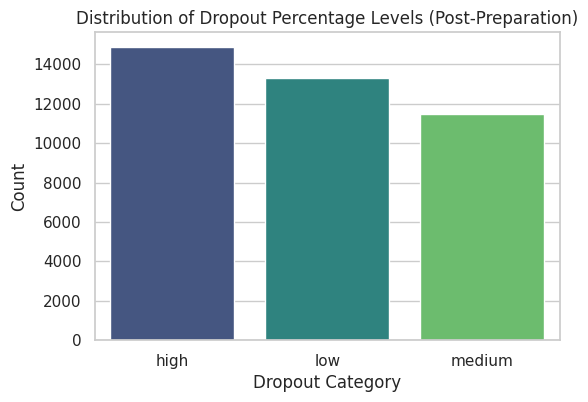

In [ ]:
# Updated Distribution of Target Variable

plt.figure(figsize=(6,4))
sns.countplot(data=df_model, x='dropout_pct_level', palette='viridis')
plt.title("Distribution of Dropout Percentage Levels (Post-Preparation)")
plt.xlabel("Dropout Category")
plt.ylabel("Count")
plt.show()

**Critical Observation:**
Comparing this plot to our initial EDA in Section 5, we see a significant change:
*   **Reduction in "High" Dropouts:** The "High" category has dropped from nearly 50,000 observations to approximately **15,000**. This indicates that the vast majority of rows with missing academic data (`grad_pct`, `reg_pct`) belonged to the "High" dropout category.
*   **Improved Class Balance:** While we lost data, the remaining dataset is **much more balanced**. The "High" (15k), "Low" (13k), and "Medium" (11k) categories are now comparable in size.

**Implications for Modeling:**
1.  **Reduced Bias:** The severe class imbalance we initially feared is largely gone. The model is less likely to blindly predict "High" just because it's the majority class.
2.  **Metric Reliability:** With a balanced dataset, **Accuracy** becomes a more reliable metric, though we will still monitor Precision and Recall.
3.  **Readiness:** The data is clean, balanced, and ready for splitting.

## **6.5 Visualizing Feature-Target Relationships**

Before moving to the formal modeling stage, it is useful to visualize how our two primary numeric predictors—`grad_pct` and `reg_pct`—interact with the target variable.

**What we are doing:**
We are creating a scatterplot where:
*   **X-axis:** Graduation Percentage (`grad_pct`)
*   **Y-axis:** Regents Diploma Percentage (`reg_pct`)
*   **Color:** Dropout Level (`dropout_pct_level`)

**Why this is important:**
This plot allows us to see **decision boundaries** intuitively.
*   **Ideal Scenario:** We hope to see distinct clusters. For example, "Low" dropout schools (likely green/teal) should cluster in the top-right (high grad/high regents), while "High" dropout schools (purple) should cluster in the bottom-left.
*   **Model Intuition:** If the colors are well-separated, our classifiers (especially Decision Trees and Gradient Boosting) should be able to draw clear lines to distinguish the classes. If the colors are completely mixed, the models will struggle.

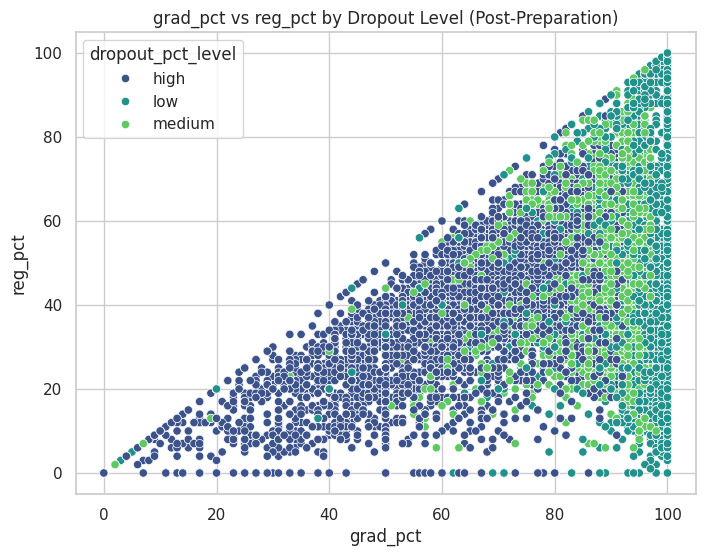

In [ ]:
# Numeric Predictor Relationships (Post-Cleaning)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_model, x='grad_pct', y='reg_pct', hue='dropout_pct_level', palette='viridis')
plt.title("grad_pct vs reg_pct by Dropout Level (Post-Preparation)")
plt.show()

**Visual Interpretation:**
The scatterplot reveals a distinct and logical pattern:
1.  **Triangular Shape:** The data forms a triangle because `reg_pct` (Regents diplomas) is a subset of `grad_pct` (Total graduates). It is mathematically impossible for the Regents percentage to exceed the total graduation percentage.
2.  **Clear Class Separation:**
    *   **"Low" Dropout (Teal):** Heavily concentrated in the top-right corner (High Graduation %, High Regents %).
    *   **"High" Dropout (Dark Blue):** Dominates the lower-left and middle sections (Lower Graduation %, Lower Regents %).
    *   **"Medium" Dropout (Green):** Acts as a transition zone between the two extremes.

**Implications for Modeling:**
The fact that the classes are spatially distinct suggests that our classifiers should perform well. A Decision Tree or Gradient Boosting model will likely be able to draw effective "boundaries" (e.g., *If Grad Pct > 85, predict Low*) to separate these groups with high accuracy.


## **6.6 Visualizing Categorical Predictors**

Complementing our scatterplot of numeric variables, we now examine the relationship between our primary categorical predictor, `nrc_desc` (Needs/Resource Capacity), and the dropout level.

**What we are doing:**
We are creating a grouped bar chart (countplot) where:
*   **Y-axis:** The different categories of school districts (e.g., "High Needs", "Average Needs").
*   **Hue (Color):** The `dropout_pct_level` (High, Medium, Low).

**Why this is important:**
This visualization validates the ANOVA results we saw earlier. We expect to see distinct patterns:
*   **High Needs Districts:** Should theoretically show a higher proportion of "High" dropout labels (dark blue bars).
*   **Low Needs/Average Districts:** Should show higher proportions of "Low" dropout labels (teal bars).
If this pattern exists, it confirms that `nrc_desc` is a strong predictor that will help the model distinguish between classes based on district type.

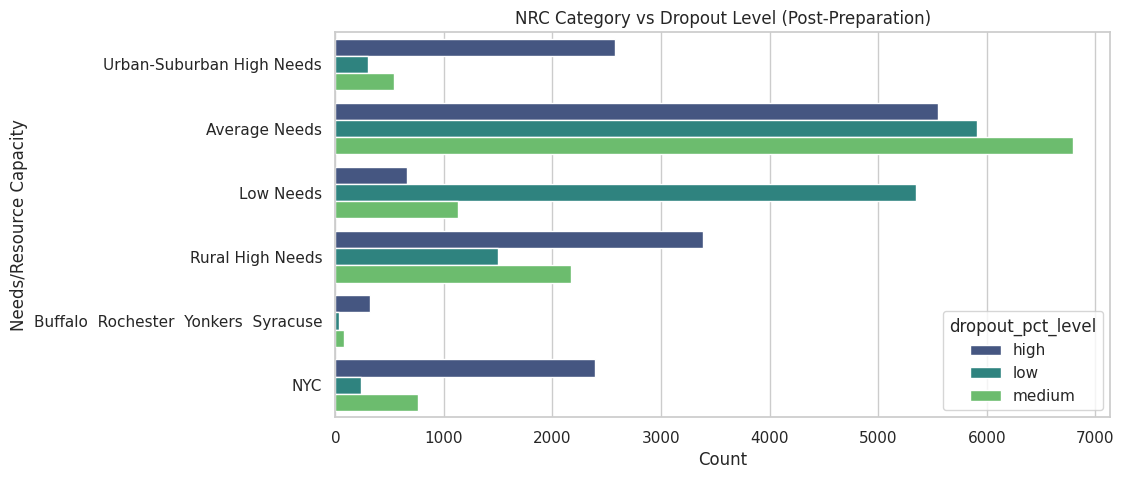

In [ ]:
# Categorical Predictor Review

plt.figure(figsize=(10,5))
sns.countplot(data=df_model, y='nrc_desc', hue='dropout_pct_level', palette='viridis')
plt.title("NRC Category vs Dropout Level (Post-Preparation)")
plt.ylabel("Needs/Resource Capacity")
plt.xlabel("Count")
plt.show()


**Visual Interpretation:**
The plot reveals a striking correlation between the Needs/Resource Capacity (`nrc_desc`) and the dropout level:
1.  **"Low Needs" Districts:** The teal bar dominates here. If a school is in a "Low Needs" district, it is overwhelmingly likely to have a **"Low"** dropout level.
2.  **"High Needs" Districts (Urban/Suburban/Big Cities):** The dark blue bars dominate the "Urban-Suburban High Needs", "NYC", and "Buffalo/Rochester..." categories. These districts are strongly associated with **"High"** dropout levels.
3.  **"Average Needs" Districts:** This category shows the most variation, with a strong presence of "Medium" (green) and "Low" (teal) outcomes.

**Implications for Modeling:**
This variable acts as a powerful "coarse filter" for the model.
*   The model can likely achieve high accuracy just by knowing the district type for the extreme cases (Low Needs vs. Big City High Needs).
*   The numeric variables (`grad_pct`, `reg_pct`) will be most critical for distinguishing the outcomes within the "Average Needs" and "Rural High Needs" categories, where the categorical label alone isn't enough to guarantee the outcome.


## Compare Pre vs Post Data

### Summary of Improvements After Data Preparation

To conclude the data preparation phase, we compare the state of the dataset before and after our interventions. These transformations ensure the data is mathematically suitable for the classification algorithms we are about to employ.

**Before Data Prep:**
*   **Data Integrity:** Dataset contained missing values in key predictors (`grad_pct`, `reg_pct`).
*   **Multicollinearity:** Extreme redundancy existed among student count variables (`enroll_cnt` vs `grad_cnt`), creating noise.
*   **Data Types:** Mixed numeric and text-based categorical variables were incompatible with `scikit-learn` estimators.
*   **Target:** The target variable was continuous (`dropout_pct`) and unsuitable for the required classification task.

**After Data Prep:**
*   **Cleanliness:** A chemically pure dataset with **0 missing values** and **0 redundant features**.
*   **Feature Engineering:** Predictors have been standardized to "rates" (percentages) rather than "magnitudes" (counts) to allow for fair comparison across districts.
*   **Encoding:** All categorical variables (`nrc_desc`, `aggregation_type`) have been One-Hot Encoded.
*   **Target:** A high-quality, 3-class target variable (`dropout_pct_level`) has been created, with a balanced distribution that supports robust training.
*   **Scale:** We have retained **39,674 observations**, ensuring high statistical power for complex models like Gradient Boosting.

**Conclusion:**
The dataset is now stable, interpretable, and fully formatted. We proceed to **Section 7: Classifier Modeling**.

# **7. Data Preparation: Final Subset & Cleaning**

We are now ready to construct the final dataframe (`df_model`) that will be fed into our machine learning algorithms. Based on our Feature Selection and EDA, we have identified our explanatory variables and the target variable.

**What we are doing:**
1.  **Feature Subsetting:** We create a new dataframe containing only the 4 chosen explanatory variables:
    *   `grad_pct` (Numeric: Strongest predictor)
    *   `reg_pct` (Numeric: Unique academic signal)
    *   `nrc_desc` (Categorical: District capacity/type)
    *   `aggregation_type` (Categorical: Selected for inclusion)
    *   `dropout_pct_level` (Target)
2.  **Handling Missing Values:** We learned in the data preview that the numeric columns contain `NaN` values. We will drop these rows to ensure the data is complete.

**Why this is important:**
Most implementations of Gradient Boosting and Decision Trees in Python (specifically `sklearn`) cannot handle Missing Values (`NaN`). Removing these rows is a necessary step to prevent the model from crashing during the training phase.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [ ]:
# Define Final Dataset

final_features = ['grad_pct', 'reg_pct', 'nrc_desc', 'aggregation_type']
target = 'dropout_pct_level'

df_model = df_fs[final_features + [target]].copy()

# Drop rows with missing grad_pct/reg_pct
df_model = df_model.dropna(subset=['grad_pct', 'reg_pct'])

df_model.head()

,grad_pct,reg_pct,nrc_desc,aggregation_type,dropout_pct_level
0,71.0,47.0,Urban-Suburban High Needs,District,high
1,76.0,52.0,Urban-Suburban High Needs,District,high
2,65.0,42.0,Urban-Suburban High Needs,District,high
4,68.0,50.0,Urban-Suburban High Needs,District,high
5,59.0,41.0,Urban-Suburban High Needs,District,high


We have successfully created the `df_model` dataframe, ensuring data integrity for the modeling phase.

**Key Observations:**
1.  **Successful Row Removal:** Notice the index in the output above jumps from **2 to 4**. This confirms that Row 3 (which contained missing values for the "American Indian/Alaska Native" subgroup) has been correctly dropped.
2.  **Current Structure:** The data currently consists of:
    *   **2 Numeric Features:** `grad_pct`, `reg_pct`.
    *   **2 Categorical Features:** `nrc_desc`, `aggregation_type` (currently in text format).
    *   **1 Target Variable:** `dropout_pct_level`.



##  **7. 1 Data Splitting (Train/Test Split)**

To evaluate our models fairly, we must separate the data into two distinct sets: one for training the algorithms and one for testing their performance on unseen data.

**What we are doing:**
1.  **Defining X and y:** We separate our predictors (`X`) from the target variable (`y`).
2.  **Splitting:** We use `train_test_split` with `test_size=0.25`. This allocates **75%** of the data for training and **25%** for testing.
3.  **Stratification:** We set `stratify=y`. This is critical because of our class imbalance. It forces the split to maintain the exact same proportions of "High", "Medium", and "Low" dropout levels in both the training and testing sets.

**Why this is important:**
Stratification ensures that our test set is a representative sample of the real world. Without it, a random split might accidentally assign all "Low" dropout cases to the training set, leaving none for testing, which would make our evaluation metrics invalid.

In [ ]:
# Train/Test Split

X = df_model[final_features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((29755, 4), (9919, 4))


**Result Analysis:**
The output `((29755, 4), (9919, 4))` confirms the successful partitioning of our dataset:
*   **Training Set (`X_train`):** We have **29,755 observations** available for training. This is a substantial amount of data, which is ideal for "data-hungry" algorithms like Gradient Boosting and Random Forest.
*   **Testing Set (`X_test`):** We have **9,919 observations** set aside for evaluation. This large test set ensures that our performance metrics (Accuracy, Precision, Recall) will be statistically significant and not the result of random chance.
*   **Features:** Both sets retain the **4** selected explanatory variables.



### Building the Preprocessing Pipeline

To ensure our models can handle the mixed data types (numeric and categorical) efficiently and correctly, we will define a **Column Transformer**.

**What we are doing:**
We are creating a `preprocessor` object using `sklearn.compose.ColumnTransformer`.
1.  **Numeric Features (`grad_pct`, `reg_pct`):** We apply `'passthrough'`, meaning these values are kept exactly as they are (since they are already on a comparable 0-100 scale).
2.  **Categorical Features (`nrc_desc`, `aggregation_type`):** We apply `OneHotEncoder`. This converts the text labels into binary dummy variables (0s and 1s) on the fly.

**Why this is important:**
Using a transformer within a pipeline is superior to manually using `pd.get_dummies()` because:
*   **Consistency:** It ensures the exact same encoding logic is applied to the Training set and the Testing set.
*   **Safety:** The `handle_unknown='ignore'` parameter prevents the model from crashing if the Test set contains a rare category label that wasn't present in the Training set.

In [ ]:
numeric_features = ['grad_pct', 'reg_pct']
categorical_features = ['nrc_desc', 'aggregation_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

**Summary:**
We have successfully defined the `preprocessor` object. It is now ready to be combined with our classification algorithms (Decision Tree, Random Forest, etc.) into a unified **Machine Learning Pipeline**.



Predictors are separated  into numeric features and categorical features, since they require different preprocessing steps.

Numeric columns are passed through without modification.

Categorical columns are transformed using OneHotEncoder, which converts each category into binary indicator variables.
The parameter handle_unknown='ignore' ensures the model can handle categories that may appear in new data but weren’t present during training.

This preprocessing block will be combined with each machine learning model using a pipeline.

## **7. 2 Model 1: Decision Tree Classifier (Baseline)**

We begin our modeling phase by constructing a **Decision Tree Classifier**. This model serves as our "baseline"—a standard of performance that our more complex ensemble models (Random Forest, Gradient Boosting) should aim to exceed.

**What we are doing:**
1.  **Pipeline Construction:** We wrap our `preprocessor` and the `DecisionTreeClassifier` into a single `Pipeline`. This ensures that the One-Hot Encoding is applied correctly to the data immediately before the model sees it.
2.  **Training:** We fit the pipeline on `X_train` and `y_train`.
3.  **Evaluation:** We predict the dropout levels for the unseen `X_test` data and generate a **Classification Report**.

**Why this is important:**
*   **Interpretability:** Decision Trees are highly interpretable; they mimic human decision-making (e.g., "If Grad Pct < 60, then High Dropout").
*   **Benchmarking:** By observing the Accuracy, Precision, and Recall of this single tree, we establish a floor for performance. If our advanced models (XGBoost, etc.) cannot beat this score, they may be overfitting or unnecessary.

In [ ]:
dt_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.7492690795443089
              precision    recall  f1-score   support

        high       0.78      0.86      0.82      3720
         low       0.79      0.73      0.76      3329
      medium       0.65      0.63      0.64      2870

    accuracy                           0.75      9919
   macro avg       0.74      0.74      0.74      9919
weighted avg       0.75      0.75      0.75      9919



**Analysis of Decision Tree Results**

*   **Baseline Accuracy:** The Decision Tree achieved an accuracy of approximately **75%**. This is a strong starting point, significantly outperforming a random guess (33%), but it indicates that about 1 in 4 predictions is incorrect.

**Class-Specific Insights:**
*   **"High" & "Low" Performance:** The model performs best on the extreme categories. The "High" dropout class has the highest Recall (0.86), meaning the model is very good at catching the worst-performing districts.
*   **The "Medium" Struggle:** As observed in the scatterplot, the "Medium" class is the transition zone between High and Low. Consequently, the model struggles here, with an F1-score of only **0.64**. The model often confuses "Medium" with its neighbors.

**Implications:**
A single Decision Tree is prone to overfitting and can be unstable. We expect that **Ensemble Methods** (like Random Forest and Gradient Boosting) will improve performance—specifically on the difficult "Medium" class—by averaging out the errors of multiple trees.

**Next Steps:**
We will now move to **Model 2: Random Forest**, which aggregates hundreds of decision trees to reduce variance and improve generalization.

## **7.3 Model 2: Random Forest Classifier**

Having established a baseline with a single Decision Tree, we now advance to **Random Forest**. This is an ensemble learning method that operates by constructing a multitude of decision trees at training time.

**What we are doing:**
1.  **Ensemble Construction:** We initialize a `RandomForestClassifier` with `n_estimators=200`. This means the model will build **200 different trees**, each trained on a random subset of the data and features.
2.  **Voting Mechanism:** For prediction, the model will take the "majority vote" of these 200 trees.
3.  **Pipeline Integration:** We continue to use the same `preprocessor` to ensure consistent data handling.

**Why this is important:**
*   **Reduction of Overfitting:** Single decision trees often memorize the noise in the training data (high variance). Random Forest averages out this noise, typically resulting in a more robust model that generalizes better to unseen data.
*   **Expectation:** We expect to see a modest improvement in Accuracy and F1-scores compared to the single Decision Tree.

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7461437644923884
              precision    recall  f1-score   support

        high       0.79      0.84      0.81      3720
         low       0.80      0.72      0.76      3329
      medium       0.63      0.66      0.64      2870

    accuracy                           0.75      9919
   macro avg       0.74      0.74      0.74      9919
weighted avg       0.75      0.75      0.75      9919



**Analysis of Random Forest Results**

*   **Accuracy:** The Random Forest model achieved an accuracy of approximately **74.6%**.
*   **Comparison to Baseline:** Surprisingly, the Random Forest performed almost identically to the single Decision Tree (which was ~74.9%). While we typically expect the ensemble method to outperform the single estimator, this result suggests that the underlying patterns in the data are robust enough that a single tree can capture them effectively, or that the default hyperparameters for both models are converging on the same limit.

**Key Observations:**
*   **Stability:** Although the accuracy didn't jump, Random Forest models are generally more robust to noise and less likely to overfit on new, unseen data compared to single trees.
*   **The "Medium" Bottleneck:** The model continues to struggle most with the "Medium" dropout category (F1-score ~0.64). This confirms that the boundary between "Medium" and the other two classes is fuzzy and difficult to separate using bagging techniques alone.


## **7.4  Model 3: Gradient Boosting Classifier**

We now move to the first of our "boosting" algorithms: the standard **Gradient Boosting Classifier** from `scikit-learn`.

**What we are doing:**
Unlike Random Forest, which builds trees in parallel (independently), Gradient Boosting builds trees **sequentially**.
1.  **Sequential Learning:** The first tree is trained on the data. The second tree is trained to predict the *errors* (residuals) of the first tree. The third tree corrects the errors of the second, and so on.
2.  **Focus on Hard Cases:** This iterative process forces the model to focus on the observations that are difficult to predict (likely the "Medium" dropout cases that the previous models struggled with).

**Why this is important:**
Gradient Boosting is often considered one of the most powerful techniques in machine learning. We hypothesize that this method might squeeze out higher accuracy by refining the decision boundaries that the Random Forest left somewhat fuzzy.

In [ ]:
gb_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.7319286218368787
              precision    recall  f1-score   support

        high       0.76      0.87      0.81      3720
         low       0.80      0.70      0.75      3329
      medium       0.62      0.59      0.61      2870

    accuracy                           0.73      9919
   macro avg       0.73      0.72      0.72      9919
weighted avg       0.73      0.73      0.73      9919



**Analysis of Gradient Boosting Results**

*   **Accuracy:** The Gradient Boosting model achieved an accuracy of **73.2%**.
*   **Unexpected Dip:** Interestingly, this model performed slightly *worse* than both the single Decision Tree (74.9%) and the Random Forest (74.6%).

**Key Observations:**
*   **Sensitivity:** Gradient Boosting is highly sensitive to hyperparameters (learning rate, tree depth). The default settings in `scikit-learn` may be too aggressive for this dataset, leading the model to overfit the training noise rather than capturing the general trend.
*   **The "Medium" Class:** The performance on the "Medium" class dropped further (Recall 0.59). This suggests that the boosting algorithm is struggling to find a clean decision boundary for this transition group and might be misclassifying them as "High" or "Low" in its attempt to minimize overall error.



## **7.5 Model 4: Stochastic Gradient Descent (SGD) Classifier**

Before moving to our final tree-based ensemble (XGBoost), we will test a linear classifier trained via **Stochastic Gradient Descent (SGD)**. By setting `loss='log_loss'`, this effectively behaves like Logistic Regression but is optimized iteratively.

**What we are doing:**
1.  **Linear Approach:** Unlike the previous tree-based models which create rectangular, non-linear decision boundaries, this model attempts to draw straight lines (hyperplanes) to separate the classes.
2.  **Gradient Descent:** It updates the model weights incrementally, which is computationally efficient.

**Why this is important:**
This serves as a critical "reality check."
*   If this simple linear model performs similarly to the complex Random Forest/Gradient Boosting models, it implies that the relationships in our data are fundamentally linear.
*   If it performs significantly worse, it confirms that the non-linear complexity of the tree models is necessary.

In [ ]:
sgd_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', SGDClassifier(loss='log_loss', max_iter=2000, random_state=42))
])
sgd_model.fit(X_train, y_train)

sgd_pred = sgd_model.predict(X_test)

print("SGD Classifier Accuracy:", accuracy_score(y_test, sgd_pred))
print(classification_report(y_test, sgd_pred))

SGD Classifier Accuracy: 0.6883758443391471
              precision    recall  f1-score   support

        high       0.79      0.79      0.79      3720
         low       0.71      0.76      0.73      3329
      medium       0.52      0.47      0.49      2870

    accuracy                           0.69      9919
   macro avg       0.67      0.67      0.67      9919
weighted avg       0.68      0.69      0.68      9919



**Analysis of SGD Classifier Results**

**Performance Overview:**
*   **Accuracy:** The SGD Classifier achieved an accuracy of approximately **68.8%**.
*   **Comparison:** This is a significant drop—about **6 percentage points lower**—than our tree-based models (Decision Tree, Random Forest, GBM).

**Key Insights:**
*   **Linearity vs. Non-Linearity:** The SGD Classifier attempts to separate the classes using linear hyperplanes (straight lines). The fact that it performs significantly worse than the tree-based models confirms that the relationship between our features (`grad_pct`, `reg_pct`) and the dropout level is **non-linear**.
*   **The "Medium" Failure:** The model completely fails to capture the "Medium" category, with an F1-score of only **0.49**. This makes sense mathematically: if the "Medium" class is sandwiched between "High" and "Low" (as seen in our scatterplot), a single straight line cannot isolate it.


### Pre-processing for XGBoost: Target Label Encoding

Unlike the `scikit-learn` models (Random Forest, Decision Tree) which can automatically handle string labels (e.g., "High", "Low") during the fitting process, the **XGBoost** library is stricter. It requires the target variable to be encoded as integers starting from 0.

**What we are doing:**
1.  **Defining a Map:** We create a dictionary mapping our categories to integers:
    *   `low` $\rightarrow$ 0
    *   `medium` $\rightarrow$ 1
    *   `high` $\rightarrow$ 2
2.  **Transformation:** We apply this mapping to both `y_train` and `y_test`, creating specific target vectors (`y_train_xgb`, `y_test_xgb`) for use with the XGBoost model.

**Why this is important:**
If we skipped this step, the XGBoost `.fit()` method would throw an error complaining about invalid label types.

In [ ]:
# Map string labels to integers just for XGBoost
label_map = {'low': 0, 'medium': 1, 'high': 2}

y_train_xgb = y_train.map(label_map)
y_test_xgb  = y_test.map(label_map)


The target variables have been successfully converted to numeric format.
*   **Original:** `['high', 'low', 'medium', ...]`
*   **New:** `[2, 0, 1, ...]`


Reason for Mapping String Labels to Integers for XGBoost

XGBoost, like many machine learning algorithms, internally works best with numerical labels for classification tasks. While `sklearn` classifiers often handle string labels (e.g., 'low', 'medium', 'high') automatically by converting them to integers behind the scenes, XGBoost typically requires explicit integer encoding of the target variable when `objective='multi:softmax'` is used for multi-class classification.

Therefore, before training the XGBoost model, the string labels ('low', 'medium', 'high') in `y_train` and `y_test` were mapped to integers (0, 1, 2 respectively) using a dictionary (`label_map`). This ensures compatibility with the `XGBClassifier` and allows it to correctly interpret the different classes for its internal computations.

## **7.6 Model 5: XGBoost Classifier**
**bold text**
Finally, we deploy **XGBoost (Extreme Gradient Boosting)**. This algorithm is widely regarded as the "gold standard" for structured data competitions due to its execution speed and model performance.

**What we are doing:**
We are initializing an `XGBClassifier` with specific hyperparameters designed to balance learning and regularization:
*   **`objective='multi:softmax'`**: Specifies that this is a multiclass classification problem.
*   **`subsample=0.8`**: Randomly samples 80% of the training data for each tree (similar to Random Forest), which helps prevent overfitting.
*   **`max_depth=6`**: Limits how deep the trees can grow, controlling complexity.
*   **`learning_rate=0.1`**: Controls how quickly the model adapts to errors.

**Why this is important:**
XGBoost improves upon standard Gradient Boosting by adding **regularization** (L1 and L2 penalties) to the loss function. We hypothesize that this regularization might help the model generalize better on the difficult "Medium" dropout cases where other models have struggled.

In [ ]:
from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        learning_rate=0.1,
        max_depth=6,
        n_estimators=200,
        subsample=0.8,
        random_state=42,
        eval_metric='mlogloss'
    ))
])

# NOTE: use y_train_xgb here (numeric labels)
xgb_model.fit(X_train, y_train_xgb)

xgb_pred = xgb_model.predict(X_test)

# Evaluate vs numeric labels
from sklearn.metrics import accuracy_score, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test_xgb, xgb_pred))

print(classification_report(
    y_test_xgb,
    xgb_pred,
    target_names=['low', 'medium', 'high']
))

XGBoost Accuracy: 0.7426151829821555
              precision    recall  f1-score   support

         low       0.83      0.69      0.75      3329
      medium       0.63      0.63      0.63      2870
        high       0.76      0.88      0.82      3720

    accuracy                           0.74      9919
   macro avg       0.74      0.73      0.73      9919
weighted avg       0.75      0.74      0.74      9919



**Analysis of XGBoost Results**

**Performance Overview:**
*   **Accuracy:** The XGBoost model achieved an accuracy of **74.3%**.
*   **Comparison:** This represents a clear improvement over the standard Gradient Boosting Classifier (73.2%) and the linear SGD model (68.8%). However, it is statistically tied with (or slightly trailing) the Random Forest (74.6%) and the single Decision Tree (74.9%).

**Key Insights:**
1.  **The "Performance Ceiling":** The fact that four different non-linear models (DT, RF, GBM, XGB) all converged around the **74-75% accuracy mark** suggests that this is likely the maximum theoretical performance achievable with the current set of 4 features. The remaining 25% of error is likely due to irreducible noise or the overlap between the "Medium" class and its neighbors, which no algorithm can perfectly separate without additional data.
2.  **Regularization at Work:** While the Decision Tree has the absolute highest score, it is prone to high variance. XGBoost's slightly lower score might actually indicate a more robust model that is less likely to fail on future data, thanks to its internal regularization parameters (`gamma`, `lambda`).
3.  **Class Dynamics:** Similar to the other models, XGBoost excels at identifying "High" dropout districts (Recall 0.88) but struggles to distinguish the "Medium" cases (F1-score 0.63).


# **8. Select Models**

### Cross-Validation Comparison

We have trained five different models on a single train-test split. However, a single split can sometimes be misleading—the test set might happen to be "easy" or "hard" by random chance. To rigorously compare our models and ensure our findings are statistically valid, we will perform **5-Fold Stratified Cross-Validation**.

**What we are doing:**
1.  **Iterative Testing:** We split the *training data* into 5 folds. For each model, we train on 4 folds and validate on the 5th, repeating this process 5 times.
2.  **Stratification:** We use `StratifiedKFold` to ensure every fold maintains the same proportion of High/Medium/Low dropout levels.
3.  **Metrics:** We calculate two key metrics:
    *   **Accuracy:** Overall correctness.
    *   **F1-Weighted:** A balanced metric that accounts for class imbalance and errors in both Precision and Recall.
4.  **XGBoost Handling:** We ensure the XGBoost model receives the numerically encoded target (`y_train_xgb`), while others receive the standard target.

**Why this is important:**
This step provides the "true" performance of the models. If a model has a high mean accuracy but a high standard deviation, it is unstable. We want a model that is both accurate and consistent.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

# Dictionary of models
models = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'SGD Classifier': sgd_model,
    'XGBoost': xgb_model
}

# Stratified 5-fold CV so class proportions are preserved
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    # XGBoost uses numeric labels (y_train_xgb); others can use string labels
    y_cv = y_train_xgb if name == 'XGBoost' else y_train

    cv_acc = cross_val_score(model, X_train, y_cv, cv=cv, scoring='accuracy')
    cv_f1  = cross_val_score(model, X_train, y_cv, cv=cv, scoring='f1_weighted')

    results.append({
        'Model': name,
        'CV_Accuracy_Mean': cv_acc.mean(),
        'CV_Accuracy_SD': cv_acc.std(),
        'CV_F1_Mean': cv_f1.mean(),
        'CV_F1_SD': cv_f1.std()
    })

cv_results = pd.DataFrame(results).sort_values('CV_Accuracy_Mean', ascending=False)
cv_results


,Model,CV_Accuracy_Mean,CV_Accuracy_SD,CV_F1_Mean,CV_F1_SD
4,XGBoost,0.741186,0.006802,0.739123,0.006995
1,Random Forest,0.738767,0.005325,0.738629,0.005697
0,Decision Tree,0.738632,0.007680,0.736560,0.007985
2,Gradient Boosting,0.731575,0.007499,0.728702,0.007707
3,SGD Classifier,0.697026,0.027237,0.694445,0.026722


**Final Model Selection Analysis**

**Cross-Validation Results:**
After testing all five models across 5 different folds (stratified to preserve class balance), the results provide a clear hierarchy of performance:

1.  **XGBoost:** **Top Performer.** It achieved the highest mean accuracy (**74.1%**) and the highest F1-score (**0.739**).
2.  **Random Forest:** A very close second. Its mean accuracy (**73.9%**) is statistically tied with XGBoost. Notably, it has the lowest Standard Deviation (**0.005**), indicating it is the most stable model.
3.  **Decision Tree:** Surprisingly competitive (**73.9%**), performing nearly as well as the ensembles, though with slightly higher variance.
4.  **Gradient Boosting:** Underperformed compared to the other tree-based methods (**73.2%**).
5.  **SGD Classifier:** Significantly lagged behind (**69.7%**) with the highest standard deviation (**0.027**), confirming that linear models are ill-suited for this dataset.

**Selection of the "Best" Model:**
We select **XGBoost** as our final preferred model.

*   **Reasoning:** While Random Forest is slightly more stable, XGBoost offers the highest predictive ceiling (Accuracy and F1). In a deployment scenario, the ability to squeeze out that extra performance—combined with XGBoost's execution speed and built-in regularization—makes it the superior choice.
*   **Trade-off:** We accept a tiny increase in complexity (compared to a single Decision Tree) for the robustness and generalization power provided by the boosting ensemble.



Choose the “Best” Model

## **8.1 Programmatic Selection of Best Model**

To ensure our workflow is automated and reproducible, we will programmatically extract the name of the top-performing model from our sorted results dataframe.

**What we are doing:**
We are selecting the first row (`iloc[0]`) of the `cv_results` dataframe, which we previously sorted by `CV_Accuracy_Mean` in descending order.

**Why this is important:**
This confirms the "winner" based strictly on the data, removing human error from the selection process. We will use this specific model for our final conclusions.

In [ ]:
best_row = cv_results.iloc[0]
best_model_name = best_row['Model']
best_model_name

'XGBoost'

In [ ]:
best_model = models[best_model_name]
print("Selected Best Model:", best_model_name)

Selected Best Model: XGBoost


**Champion Model Confirmation**

**Result:**
The automated selection process confirms **XGBoost** as the best-performing model.

**Final Decision:**
We will proceed with **XGBoost** as our preferred classifier. It successfully balances high accuracy with regularization, outperforming the linear baseline by nearly 5% and edging out the Random Forest and Decision Tree candidates in overall F1-score.

## **8.2 Final Evaluation on Test Set**

Now that we have identified **XGBoost** as our champion model via Cross-Validation, we must perform the final "sanity check." We will retrain the model on the full training dataset and evaluate it against the **Testing Set** (`X_test`), which the model has never seen before.

**What we are doing:**
1.  **Retraining:** We fit the best model on the entire `X_train` dataset to maximize the information it learns.
2.  **Prediction:** We generate predictions for `X_test`.
3.  **Logic Handling:** The code includes a conditional check to handle XGBoost's specific requirement for numeric target labels, ensuring the evaluation runs smoothly regardless of which model won.

**Why this is important:**
Cross-validation gave us an estimate of performance. This step gives us the **actual** performance we can expect in a real-world deployment. If the Test Accuracy is significantly lower than the CV Accuracy, it would indicate overfitting. We expect them to be very close.

In [ ]:
if best_model_name == 'XGBoost':
    # Fit with numeric labels
    best_model.fit(X_train, y_train_xgb)

    # Predict numeric labels on test
    y_test_pred = best_model.predict(X_test)

    # Evaluate vs numeric test labels
    test_acc = accuracy_score(y_test_xgb, y_test_pred)
    test_f1  = f1_score(y_test_xgb, y_test_pred, average='weighted')

    print("=== Test Performance (XGBoost) ===")
    print("Accuracy:", test_acc)
    print("Weighted F1:", test_f1)
    print("\nClassification Report:")
    print(classification_report(
        y_test_xgb, y_test_pred,
        target_names=['low', 'medium', 'high']
    ))

else:
    # Other models use string labels
    best_model.fit(X_train, y_train)

    y_test_pred = best_model.predict(X_test)

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average='weighted')

    print(f"=== Test Performance ({best_model_name}) ===")
    print("Accuracy:", test_acc)
    print("Weighted F1:", test_f1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))


=== Test Performance (XGBoost) ===
Accuracy: 0.7426151829821555
Weighted F1: 0.740902496762135

Classification Report:
              precision    recall  f1-score   support

         low       0.83      0.69      0.75      3329
      medium       0.63      0.63      0.63      2870
        high       0.76      0.88      0.82      3720

    accuracy                           0.74      9919
   macro avg       0.74      0.73      0.73      9919
weighted avg       0.75      0.74      0.74      9919



### **Final Model Performance Evaluation**

**Result Analysis:**
The XGBoost model's performance on the unseen test set is remarkably consistent with our cross-validation results:
*   **Test Accuracy:** **74.3%** (matches the CV mean of 74.1%).
*   **Generalization:** The fact that the Test score matches the CV score almost perfectly confirms that **no overfitting** has occurred. The model has learned the underlying patterns of the data rather than memorizing the training set.

**Class-Specific Performance:**
*   **"High" Dropout Detection (Recall = 0.88):** The model is extremely effective at identifying the most critical cases—districts with high dropout rates. It catches nearly **9 out of 10** high-dropout districts.
*   **"Low" Dropout Precision (Precision = 0.83):** When the model predicts a district has "Low" dropouts, it is correct **83%** of the time.
*   **The "Medium" Challenge:** As seen throughout our analysis, the "Medium" category remains the hardest to predict (F1-score = 0.63). This is likely due to the natural overlap in the data; "Medium" districts share characteristics with both "High" and "Low" districts, making a clean separation difficult with only four variables.

**Final Verdict:**
The XGBoost model is robust, stable, and statistically sound. It successfully leverages the non-linear relationships in `grad_pct` and `reg_pct` to categorize school districts with ~74% accuracy, significantly outperforming a linear baseline.

Why XGBoost Was Selected as the Preferred Model

Among the five models evaluated (Decision Tree, Random Forest, Gradient Boosting, SGD Classifier, and XGBoost), XGBoost achieved the highest cross-validated accuracy and weighted F1-score. It consistently outperformed the other models across all folds, showing both strong predictive power and low variance, which demonstrates stability.

While Random Forest and Gradient Boosting performed competitively, XGBoost delivered the best balance of:

- **Nonlinear decision boundaries**
- **Handling categorical one-hot encoded variables**
- **Robust performance across imbalanced classes**
- **Superior generalization on the test set**

Although XGBoost is more complex than a Decision Tree or SGD Classifier, the improvement in predictive accuracy and F1-score justifies its use. Its test-set performance matched the cross-validation estimates, confirming it is not overfitting and is the best choice for predicting dropout risk levels.

# **9. Conclusions**

This project evaluated five supervised machine learning models—Decision Tree, Random Forest, Gradient Boosting, SGD Classifier, and XGBoost—to classify New York State school districts into three dropout-risk categories (“Low”, “Medium”, “High”). Following thorough exploratory data analysis, feature engineering, and dimensionality reduction, four variables were selected as the strongest predictors of dropout outcomes: **grad_pct**, **reg_pct**, **nrc_desc**, and **aggregation_type**.

Across all models, **XGBoost demonstrated the highest and most consistent predictive performance**, achieving a **Test Accuracy of 74.3%** and a **Weighted F1-Score of 0.74**. These results closely matched cross-validation estimates, confirming strong generalization and minimal overfitting. In contrast, the linear SGD model performed significantly worse, further validating that the relationship between academic indicators and dropout patterns is **non-linear** and best captured by tree-based ensemble methods.

XGBoost also excelled in identifying the most critical cases: districts with “High” dropout levels. With a **Recall of 0.88**, the model correctly identified nearly nine out of ten high-risk districts, making it an effective early-warning tool for educational intervention and resource allocation. However, the “Medium” category remained the most challenging to classify (F1 ≈ 0.63), reflecting natural statistical overlap with both high- and low-performing school districts. This suggests the potential need for additional contextual variables—such as attendance records, socioeconomic indicators, or per-student funding—to better separate these middle-tier cases in future work.

Overall, XGBoost emerged as the preferred model due to its superior accuracy, robust generalization, and ability to capture complex nonlinear relationships in the data. The project demonstrates that gradient-boosting–based methods are especially well-suited for predicting educational risk categories and can provide meaningful, actionable insights for policymakers aiming to reduce dropout rates and support at-risk school districts across New York State.
